## Introducción
---


Métricas RAGAS aplicables al baseline (sin contexto)



El dataset single-turn tiene columnas user_input, reference, reference_contexts. Para el baseline sin RAG (sin retrieved_contexts), las métricas aplicables son exactamente las que dependen de user_input + reference + response, (es decir, pregunta, respuesta golden truth y respuesta actual del modelo, también aplicable )sin necesitar contexto recuperado:
​

FactualCorrectness: Compara la respuesta generada con la reference anotada por expertos. La más crítica para detectar alucinaciones en el baseline.

AnswerRelevancy: Mide si la respuesta es pertinente a la pregunta, usando similitud de embedding. No requiere contexto.

SemanticSimilarity (embedding-based): Distancia coseno entre la respuesta y la referencia. Métrica no-LLM, rápida y reproducible.

BleuScore / RougeScore: Métricas léxicas clásicas, útiles como complemento para la memoria del TFG al comparar con literatura.

Las métricas RAG puras (Faithfulness, ContextPrecision, ContextRecall) se reservan para las fases posteriores con RAG, lo que además te da una comparativa muy limpia en la memoria: baseline solo con métricas de generación, y sistema RAG con el set completo.
​

Para la evaluación tanto del baseline como del RAG, lo ideal es aplicar el uso de **RAGAS como framework de métricas + Opik como plataforma de experimentación y trazabilidad.**

Esta combinación es la más sólida para el TFG por tres razones: (1) RAGAS es el estándar de facto en investigación académica sobre alucinaciones en RAG; (2) tu dataset ya tiene exactamente la estructura que RAGAS espera (user_input, reference, reference_contexts); y (3) Opik se integra con RAGAS de forma nativa, te da tracking de experimentos por configuración de parámetros y es significativamente más rápido que Langfuse (23 s vs 300 s para la misma carga de trabajo). Langfuse brilla más en producción con monitoreo continuo, no en benchmarking académico puntual.

## Modelos a comparar en el baseline
---

La comparación que se va a llevar a cabo en ese baseline es entre dos modelos mas o menos de la misma capacidad, como son GPT-4o vs Gemini 2.5 flash (con thinking mode desactivado)

GPT-4o vs Gemini 2.5 Flash con thinking_budget=0 
Como modelo Juez en RAGAS, se usará GPT-5-mini



Selección de los Modelos de Lenguaje para el Baseline
--
La evaluación baseline tiene como objetivo medir el comportamiento de distintos LLMs ante preguntas sobre el dominio específico de AMC Global sin acceso a ningún contexto externo, cuantificando así el nivel de alucinación intrínseco de cada modelo antes de aplicar cualquier técnica de mitigación que vaya más allá del ajuste de los hiperparámetros intrínsecos de los modelos que sí podemos variar vía API. La selección de los modelos respondió a un conjunto de criterios metodológicos estrictos que se detallan a continuación.

Criterios de selección y descarte
--
**Equivalencia de capacidad.** Con el fin de que cualquier diferencia observada en las tasas de alucinación fuese atribuible al comportamiento intrínseco de cada modelo y no a una disparidad de capacidades base, se exigió que los modelos seleccionados perteneciesen al mismo nivel de prestaciones. Se utilizaron como referencia los benchmarks estándar de la comunidad —MMLU (Massive Multitask Language Understanding) y GPQA (Graduate-Level Google-Proof Q&A)— descartando pares con diferencias medias superiores a 10 puntos porcentuales en modo de generación equivalente.

```
**Compatibilidad con el estudio paramétrico.** Uno de los objetivos del trabajo es analizar el efecto de los parámetros de generación —temperatura, top-p y top-k— sobre la tasa de alucinación. Se descartaron explícitamente los modelos que no exponen dichos parámetros en sus APIs, concretamente la familia o-series de OpenAI y Gemini Pro en modo de razonamiento extendido, cuya incompatibilidad haría inviable el estudio paramétrico requerido.

**Independencia respecto al golden dataset.** El corpus de preguntas y respuestas de referencia empleado en este trabajo fue generado íntegramente con asistencia del modelo GPT-4.1 de OpenAI. La inclusión de GPT-4.1 o de cualquier modelo de su misma familia como sujeto de evaluación habría introducido un sesgo conocido en la literatura como self-referential evaluation bias (Panickssery et al., 2024 <poner aqui el otro paper que yo conozco>): los LLMs tienden a puntuar más alto las respuestas generadas por su propio modelo o por modelos de la misma familia, dado que estos textos presentan una menor perplejidad interna y un estilo generativo afín. Al haber sido GPT-4.1 el responsable tanto de la formulación de preguntas como de las respuestas de referencia del dataset, su uso como modelo evaluado o como juez habría comprometido directamente la validez de los resultados. En consecuencia, se descartó toda la familia GPT-4.1 tanto como modelo bajo estudio como en el rol de evaluador.

Modelos seleccionados
--
Aplicados los criterios anteriores, los modelos seleccionados para el estudio baseline fueron GPT-4o (OpenAI, mayo de 2024) y Gemini 2.5 Flash (Google DeepMind, 2025).

GPT-4o es el modelo flagship generativo de referencia de OpenAI, con una ventana de contexto de 128.000 tokens y una puntuación del 88,7% en MMLU. Expone de forma nativa los parámetros temperature y top_p a través de su API y no incorpora ningún mecanismo de razonamiento extendido, operando en todo momento en modo puramente generativo.

Gemini 2.5 Flash es el modelo eficiente de última generación de Google DeepMind, con una ventana de contexto de un millón de tokens y una puntuación de 88,4% en MMLU (Global MMLU Lite) en su configuración estándar (Google DeepMind, 2025). Este modelo incorpora un mecanismo de razonamiento extendido (*thinking mode*) que, cuando está activado, eleva significativamente su rendimiento en tareas de razonamiento complejo: en GPQA Diamond, la versión de disponibilidad general (*GA*) con *thinking* activo alcanza el 82,8% (pass@1), frente al 53,6% de GPT-4o en el mismo benchmark (OpenAI, 2024). Sin embargo, la activación de este mecanismo introduce una asimetría arquitectónica fundamental respecto a GPT-4o, que opera siempre en modo puramente generativo, lo que invalida cualquier comparación directa entre ambos modelos en esas condiciones.

Cabe señalar que Google DeepMind no publica resultados en GPQA Diamond para Gemini 2.5 Flash con razonamiento desactivado. No obstante, la convergencia de ambos modelos en MMLU —88,4% frente a 88,7% respectivamente— proporciona evidencia suficiente de que, en ausencia de razonamiento extendido, sus capacidades base son equiparables en tareas de comprensión y conocimiento general.

Por lo tanto, para garantizar la comparabilidad entre ambos modelos, se configuró Gemini 2.5 Flash con `thinking_budget=0`, desactivando explícitamente el modo de razonamiento extendido y estableciendo condiciones de generación simétricas. Con esta configuración, ambos modelos operan como sistemas puramente generativos, exponen los parámetros `temperature` y `top_p` a través de sus respectivas APIs, y presentan capacidades comparables en tareas de pregunta-respuesta sobre dominio específico, lo que satisface el criterio de equivalencia de capacidad definido en el diseño experimental.


Referencias

Es, S., James, J., Espinosa-Anke, L., & Schockaert, S. (2023). Ragas: Automated evaluation of retrieval augmented generation. arXiv preprint arXiv:2309.15217.

Panickssery, A., Bowman, S. R., & Feng, S. (2024). LLM evaluators recognize and favor their own generations. arXiv preprint arXiv:2404.13076.

Zeng, Z., Yu, J., Gao, T., Meng, Y., Solomatine, T., Jiang, D., & Bansal, M. (2024). Evaluating large language models at evaluating instruction following. arXiv preprint arXiv:2310.07641.

Zheng, L., Chiang, W., Sheng, Y., Zhuang, S., Wu, Z., Zhuang, Y., Lin, Z., Li, Z., Li, D., Xing, E. P., Zhang, H., Gonzalez, J. E., & Stoica, I. (2023). Judging LLM-as-a-judge with MT-Bench and Chatbot Arena. Advances in Neural Information Processing Systems, 36. NeurIPS 2023.



## Evaluación; ¿Cómo vamos a medir las respuestas de los LLMs?
---

1-Preguntas Single-turn
--
Las preguntas single-turn presentan una correspondencia directa con el formato nativo de evaluación de RAGAS. Cada pregunta se encapsula en un SingleTurnSample con tres campos: user_input, que contiene la pregunta formulada; response, que contiene la respuesta generada por el modelo bajo evaluación; y reference, que contiene la respuesta de referencia anotada. Dado que el baseline no incorpora ningún sistema de recuperación de información, el campo retrieved_contexts no se utiliza, lo que restringe el conjunto de métricas aplicables a aquellas que operan exclusivamente sobre la pregunta, la respuesta generada y la referencia.

```
SingleTurnSample(
    user_input  = "¿Cuándo prescribe el derecho de los trabajadores a reclamar salarios impagados?",
    response    = "<respuesta generada por el modelo>",
    reference   = "Las acciones derivadas del contrato de trabajo prescriben al año de su terminación...",
)
```
**FactualCorrectness** es la métrica principal del estudio y la más directamente orientada a la detección de alucinaciones. Opera mediante un juez LLM que compara semánticamente la respuesta generada con la referencia, evaluando en qué medida los hechos contenidos en la respuesta son correctos y están respaldados por el ground truth. Produce una puntuación continua entre 0 y 1, donde valores próximos a 1 indican alta corrección factual y valores bajos indican presencia de información incorrecta o inventada. Es la única métrica del conjunto que evalúa explícitamente la veracidad del contenido, por lo que actúa como referencia central en todas las comparaciones entre modelos y configuraciones de parámetros.


**SemanticSimilarity** mide la similitud coseno entre el embedding de la respuesta generada y el embedding de la referencia. A diferencia de FactualCorrectness, no requiere llamada a un LLM juez, lo que la convierte en una métrica determinista, reproducible y sin coste adicional de API. Captura la proximidad semántica global entre ambos textos, siendo especialmente útil para detectar respuestas que se alejan del significado de la referencia aunque no contengan afirmaciones explícitamente falsas. Su combinación con FactualCorrectness permite distinguir entre respuestas semánticamente distantes —posible omisión o desvío temático— y respuestas semánticamente próximas pero factualmente incorrectas —alucinación con apariencia de coherencia—, una distinción analíticamente relevante para este estudio.


**BleuScore** es una métrica léxica clásica procedente del campo de la traducción automática que mide la precisión de n-gramas compartidos entre la respuesta generada y la referencia. Su inclusión responde a criterios de comparabilidad con la literatura existente sobre evaluación de sistemas de generación de lenguaje natural, donde BLEU sigue siendo una referencia habitual. No requiere llamada a ningún modelo externo y es completamente reproducible. Su principal limitación es la sensibilidad a diferencias de formulación entre respuestas semánticamente equivalentes, por lo que se interpreta siempre en conjunción con las métricas semánticas y no como indicador aislado.


**RougeScore** complementa a BLEU midiendo el solapamiento de n-gramas y subsecuencias desde la perspectiva de la cobertura: mientras BLEU penaliza las respuestas que incluyen n-gramas no presentes en la referencia, ROUGE penaliza las respuestas que omiten n-gramas presentes en la referencia. En el contexto de este estudio, una puntuación ROUGE baja puede indicar que el modelo ha omitido información factual relevante presente en el ground truth, lo que constituye una forma de alucinación por omisión. Al igual que BLEU, su inclusión garantiza la comparabilidad con trabajos previos de la literatura.


**ChrfScore** opera a nivel de caracteres en lugar de palabras, calculando la media armónica entre la precisión y la cobertura de n-gramas de caracteres entre la respuesta y la referencia. Esta característica la hace especialmente adecuada para el español, donde la morfología flexiva —variaciones de género, número y conjugación verbal— puede penalizar artificialmente las métricas basadas en palabras completas cuando la respuesta es semánticamente correcta pero utiliza una forma morfológica distinta a la de la referencia. Su inclusión en el conjunto de métricas aporta robustez al análisis léxico en el dominio lingüístico específico de este trabajo.


**AnswerRelevancy** evalúa si la respuesta generada es pertinente respecto a la pregunta formulada, con independencia de su corrección factual. Su mecanismo de cálculo consiste en generar un conjunto de preguntas sintéticas a partir de la respuesta y comparar su similitud con el user_input original mediante embeddings. Una puntuación baja en esta métrica indica que la respuesta, aunque potencialmente correcta en su contenido, no aborda lo que se preguntaba, lo que puede ser síntoma de una forma específica de alucinación por desvío temático. A diferencia de las métricas anteriores, AnswerRelevancy no compara con la referencia, por lo que actúa como complemento independiente del ground truth y es especialmente útil para las preguntas de las categorías out_of_domain y factual_trap, donde el modelo puede tender a responder algo plausible pero no pertinente.



El conjunto seleccionado combina deliberadamente métricas de naturaleza heterogénea: una métrica basada en juez LLM (FactualCorrectness), una métrica basada en embeddings (SemanticSimilarity y AnswerRelevancy) y tres métricas léxicas no dependientes de modelos externos (BleuScore, RougeScore, ChrfScore). Esta heterogeneidad es una decisión de diseño consciente: las métricas léxicas aportan reproducibilidad y comparabilidad con la literatura, las métricas de embedding capturan la proximidad semántica más allá de la forma superficial, y la métrica basada en LLM proporciona el juicio de corrección factual más alineado con la evaluación humana. Ninguna de las métricas seleccionadas requiere retrieved_contexts, lo que las hace aplicables de forma íntegra en el contexto de este baseline sin RAG, y todas ellas quedan disponibles también para la evaluación de las fases posteriores con RAG, garantizando la comparabilidad longitudinal del estudio.


2- Preguntas Multi-turn
--

RAGAS ofrece soporte nativo para conversaciones multi-turno mediante MultiTurnSample, pero las métricas asociadas a este formato —AgentGoalAccuracy, TopicAdherence y ToolCallAccuracy— están diseñadas para evaluar agentes conversacionales orientados a tareas, no para medir corrección factual ni detectar alucinaciones. Las métricas de generación pertinentes para este estudio son exclusivamente compatibles con SingleTurnSample. Esta incompatibilidad obliga a adoptar una estrategia de evaluación dual que combina dos enfoques complementarios: la aplicación de métricas de generación estándar mediante una adaptación del formato SingleTurnSample, y la aplicación de métricas de evaluación holística mediante MultiTurnSample con criterios personalizados.


— 2.A Métricas de generación aplicadas turno a turno con historial acumulado real
-

El primer enfoque consiste en descomponer cada conversación multi-turno en tantos SingleTurnSample independientes como turnos contiene, preservando el historial conversacional real acumulado hasta cada turno. Este historial no se construye con las respuestas de referencia anotadas por expertos, sino con las respuestas reales generadas por el propio modelo en los turnos anteriores. Esto permite representar el escenario real de uso y capturar el denominado efecto de propagación de alucinaciones: si el modelo introduce información incorrecta en el turno k, dicha información entra en el contexto del turno k+1 y puede amplificarse o consolidarse como premisa en los turnos sucesivos. Este fenómeno, documentado en la literatura sobre evaluación de sistemas conversacionales, es uno de los aspectos más relevantes a estudiar en el contexto de este trabajo.

Para incorporar el historial acumulado real en los SingleTurnSample de evaluación multi-turno se consideraron tres alternativas: modificar el prompt interno de AnswerRelevancy en RAGAS —descartado por fragilidad ante actualizaciones del paquete—, utilizar el campo reference_contexts como portador del historial —descartado por ser semánticamente incorrecto y activar métricas RAG no pertinentes— y, finalmente, la solución adoptada: incorporar el historial en user_input mediante separación explícita con etiquetas [HISTORIAL] y [PREGUNTA ACTUAL]. La opción ideal habría sido mover el historial al prompt de sistema de RAGAS, pero la versión utilizada no expone esta parametrización de forma estable sin recurrir a la modificación interna de prompts, ya descartada. El hecho de evirtar reemplazar el prompt por otro que pudiera hacer yo mismo responde a que los prompts que por defecto usa RAGAS están estandarizados y bien evalaudos y probados, asi que cualquier prompt experimental que yo pudiera introducir en su sustitución muy probablemente no sería tan bueno como el que ya aplica de por sí RAGAS.

Esta decisión de introducir el historial acumulado de esta manera supone intoducir una limitación técnica a la métrica AnswerRelevancy de RAGAS: dicha métrica opera generando preguntas sintéticas a partir de la respuesta del modelo y comparándolas con el user_input para determinar si la respuesta es pertinente a la pregunta formulada. Cuando el user_input contiene el historial completo de la conversación, el campo se vuelve considerablemente más largo y heterogéneo, lo que degrada la precisión de este mecanismo de comparación, ya que el modelo generador de preguntas sintéticas no puede discriminar con fiabilidad entre el contenido histórico y la pregunta actual.

La presencia del historial en ese campo —aunque separado por etiquetas— reduce la fiabilidad de esta métrica en concreto respecto a como se calcula para las preguntas single-turn. Por este motivo, dicha métrica se excluye de las comparaciones directas SingleTurn vs. MultiTurn y se anota como answer_relevancy_valid=False. El resto de métricas (FactualCorrectness, SemanticSimilarity, BleuScore, RougeScore, ChrfScore) comparan directamente respuesta y referencia sin depender de la estructura de user_input, por lo que mantienen su validez plena.

Cabe destacar que  para los turnos type: "instruction" del patrón recollection, el código debe tratarlos de forma especial: hay que llamar al LLM y guardar su respuesta, pero excluirlos del cálculo de métricas de contenido. Solo se evalúa que el modelo acuse recibo correctamente.


La construcción concreta de cada SingleTurnSample para estas preguntas multiturno sigue el siguiente esquema para un turno n de una conversación:


```

SingleTurnSample(
    user_input="""
    [HISTORIAL]
    Turno 1 - Usuario: ¿Qué zumos produce AMC?
    Turno 1 - Asistente: AMC produce zumos de naranja...
    Turno 2 - Usuario: ¿Y qué hace con los residuos?
    Turno 2 - Asistente: Los residuos se usan para bioplásticos...
    [PREGUNTA ACTUAL]
    ¿Qué porcentaje de residuos valoriza?
    """,
    response="...",
    reference="..."
)

```

Esta decisión de diseño se debe documentar como limitación metodológica: la métrica AnswerRelevancy en el contexto multi-turno debe interpretarse con cautela, ya que su fiabilidad es inherentemente menor que en el contexto single-turn. Las métricas FactualCorrectness, SemanticSimilarity, BleuScore, RougeScore y ChrfScore, al operar comparando directamente la respuesta con la referencia, no se ven afectadas por esta limitación y mantienen su validez plena en el contexto multi-turno.


— 2.B Evaluación holística mediante MultiTurnSample con criterios personalizados
-
El segundo enfoque aprovecha el soporte nativo de RAGAS para MultiTurnSample mediante las métricas AspectCritic y SimpleCriteriaScore. A diferencia de las métricas de agente, estas dos métricas permiten definir criterios de evaluación en lenguaje natural y aplicarlos sobre la conversación completa como unidad de análisis, sin necesidad de que el sistema evaluado sea un agente orientado a tareas.
AspectCritic emite un juicio binario (0/1) sobre si la conversación completa cumple o no un criterio dado, mientras que SimpleCriteriaScore produce una puntuación continua en una escala definida por el evaluador. En el contexto de este trabajo, ambas métricas se configuran con criterios orientados específicamente a la detección de alucinaciones a nivel conversacional:

```
from ragas.metrics import AspectCritic, SimpleCriteriaScore

hallucination_critic = AspectCritic(
    name="hallucination_free",
    definition=(
        "Las respuestas del asistente a lo largo de toda la conversación contienen "
        "únicamente información factualmente correcta y verificable, sin inventar datos, "
        "cifras, nombres o afirmaciones que no estén respaldados por las preguntas "
        "formuladas o el contexto conversacional establecido."
    ),
)

consistency_score = SimpleCriteriaScore(
    name="conversational_consistency",
    definition=(
        "Evalúa en qué medida las respuestas del asistente son internamente consistentes "
        "a lo largo de la conversación, penalizando contradicciones entre turnos y la "
        "introducción de información que contradiga lo establecido en turnos anteriores. "
        "Escala: 1 (graves contradicciones o alucinaciones acumuladas) a 5 (total "
        "consistencia factual a lo largo de toda la conversación)."
    ),
)

```

Este enfoque proporciona una perspectiva complementaria e imposible de obtener mediante el análisis turno a turno: la evaluación de la coherencia factual de la conversación como un todo. Un modelo puede responder correctamente en cada turno evaluado de forma aislada y, sin embargo, introducir contradicciones entre turnos que solo son visibles al analizar la conversación completa. La combinación de ambos enfoques —granular turno a turno y holístico a nivel de conversación— cubre por tanto dimensiones de la alucinación que ninguno de los dos enfoques podría capturar de forma independiente.


Enfoque comparativo y criterios de análisis para la memoria del TFG
--
La potencia analítica de esta metodología reside no en los valores absolutos de cada métrica, sino en la comparación estructurada entre condiciones. A continuación se describe el marco comparativo que permite extraer conclusiones sólidas y diferenciadas.

Comparación principal entre modelos.
--
El análisis central consiste en contrastar GPT-4o y Gemini 2.5 Flash en todas las métricas, tanto en single-turn como en multi-turn, para cada una de las cuatro configuraciones de parámetros de generación (C1–C4). Esta comparación permite responder a la pregunta fundamental del baseline: ¿qué modelo alucina menos en ausencia de contexto recuperado, y cómo afectan los parámetros de generación a ese comportamiento?
Efecto de los parámetros de generación. El análisis de la evolución de las métricas a lo largo del eje C1→C4 —es decir, al aumentar la temperatura de 0.0 a 1.0— permite cuantificar empíricamente la relación entre aleatoriedad y alucinación. Se espera observar una degradación de FactualCorrectness y SemanticSimilarity conforme aumenta la temperatura, especialmente en C4, lo que justifica la motivación del TFG para explorar técnicas de mitigación mediante RAG.

Comparación single-turn vs. multi-turn.
--
Comparar las métricas obtenidas en preguntas single-turn con las obtenidas en preguntas multi-turn bajo el Enfoque 2.A permite cuantificar el coste conversacional de cada modelo: cuánto se degrada la calidad de las respuestas cuando el modelo debe mantener coherencia a lo largo de varios turnos con su propio historial de errores. Un modelo con alta degradación multi-turn es especialmente susceptible al efecto de propagación de alucinaciones.

Análisis por patrón conversacional.
--
Los cuatro patrones de generación multi-turno empleados —recollection, follow-up, expansion y refinement— no son equivalentes en la demanda cognitiva que imponen al modelo. Recollection exige recuperar información de turnos lejanos, por lo que la degradación en este patrón indica fallo de memoria conversacional a largo plazo. Follow-up evalúa la coherencia local con el turno inmediatamente anterior. Expansion mide si el modelo amplía información sin contradecir lo ya establecido. Refinement es el patrón más exigente en términos de autocorrección, ya que el modelo debe reconocer los límites de su respuesta previa; una alta tasa de alucinación en este patrón indica sobreconfianza. El análisis de las métricas desagregadas por patrón permite por tanto identificar no solo cuánto alucina cada modelo, sino en qué circunstancias conversacionales concretas lo hace y por qué mecanismo.

Coherencia holística mediante MultiTurnSample.
--
Los resultados de AspectCritic y SimpleCriteriaScore del Enfoque 2.B se interpretan como una validación cualitativa de los resultados cuantitativos del Enfoque 2.A. Si un modelo obtiene buenos resultados turno a turno pero un consistency_score bajo, el hallazgo es que sus errores son sistémicos y acumulativos aunque no siempre detectables en evaluaciones aisladas. Este tipo de resultado, de ser observado, constituiría una contribución analítica relevante del trabajo.

## Configuración de los parámetros de Evaluación
---

Las distintas configuraciones de parámetros de generación entre las que vamos a ir variando son las siguientes.

| Config ID | temperature | top_p |
| --------- | ----------- | ----- |
| C1        | 0.0         | 1.0   |
| C2        | 0.3         | 0.9   |
| C3        | 0.7         | 0.8   |
| C4        | 1.0         | 0.7   |

La variación de parámetros se realiza exclusivamente sobre temperatura y top_p, que son los únicos parámetros de generación comunes a ambas APIs. Top_k se descarta del diseño experimental para garantizar la simetría de condiciones entre modelos: dado que GPT-4o no expone este parámetro públicamente, su inclusión solo en Gemini introduciría una variable de control asimétrica que dificultaría la interpretación comparativa de los resultados.


Recordemos lo que significa cada parámetro:

Temperatura: controla la aleatoriedad de la distribución de probabilidad sobre el vocabulario. A temperatura 0 el modelo selecciona siempre el token más probable; a medida que aumenta, tokens menos probables tienen más opciones de ser seleccionados, incrementando la variabilidad y creatividad de las respuestas, pero también el riesgo de alucinación.


Top-P (nucleus sampling): limita el conjunto de tokens candidatos a aquellos cuya probabilidad acumulada no supera el umbral p. Valores bajos restringen el vocabulario a los tokens más probables; valores altos lo amplían. Actúa conjuntamente con la temperatura como segundo filtro de aleatoriedad.


Top-K: restringe la selección al conjunto de los k tokens más probables en cada paso de generación, independientemente de su probabilidad acumulada. Solo está disponible en la API de Gemini; GPT-4o no expone este parámetro públicamente, lo que constituye en sí mismo una diferencia metodológica relevante entre ambos proveedores.


### Cada configuración significa:

C1: al fijar la temperatura a 0.0 forzamos un comportamiento completamente determinista: el modelo selecciona en cada paso el token más probable, eliminando toda aleatoriedad. Top-p a 1.0 no aplica restricción adicional. Esta configuración representa el escenario de máximo rigor y mínima creatividad, en el que el modelo tiende a responder solo cuando tiene alta confianza, siendo más propenso a admitir desconocimiento que en configuraciones más permisivas.

C2: la temperatura baja (0.3) introduce una aleatoriedad moderada manteniendo el foco en los tokens más probables. Top-p a 0.9 refuerza esta restricción, limitando el vocabulario candidato a un conjunto relativamente pequeño y cohesionado. Es la configuración más conservadora dentro del rango estocástico, orientada a respuestas estables y reproducibles con baja varianza.

C3: temperatura estándar (0.7), habitualmente usada como valor por defecto en aplicaciones de propósito general. Top-p a 0.8 restringe más el vocabulario que en C2 pese a la mayor temperatura, creando un equilibrio entre fluidez y focalización.

C4: temperatura máxima (1.0) combinada con top-p a 0.7, el valor más restrictivo de todas las configuraciones. El aumento de aleatoriedad global de la temperatura queda así parcialmente compensado por una mayor acotación del espacio de tokens candidatos. Esta configuración representa el escenario de mayor riesgo de alucinación y sirve como cota superior del baseline.


Con estas configuraciones pretendemos que cada una tenga una temperatura mayor que la configuración anterior, lo que genera una mayor aleatoriedad en la distribución de tokens candidatos a ser escogidos como el siguiente de la secuencia, pero a su vez el número de tokens candidatos (parámetros top-p y top-k) lo reducimos para poder así contrarrestar el efecto de esa aleatoridad.
Es decir, la temperatura aumenta en cada configuración y con tal de contrarrestar su efecto disminuimos top-p, lo que propicia un conjunto menor de tokens entre los que escoger.



## Trazabilidad y monitorización de experimentos con Opik
---
Opik es una plataforma de observabilidad y evaluación para aplicaciones basadas en LLMs, desarrollada por Comet ML. Permite registrar, organizar y comparar experimentos de forma sistemática, almacenando para cada llamada al modelo la entrada, la salida, la referencia esperada y las métricas de evaluación asociadas. Su integración nativa con frameworks de evaluación como RAGAS facilita el volcado automático de resultados sin necesidad de gestión manual de logs.
En este proyecto Opik se utiliza como capa de trazabilidad complementaria al análisis local. Cada combinación de modelo y configuración de parámetros se registra como un experimento independiente dentro del proyecto TFG-Baseline-Alucinaciones, lo que permite comparar visualmente los resultados entre GPT-4o y Gemini 2.5 Flash a través de todas las configuraciones C1–C4, tanto para preguntas single-turn como para los dos enfoques de evaluación multi-turn. Esto proporciona una interfaz de análisis interactiva que complementa las visualizaciones generadas localmente, y garantiza la reproducibilidad del estudio al mantener un registro persistente y auditado de todos los experimentos ejecutados.

El número de conversaciones multi-turn es pequeño (17 conversaciones). Los resultados del Enfoque B van a tener poca varianza estadística por patrón, especialmente si hay 4 o 5 conversaciones por patrón. Eso no invalida el análisis, pero deberías mencionarlo como limitación en la memoria y ser cauto al extraer conclusiones de los resultados holísticos.

## ¿Cómo manejamos las preguntas multiturno en esta comparación baseline?
---
En el baseline — Inferencia (build_multi_turn_messages)
Construye una lista de mensajes OpenAI real y ordenada: [system, user_0, assistant_0, user_1, assistant_1, ..., user_N]. Los assistant_i son las respuestas reales generadas por el modelo en turnos anteriores, no el ground truth. El LLM recibe toda la conversación como mensajes separados y puede referirse a cualquier turno anterior de forma natural.

En el baseline — Evaluación RAGAS (build_real_history_text)
RAGAS no acepta listas de mensajes en SingleTurnSample, solo strings. Por eso se aplana el historial real en un único texto con etiquetas [Turno N] Usuario: ... / Asistente: ... y se mete todo en el campo user_input del sample. Es solo una adaptación al formato que exige RAGAS, no una decisión de arquitectura del sistema.

## Código generación Respuestas de los LLMs
---

In [ ]:
import random
import os
import json
import time
import logging
import pandas as pd
from tqdm.notebook import tqdm
from datetime import datetime, UTC, timezone
from pathlib import Path
from typing import Any
from openai import OpenAI
from google import genai
from google.genai import types
import yaml

import random, numpy as np
random.seed(42)
np.random.seed(42)


In [ ]:
def load_config(config_file): # Parameterize config file name
    """
    Carga la configuración desde el fichero YAML.
    """
    try:
        with open(config_file, "r") as f:
            config = yaml.safe_load(f)
        print(" Configuración cargada exitosamente.")
        return config
    except Exception as e:
        print(f" Error al cargar la configuración: {e}")
        raise

In [ ]:

def load_single_turn(path: str) -> list[dict]:
    """
    Carga el dataset single-turn desde un fichero JSONL.
    Una línea = una pregunta.

    Campos esperados por muestra:
        user_input          → pregunta formulada al modelo
        reference           → respuesta ground truth anotada por expertos
        reference_contexts  → fragmentos del documento fuente que la respaldan
        retrieved_contexts  → null en el baseline (sin retriever)
        response            → null en el baseline (lo rellenará el código)
        metadata:
            id       → identificador único (e.g. "Q001")
            category → factual_true | factual_reasoning | factual_trap | out_of_domain
            doc_name → nombre del documento fuente
    """
    samples = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                samples.append(json.loads(line))

    # Resumen por categoría
    cats = {}
    for s in samples:
        cat = s.get("metadata", {}).get("category", "unknown")
        cats[cat] = cats.get(cat, 0) + 1

    log.info(f"   Single-turn: {len(samples)} preguntas cargadas")
    log.info(f"   Distribución: {cats}")

    return samples


def load_multi_turn(path: str) -> list[dict]:
    """
    Carga el dataset multi-turn desde un fichero JSONL.
    Una línea = una conversación completa.

    NOTA: el fichero es JSONL (no JSON array), igual que single-turn.
    Usar json.load() sobre él lanzaría un error.

    Campos esperados por conversación:
        conversation_id → identificador único (e.g. "Q044_expansion")
        pattern         → expansion | follow-up | recollection | refinement
        seed_id         → id de la pregunta single-turn semilla
        turns[]         → lista de turnos, cada uno con:
            turn            → número de turno (1-based)
            user            → pregunta del usuario en ese turno
            assistant       → respuesta ground truth del turno
            source_fragment → fragmento del doc que respalda la respuesta
            metadata        → pattern, seed_id, seed_doc, generation_context_length
            type            → solo en patrón recollection:
                              "instruction" | "bridge" | "recollection-test"
    """
    conversations = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                conversations.append(json.loads(line))

    # Resumen por patrón
    patterns = {}
    total_turns = 0
    recollection_turn_types = {"instruction": 0, "bridge": 0, "recollection-test": 0}

    for c in conversations:
        p = c.get("pattern", "unknown")
        patterns[p] = patterns.get(p, 0) + 1
        turns = c.get("turns", [])
        total_turns += len(turns)

        # Conteo especial para recollection (los turnos tienen campo 'type')
        if p == "recollection":
            for t in turns:
                t_type = t.get("type", "unknown")
                if t_type in recollection_turn_types:
                    recollection_turn_types[t_type] += 1

    log.info(f"   Multi-turn cargado: {len(conversations)} conversaciones | {total_turns} turnos totales")
    log.info(f"   Distribución por patrón: {patterns}")
    log.info(f"   Turnos recollection por tipo: {recollection_turn_types}")
    return conversations





In [ ]:
def _backoff_wait(attempt: int) -> None:
    """
    Espera con backoff exponencial + jitter aleatorio.
    Evita que todos los reintentos se sincronicen y saturen la API.
    attempt=1 → ~2 s, attempt=2 → ~4 s, attempt=3 → ~8 s (con jitter).
    """

    wait = min(BASE_WAIT_S * (2 ** (attempt - 1)), MAX_WAIT_S)
    wait += random.uniform(0, 1)  # jitter para desincronizar reintentos
    log.warning(f"   Reintentando en {wait:.1f} s (intento {attempt}/{MAX_RETRIES})...")
    time.sleep(wait)


def call_gpt4o(messages: list[dict], config: dict, model: str, client : OpenAI) -> dict:
    """
    Llama a GPT-4o con una lista de mensajes en formato OpenAI.
    Soporta tanto single-turn como multi-turn (historial acumulado).

    Args:
        messages: [{"role": "system"|"user"|"assistant", "content": str}]
        config:   dict con temperature y top_p

    Returns:
        dict con response, latency_s, finish_reason, prompt_tokens,
        completion_tokens.

    Nota: top_k excluido del diseño experimental (GPT-4o no lo expone).
    """
    for attempt in range(1, MAX_RETRIES + 1):
        try:

            start = time.time()
            response = client.chat.completions.create(
                model=model,   # gpt-4o-2024-11-20
                temperature=config["temperature"],
                top_p=config["top_p"],
                messages=messages,
            )
            latency = round(time.time() - start, 3)

            return {
                "response":          response.choices[0].message.content.strip(),
                "latency_s":         latency,
                "finish_reason":     response.choices[0].finish_reason,
                "prompt_tokens":     response.usage.prompt_tokens,
                "completion_tokens": response.usage.completion_tokens,
            }
        except Exception as e:
            log.warning(f"GPT-4o error (intento {attempt}): {e}")
            if attempt < MAX_RETRIES:
                _backoff_wait(attempt)
            else:
                log.error(" GPT-4o: máximo de reintentos alcanzado.")
                raise


def call_gemini_flash(messages: list[dict], config: dict, model: str, client: genai.Client) -> dict:
    """
    Llama a Gemini 2.5 Flash con thinking_budget=0.
    Convierte automáticamente el formato OpenAI al formato Gemini.

    Args:
        messages: [{"role": "system"|"user"|"assistant", "content": str}]
                  (se acepta formato OpenAI — la conversión es interna)
        config:   dict con temperature y top_p

    Returns:
        dict con response, latency_s, finish_reason, prompt_tokens,
        completion_tokens.

    Nota: thinking_budget=0 desactiva el razonamiento extendido para
    garantizar comparabilidad con GPT-4o (ver Explicaciones).
    top_k disponible en la API de Gemini pero excluido del diseño
    experimental por asimetría con GPT-4o.
    """
    gemini_messages = []
    system_content  = None

    for m in messages:
        if m["role"] == "system":
            system_content = m["content"]
        elif m["role"] == "user":
            gemini_messages.append(
                types.Content(role="user", parts=[types.Part(text=m["content"])])
            )
        elif m["role"] == "assistant":
            gemini_messages.append(
                types.Content(role="model", parts=[types.Part(text=m["content"])])
            )

    # Configuración de generación
    generation_config = types.GenerateContentConfig(
        temperature=config["temperature"],
        top_p=config["top_p"],
        max_output_tokens=MAX_OUT_TOKENS,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
        system_instruction=system_content,
    )

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            start = time.time()
            response = client.models.generate_content(
                model=model,
                contents=gemini_messages,
                config=generation_config,
            )
            latency = round(time.time() - start, 3)
            answer = response.text.strip()
            usage = getattr(response, "usage_metadata", None)
            return {
                "response":          answer,
                "latency_s":         latency,
                "finish_reason":     str(response.candidates[0].finish_reason)
                                     if response.candidates else "unknown",
                "prompt_tokens":     getattr(usage, "prompt_token_count",     None),
                "completion_tokens": getattr(usage, "candidates_token_count", None),
            }
        except Exception as e:
            log.warning(f"  Gemini error (intento {attempt}): {e}")
            if attempt < MAX_RETRIES:
                _backoff_wait(attempt)
            else:
                log.error(" Gemini: máximo de reintentos alcanzado.")
                raise



def call_model(model_key: str, messages: list[dict], config: dict, client: OpenAI|genai.Client, model: str) -> dict:
    """Dispatcher central."""
    if model_key == "gpt4o":
        return call_gpt4o(messages, config, model, client)
    elif model_key == "gemini25flash":
        return call_gemini_flash(messages, config, model, client)
    else:
        raise ValueError(f"Modelo desconocido: {model_key}")


In [ ]:

def build_single_turn_messages(sample: dict) -> list[dict]:
    """
    Construye la lista de mensajes para una pregunta single-turn.
    NO incluye reference_contexts (baseline sin RAG).
    """
    return [
        {"role": "system",  "content": SYSTEM_PROMPT},
        {"role": "user",    "content": sample["user_input"]},
    ]


def build_multi_turn_messages(conversation: dict, turn_idx: int, real_history: list[str]) -> list[dict]:
    """
    Construye la lista de mensajes para el turno `turn_idx` de una
    conversación multi-turn, usando el historial REAL acumulado del
    modelo (no el ground truth).

    Decisión metodológica: el historial se construye con las respuestas
    reales generadas por el modelo en los turnos anteriores, no con las
    respuestas de referencia. Esto permite capturar el efecto de
    propagación de alucinaciones: si el modelo introduce información
    incorrecta en el turno k, dicha información entra en el contexto
    del turno k+1 y puede amplificarse en los turnos sucesivos.
    (ver Sección de Metodología — Evaluación multi-turn, Enfoque A)

    Args:
        conversation: conversación completa del golden dataset
        turn_idx:     índice 0-based del turno a evaluar
        real_history: lista de respuestas REALES del modelo en los
                      turnos 0..turn_idx-1 (vacía en el primer turno)

    Returns:
        Lista de mensajes [system, user_0, assistant_0, ..., user_N]
        donde los assistant_i son las respuestas reales del modelo.
    """
    turns    = conversation["turns"]
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    for i in range(turn_idx + 1):
        messages.append({"role": "user", "content": turns[i]["user"]})
        if i < turn_idx:
            # Historial acumulado: respuesta REAL del modelo, no ground truth
            messages.append({"role": "assistant", "content": real_history[i]})
        # En i == turn_idx no añadimos respuesta: es el turno que el modelo
        # debe responder ahora

    return messages


## MAIN
---

In [ ]:
cfg = load_config("...")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
log = logging.getLogger(__name__)

 Configuración cargada exitosamente.


In [ ]:




OPENAI_API_KEY = cfg["api_keys"]["openai"]
GEMINI_API_KEY = cfg["api_keys"]["google"]

PATH_SINGLE_TURN = cfg["paths"]["dataset"]["single_turn"]   # JSONL, una línea por pregunta
PATH_MULTI_TURN  = cfg["paths"]["dataset"]["multi_turn"]    # JSONL, una línea por conversación
PATH_RAW         = cfg["paths"]["output"]["raw_responses"]  # respuestas en crudo de los LLMs
PATH_EVAL        = cfg["paths"]["output"]["eval_results"]   # puntuaciones RAGAS
# ── Constantes de retry ────────────────────────────────────────
MAX_RETRIES    = cfg["general"]["max_retries"]   # 3 por defecto en el YAML
BASE_WAIT_S    = 2.0   # espera inicial antes del primer reintento
MAX_WAIT_S     = 60.0  # techo del backoff para no esperar indefinidamente
MAX_OUT_TOKENS = 1024  # límite de tokens de salida (aplica a Gemini)
SLEEP_BETWEEN_CALLS = cfg["general"]["request_timeout"] / 100  # ~0.6 s por defecto

# ── Modelos ────────────────────────────────────────────────────
MODEL_A     = cfg["models"]["candidate_a"]["name"]   # gpt-4o-2024-11-20
MODEL_B     = cfg["models"]["candidate_b"]["name"]   # models/gemini-2.5-flash
MODEL_JUDGE = cfg["models"]["judge"]["name"]         # gpt-5-2025-08-07

# ── Matriz de configuraciones de parámetros ────────────────────
# C1: T=0.0, top_p=1.0  → comportamiento determinista
# C2: T=0.3, top_p=0.9  → conservadora
# C3: T=0.7, top_p=0.8  → estándar
# C4: T=1.0, top_p=0.7  → máxima aleatoriedad
#
# NOTA METODOLÓGICA: GPT-4o no expone top_k en su API pública.
# El parámetro se excluye del diseño experimental para garantizar
# simetría entre ambos modelos (ver Sección de Metodología).

PARAMETER_CONFIGS = [
    {"config_id": "C1", "temperature": 0.0, "top_p": 1.0, "label": "Determinista (T=0.0)"},
    {"config_id": "C2", "temperature": 0.3, "top_p": 0.9, "label": "Conservadora (T=0.3)"},
    {"config_id": "C3", "temperature": 0.7, "top_p": 0.8, "label": "Estándar (T=0.7)"},
    {"config_id": "C4", "temperature": 1.0, "top_p": 0.7, "label": "Creativa (T=1.0)"},
]

SYSTEM_PROMPT = (
    "You are a helpful and precise assistant. "
    "Answer concisely and factually based only on what you know. "
    "If you are not certain about something, say so explicitly "
    "instead of guessing or fabricating information."
)


# Carga ambos ficheros (comenta la línea si no tienes uno de los dos)
single_turn_data = load_single_turn(PATH_SINGLE_TURN)
multi_turn_data  = load_multi_turn(PATH_MULTI_TURN)

openai_client = OpenAI(api_key=OPENAI_API_KEY)
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

log.info(" Clientes OpenAI y Gemini inicializados")

MODELS = {
    "gpt4o": {
        "label": "GPT-4o",
        "model":  MODEL_A,          # "gpt-4o-2024-11-20"
        "client": openai_client,
    },
    "gemini25flash": {
        "label":  "Gemini-2.5-Flash",
        "model":  MODEL_B,          # "models/gemini-2.5-flash"
        "client": gemini_client,
    },
}



In [ ]:

# ──────────────────────────────────────────────────────────────
# Inferencia Single-Turn
# ──────────────────────────────────────────────────────────────
results_single = []

total_st = len(single_turn_data) * len(MODELS) * len(PARAMETER_CONFIGS)
log.info(f" Single-turn: {total_st} llamadas totales")

with tqdm(total=total_st, desc="Single-Turn") as pbar:
    for model_key, m_info in MODELS.items():
        for config in PARAMETER_CONFIGS:
            for sample in single_turn_data:
                meta    = sample.get("metadata", {})
                messages = build_single_turn_messages(sample)

                record = {
                    # Identificación
                    "type":         "single_turn",
                    "model":        model_key,
                    "model_name":   m_info["label"],
                    "config_id":    config["config_id"],
                    "temperature":  config["temperature"],
                    "top_p":        config["top_p"],
                    "timestamp":    datetime.now(timezone.utc).isoformat(),
                    # Pregunta
                    "question_id":  meta.get("id", ""),
                    "category":     meta.get("category", ""),
                    "doc_name":     meta.get("doc_name", ""),
                    "user_input":   sample["user_input"],
                    "reference":    sample.get("reference", ""),
                    "answer_relevancy_valid": True,
                    # Respuesta (se rellena abajo)
                    "response":     None,
                    "latency_s":    None,
                    "error":        None,
                }

                try:
                    result = call_model(
                        model_key, messages, config,
                        client=m_info["client"],
                        model=m_info["model"],
                    )
                    record.update(result)
                except Exception as e:
                    record["error"] = str(e)
                    log.warning(f"  Error {model_key}/{config['config_id']}/{meta.get('id')}: {e}")

                results_single.append(record)
                pbar.update(1)
                time.sleep(SLEEP_BETWEEN_CALLS)

log.info(f" Single-turn completado: {len(results_single)} registros")



In [ ]:
# ──────────────────────────────────────────────────────────────
#  Inferencia Multi-Turn
# ──────────────────────────────────────────────────────────────

results_multi = []

# Cuenta total de llamadas: por cada turno de cada conversación
total_mt = sum(len(c["turns"]) for c in multi_turn_data) * len(MODELS) * len(PARAMETER_CONFIGS)
log.info(f" Multi-turn: {total_mt} llamadas totales")

with tqdm(total=total_mt, desc="Multi-Turn") as pbar:
    for model_key, m_info in MODELS.items():
        for config in PARAMETER_CONFIGS:
            for conv in multi_turn_data:
                # real_history se resetea por cada combinación
                # (modelo, config, conversación) — nunca se comparte
                # entre conversaciones distintas
                real_history: list[str] = []
                for turn_idx, turn in enumerate(conv["turns"]):
                    # Detecta si es un turno de instrucción (patrón recollection)
                    # Estos turnos se evalúan con el modelo pero se excluyen
                    # de las métricas de contenido (no tienen ground truth real)
                    turn_type        = turn.get("type", "content")
                    is_instruction   = (turn_type == "instruction")
                    messages = build_multi_turn_messages(conv, turn_idx, real_history)

                    record = {
                        # Identificación
                        "type":            "multi_turn",
                        "model":           model_key,
                        "model_name":      m_info["label"],
                        "config_id":       config["config_id"],
                        "temperature":     config["temperature"],
                        "top_p":           config["top_p"],
                        "timestamp":       datetime.now(timezone.utc).isoformat(),
                        # Conversación
                        "conversation_id": conv.get("conversation_id", ""),
                        "pattern":         conv.get("pattern", ""),
                        "seed_id":         conv.get("seed_id", ""),
                        "turn_number":     turn["turn"],
                        "turn_type":       turn_type,
                        "user_input":      turn["user"],
                        "reference":       turn.get("assistant", ""),
                        "answer_relevancy_valid": False,
                        "exclude_from_metrics": is_instruction,
                        # Respuesta
                        "response":        None,
                        "latency_s":       None,
                        "error":           None,
                    }

                    try:
                        result = call_model(
                            model_key, messages, config,
                            client=m_info["client"],
                            model=m_info["model"],
                        )
                        record.update(result)
                        #Al usar update se añaden directamente todas aquellas claves del nuevo diccionario
                        #al antiguo, mientras que las claves que estén en ambos diccionarios, se actualizan su valor
                        #al valor que trae el nuevo diccionario.
                        real_history.append(record["response"] or "")
                    except Exception as e:
                        record["error"] = str(e)
                        real_history.append("")
                        log.warning(
                            f"  Error {model_key}/{config['config_id']}/"
                            f"{conv.get('conversation_id')}/turn{turn['turn']}: {e}"
                        )

                    results_multi.append(record)
                    pbar.update(1)
                    time.sleep(SLEEP_BETWEEN_CALLS)

log.info(f" Multi-turn completado: {len(results_multi)} registros")


In [ ]:
from pathlib import Path

# Crea las carpetas si no existen
Path(PATH_RAW).mkdir(parents=True, exist_ok=True)
Path(PATH_EVAL).mkdir(parents=True, exist_ok=True)

print(f" Carpetas creadas:")
print(f"   {PATH_RAW}")
print(f"   {PATH_EVAL}")

In [ ]:

# # ──────────────────────────────────────────────────────────────
# # CELDA 10 · Guardar resultados
# # ──────────────────────────────────────────────────────────────
# # %%

all_results = results_single + results_multi
timestamp   = datetime.utcnow().strftime("%Y%m%d_%H%M%S")

# Rutas de salida con timestamp para no sobreescribir ejecuciones anteriores
path_json = Path(PATH_RAW) / f"raw_responses_{timestamp}.json"
path_csv  = Path(PATH_RAW) / f"raw_responses_{timestamp}.csv"

with open(path_json, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

df_all = pd.DataFrame(all_results)
df_all.to_csv(path_csv, index=False)

log.info(f" Resultados guardados en {PATH_RAW}")
log.info(f"   Fichero JSON : {path_json.name}")
log.info(f"   Fichero CSV  : {path_csv.name}")
log.info(f"   Total registros : {len(all_results)}")
log.info(f"   Single-turn     : {len(results_single)}")
log.info(f"   Multi-turn      : {len(results_multi)}")
log.info(f"   Errores         : {df_all['error'].notna().sum()}")

# Vista previa
df_all[[
    "model", "config_id", "type", "category", "pattern",
    "turn_type", "user_input", "response", "latency_s",
    "exclude_from_metrics", "answer_relevancy_valid"
]].head(10)

## Codigo Evaluación RAGAS.
---

In [ ]:
!pip install -q ragas langchain-openai opik pandas matplotlib seaborn openpyxl pyyaml sacrebleu rouge_score

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
import ragas
print(ragas.__version__)

import inspect
from ragas.dataset_schema import MultiTurnSample
print(inspect.signature(MultiTurnSample))

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


0.4.3
(*, user_input: List[Union[ragas.messages.HumanMessage, ragas.messages.AIMessage, ragas.messages.ToolMessage]], reference: Optional[str] = None, reference_tool_calls: Optional[List[ragas.messages.ToolCall]] = None, rubrics: Optional[Dict[str, str]] = None, reference_topics: Optional[List[str]] = None) -> None


In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from ragas import evaluate, EvaluationDataset
from ragas.dataset_schema import SingleTurnSample, MultiTurnSample
from ragas.messages import HumanMessage, AIMessage
from ragas.metrics import (
    FactualCorrectness,
    AnswerRelevancy,
    SemanticSimilarity,
    BleuScore,
    RougeScore,
    AspectCritic,
    SimpleCriteriaScore,
    ChrfScore
)
from ragas.run_config import RunConfig
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings


warnings.filterwarnings("ignore")
%matplotlib inline

In [ ]:
# ── Claves API ────────────────────────────────────────────────
OPENAI_API_KEY = cfg["api_keys"]["openai"]
OPIK_API_KEY   = cfg["api_keys"]["opik"]

# ── Rutas ─────────────────────────────────────────────────────
# PATH_RAW apunta a la carpeta donde el primer script guardó
# los ficheros raw_responses_<timestamp>.json
# Se carga el más reciente automáticamente.

PATH_RAW  = Path(cfg["paths"]["output"]["raw_responses"])
PATH_EVAL = Path(cfg["paths"]["output"]["eval_results"])
PATH_EVAL.mkdir(parents=True, exist_ok=True)


# Carga automática del fichero de respuestas más reciente
raw_files = sorted(PATH_RAW.glob("raw_responses_*.json"))
if not raw_files:
    raise FileNotFoundError(f"No se encontraron ficheros de resultados en {PATH_RAW}")
PATH_RESULTS = raw_files[-1]   # el más reciente por orden alfabético (timestamp)
print(f" Cargando resultados desde: {PATH_RESULTS.name}")

# ── Modelos (del cfg para consistencia con el primer script) ──
MODEL_JUDGE = cfg["models"]["judge"]["name"]   # gpt-5-2025-08-07

# ── Constantes de visualización ───────────────────────────────
# Estos valores son estéticos, no operativos: se definen aquí,
# no en el YAML.
MODEL_COLORS = {
    "gpt4o":         "#10A37F",   # verde OpenAI
    "gemini25flash": "#4285F4",   # azul Google
}
MODEL_LABELS = {
    "gpt4o":         "GPT-4o",
    "gemini25flash": "Gemini 2.5 Flash",
}
CONFIG_ORDER   = ["C1", "C2", "C3", "C4"]
CONFIG_XLABELS = {
    "C1": "C1 · Determinista\nT=0.0 · top_p=1.0",
    "C2": "C2 · Conservadora\nT=0.3 · top_p=0.9",
    "C3": "C3 · Estándar\nT=0.7 · top_p=0.8",
    "C4": "C4 · Creativa\nT=1.0 · top_p=0.7",
}



GENERATION_METRICS = [
    "factual_correctness(mode=f1)",    # LLM-judge: corrección factual vs. ground truth
    "answer_relevancy",       # embedding: pertinencia de la respuesta a la pregunta
    "semantic_similarity",    # embedding coseno: proximidad semántica a la referencia
    "bleu_score",             # léxica: precisión de n-gramas
    "rouge_score(mode=fmeasure)",            # léxica: cobertura de n-gramas
    "chrf_score",             # léxica de caracteres: robusta para morfología española
]

# Métricas holísticas — exclusivas de multi-turn Enfoque B
# Se aplican sobre la conversación completa como unidad de análisis
HOLISTIC_METRICS = [
    "hallucination_free",          # AspectCritic — binario 0/1
    "conversational_consistency",  # SimpleCriteriaScore — escala 1-5
]


 Cargando resultados desde: raw_responses_20260322_134725.json


In [ ]:
with open(PATH_RESULTS, "r", encoding="utf-8") as f:
    raw = json.load(f)

df_all = pd.DataFrame(raw)

# Excluir registros con error de llamada a la API
n_errors = df_all["error"].notna().sum()
if n_errors:
    print(f"  {n_errors} registros con error de API excluidos")
    df_all = df_all[df_all["error"].isna()].copy()

# Garantizar que los campos de texto nunca sean NaN
df_all["response"]   = df_all["response"].fillna("")
df_all["reference"]  = df_all["reference"].fillna("")
df_all["user_input"] = df_all["user_input"].fillna("")

# ── Separación por tipo ────────────────────────────────────────
df_st = df_all[df_all["type"] == "single_turn"].copy().reset_index(drop=True)
df_mt = df_all[df_all["type"] == "multi_turn"].copy().reset_index(drop=True)

# ── Filtro de turnos evaluables en multi-turn ──────────────────
# Los turnos type="instruction" (patrón recollection) se excluyen
# del cálculo de métricas de contenido: su reference es
# "N/A — global instruction acknowledgement" y no tiene sentido
# evaluarlos con FactualCorrectness ni SemanticSimilarity.
# Se mantiene df_mt completo para el Enfoque B (holístico - toda la conversación).
df_mt_eval = df_mt[
    ~df_mt["exclude_from_metrics"].fillna(False)
].copy().reset_index(drop=True)

n_excluded = len(df_mt) - len(df_mt_eval)

print(f" Datos cargados y validados:")
print(f"   Single-turn          : {len(df_st)} registros")
print(f"   Multi-turn total     : {len(df_mt)} registros")
print(f"   Multi-turn evaluables: {len(df_mt_eval)} registros "
      f"({n_excluded} turnos de instrucción excluidos)")

print(f"\nDistribución single-turn por categoría:")
print(df_st["category"].value_counts())

print(f"\nDistribución multi-turn por patrón:")
print(df_mt["pattern"].value_counts())

print(f"\nDistribución multi-turn evaluable por patrón:")
print(df_mt_eval["pattern"].value_counts())

In [ ]:
print("PATH_RAW  :", PATH_RAW)
print("PATH_EVAL :", PATH_EVAL)
# print("CHECKPOINT:", CHECKPOINT_DIR)


INICIAMOS RAGAS

In [ ]:
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import HumanMessage as LCHuman, AIMessage as LCAIMessage, SystemMessage
from langchain_core.outputs import ChatResult, ChatGeneration
from pydantic import Field
import openai, json, logging

log_judge = logging.getLogger("gpt5_judge")


class GPT5DirectJudge(BaseChatModel):
    model_name: str = Field(alias="model")
    openai_api_key: str = Field(alias="api_key")

    class Config:
        populate_by_name = True

    # Cliente síncrono instanciado una sola vez por objeto,
    # evita el overhead de crear un cliente nuevo en cada llamada.
    @property
    def _client(self) -> openai.OpenAI:
        if not hasattr(self, "_openai_client"):
            object.__setattr__(
                self, "_openai_client",
                openai.OpenAI(api_key=self.openai_api_key)
            )
        return self._openai_client

    @property
    def _llm_type(self) -> str:
        return "gpt5-mini-direct-judge"

    def _convert_messages(self, messages) -> list:
        """
        Convierte mensajes LangChain al formato OpenAI.
        Sanitiza el campo content: RAGAS a veces envía listas de dicts
        en lugar de strings puros, lo que rompería el payload de la API.
        """
        result = []
        for m in messages:
            content = m.content

            # Sanitización: lista → string
            if isinstance(content, list):
                parts = []
                for part in content:
                    if isinstance(part, dict) and "text" in part:
                        parts.append(part["text"])
                    else:
                        parts.append(str(part))
                content = " ".join(parts)
            elif not isinstance(content, str):
                content = str(content)

            if isinstance(m, SystemMessage):
                result.append({"role": "system",    "content": content})
            elif isinstance(m, LCHuman):
                result.append({"role": "user",      "content": content})
            elif isinstance(m, LCAIMessage):
                result.append({"role": "assistant", "content": content})

        # Verificación de serialización — detecta payloads problemáticos
        # antes de que lleguen a la API y produzcan errores crípticos.
        try:
            json.dumps(result)
        except Exception as e:
            log_judge.error(f"Payload no serializable: {e}\nContenido: {result}")
            raise

        return result

    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        openai_messages = self._convert_messages(messages)
        response = self._client.chat.completions.create(
            model=self.model_name,
            messages=openai_messages,
            reasoning_effort="medium",
            max_completion_tokens = 2048,

            # temperature excluido: GPT-5 no expone este parámetro.
            # El modelo usa internamente su configuración por defecto.
        )
        content = response.choices[0].message.content or ""
        return ChatResult(
            generations=[ChatGeneration(message=LCAIMessage(content=content))]
        )

In [ ]:
print(MODEL_JUDGE)

gpt-5-mini-2025-08-07


In [ ]:



judge_llm = LangchainLLMWrapper(
    GPT5DirectJudge(model=MODEL_JUDGE, api_key=OPENAI_API_KEY)
)


judge_embs = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="text-embedding-3-small", api_key=OPENAI_API_KEY)
)

# ── Métricas de generación ────────────────────────────────────
generation_metrics_objs = [
    FactualCorrectness(llm=judge_llm),
    AnswerRelevancy(llm=judge_llm, embeddings=judge_embs),
    SemanticSimilarity(embeddings=judge_embs),
    BleuScore(),
    RougeScore(),
]

generation_metrics_objs.append(ChrfScore())

# ── Métricas holísticas multi-turn (Enfoque B, conversación completa) ────────────────
# Con AspectCritic, determinamos si el modelo está alucinando. Es bianrio, Si o No, 0 o 1.
hallucination_critic = AspectCritic(
    name="hallucination_free",
    llm=judge_llm,
    definition=(
        "The assistant's responses throughout the entire conversation contain "
        "only factually correct and verifiable information, without fabricating "
        "data, figures, names, or claims that are not supported by the questions "
        "asked or the conversational context established in prior turns."
    ),
)

#ConSimpleCriteriaScore determinamos una puntuación dentro de una escala para
consistency_score = SimpleCriteriaScore(
    name="conversational_consistency",
    llm=judge_llm,
    definition=(
        "Evaluate the degree to which the assistant's responses are internally "
        "consistent throughout the conversation, penalizing contradictions between "
        "turns and the introduction of information that contradicts what was "
        "established in earlier turns. "
        "Scale: 1 (severe contradictions or accumulated hallucinations) to "
        "5 (complete factual consistency throughout the entire conversation)."
    ),
)

holistic_metrics_objs = [hallucination_critic, consistency_score]

print(" RAGAS inicializado")


def evaluate_generation_metrics(samples: list, label: str) -> pd.DataFrame:
    """Función auxiliar: evalúa métricas de generación sobre SingleTurnSamples."""
    if not samples:
        return pd.DataFrame()
    dataset = EvaluationDataset(samples=samples)
    try:
        result = evaluate(dataset, metrics=generation_metrics_objs,
                          raise_exceptions=False, run_config=RunConfig(
                                                    max_workers=4,    # llamadas concurrentes al juez
                                                    timeout=300,      # segundos antes de declarar timeout
            ),)
        return result.to_pandas()
    except Exception as e:
        print(f"  Error evaluando {label}: {e}")
        return pd.DataFrame()

def get_available_metrics(df: pd.DataFrame, candidates: list) -> list:
    return [m for m in candidates if m in df.columns]


 RAGAS inicializado


In [ ]:


# ── Directorio de checkpoints ─────────────────────────────────
CHECKPOINT_DIR = PATH_EVAL / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def checkpoint_path(eval_type: str, model: str, config_id: str) -> Path:
    """Ruta del fichero CSV de checkpoint para un grupo concreto."""
    return CHECKPOINT_DIR / f"{eval_type}__{model}__{config_id}.csv"


def is_done(eval_type: str, model: str, config_id: str) -> bool:
    """True si el checkpoint de este grupo ya existe en disco."""
    return checkpoint_path(eval_type, model, config_id).exists()


def save_checkpoint(df: pd.DataFrame, eval_type: str,
                    model: str, config_id: str) -> None:
    """Guarda el DataFrame del grupo como checkpoint CSV."""
    path = checkpoint_path(eval_type, model, config_id)
    df.to_csv(path, index=False)
    print(f"      Checkpoint guardado: {path.name}")



In [ ]:

# ── Evaluación single-turn ────────────────────────────────────

st_scores_list = []
groups_st      = df_st.groupby(["model", "config_id"])
n_groups       = len(groups_st)

print(f"[BLOQUE 1] Evaluando {n_groups} grupos single-turn...")

for idx, ((model, config), group) in enumerate(groups_st, 1):
    label = f"ST | {model} / {config}"

    # ── Saltar grupos ya procesados ───────────────────────────
    if is_done("ST", model, config):
        print(f"   [{idx}/{n_groups}] {label} — checkpoint encontrado, cargando...")
        scores = pd.read_csv(checkpoint_path("ST", model, config))
        st_scores_list.append(scores)
        continue

    print(f"   → [{idx}/{n_groups}] {label} ({len(group)} muestras)...")

    group = group.reset_index(drop=True)

    samples = [
        SingleTurnSample(
            user_input=row["user_input"],
            response=row["response"],
            reference=row["reference"],
        )
        for _, row in group.iterrows()
    ]

    scores = evaluate_generation_metrics(samples, label)

    if not scores.empty:
        # Alineación robusta: evaluate() con raise_exceptions=False
        # garantiza una fila por sample (NaN en métricas que fallen)
        n = len(scores)
        scores["model"]                  = model
        scores["config_id"]              = config
        scores["eval_type"]              = "single_turn"
        scores["category"]               = group["category"].values[:n]
        scores["doc_name"]               = group["doc_name"].values[:n]
        scores["question_id"]            = (
            group["question_id"].values[:n]
            if "question_id" in group.columns
            else [""] * n
        )
        scores["answer_relevancy_valid"] = True

        # ── Guardar checkpoint inmediatamente tras procesar el grupo
        save_checkpoint(scores, "ST", model, config)
        st_scores_list.append(scores)
    else:
        print(f"        {label} — evaluate() devolvió DataFrame vacío")

# ── Consolidar todos los grupos (nuevos + reanudados) ─────────
df_st_scores = (
    pd.concat(st_scores_list, ignore_index=True)
    if st_scores_list else pd.DataFrame()
)
df_st_scores.to_csv(PATH_EVAL / "scores_single_turn.csv", index=False)

print(f"\n [BLOQUE 1] Single-turn completado: {len(df_st_scores)} registros")
print(f"   Checkpoints disponibles en: {CHECKPOINT_DIR}")

## Conclusiones a priori para las preguntas single-turn
---

Resumen comparativo
MétricaGemini 2.5 FlashGPT-4oFC media (C1-C4)0.2350.177Alucinación alta (%)~81%~93%Answer Relevancy media0.5140.411Semantic Similarity media0.7460.747BLEU Score medio0.1270.121ROUGE Score medio0.2340.207

Hallazgos principales
1. Ambos modelos alucinan masivamente — conclusión principal confirmada
Los dos están muy por debajo del umbral de 0.5 en todas las configuraciones. Este es el resultado que justifica el RAG y es el mensaje central del baseline.
2. Gemini supera a GPT-4o en corrección factual (0.235 vs 0.177)
La diferencia es consistente en las 4 configuraciones, lo que descarta que sea ruido. Sin embargo antes de atribuirlo al conocimiento paramétrico más reciente, hay un hallazgo que lo complica:
3. GPT-4o tiene Answer Relevancy mediana = 0.000 — dato muy llamativo
Esto significa que en más de la mitad de las respuestas, GPT-4o genera texto que el juez considera completamente irrelevante para la pregunta. Hay dos interpretaciones posibles:

GPT-4o reconoce más frecuentemente que no tiene información y responde con "no sé", lo que AR penaliza fuertemente
GPT-4o genera respuestas genéricas que no abordan la pregunta específica

Esto explicaría por qué su FC es más baja que Gemini — no es que Gemini sepa más sobre AMC, sino que GPT-4o es más conservador y se niega a responder más frecuentemente, mientras que Gemini intenta responder aunque se equivoque.
4. Semantic Similarity prácticamente idéntica (0.746 vs 0.747)
Ambos modelos generan texto semánticamente cercano a la referencia pero factualmente incorrecto. La paradoja de la plausibilidad se confirma en los dos modelos por igual.
5. El efecto de la temperatura es más pronunciado en GPT-4o
GPT-4o empeora de C1 (0.185) a C4 (0.159), mientras que Gemini es más estable. Esto sugiere que GPT-4o es más sensible a la aleatoriedad en el dominio de AMC.

Para la memoria — hipótesis sobre la diferencia entre modelos
La diferencia de FC entre modelos no debe atribuirse al conocimiento paramétrico más reciente sin más evidencia. La hipótesis más sólida es:

"GPT-4o muestra una mayor tendencia a responder con ausencia de información (Answer Relevancy mediana = 0.000), lo que podría reflejar una política de respuesta más conservadora ante preguntas sobre información específica de empresa no presente en su entrenamiento. Gemini 2.5 Flash, por el contrario, tiende a generar respuestas más elaboradas aunque factualmente incorrectas, lo que explica su FC ligeramente superior a expensas de una mayor tasa de alucinación activa."

Esto quiere decir que ambos modelos tienden a alucinar sin contexto, aunque gpt4-o es algo más precavido en sus respuestas e intenta decir más que no conoce la respuesta, frente a gemini que sí se inventa algo más sus respuestas.

esto introduce una distinción cualitativa importante entre los dos tipos de fallo:


GPT-4o falla por omisión — reconoce su ignorancia pero no responde, lo que en un entorno empresarial real significa que el usuario no obtiene información útil.
Gemini 2.5 Flash falla por comisión — intenta responder y se equivoca, lo que en un entorno empresarial real es potencialmente más peligroso porque el usuario puede confiar en una respuesta incorrecta sin detectar el error.
Ambos fallos son inaceptables en producción, pero son distintos en naturaleza. Esto refuerza todavía más la necesidad del RAG: no solo para corregir alucinaciones activas como las de Gemini, sino también para convertir los "no sé" de GPT-4o en respuestas útiles y fundamentadas.



"Sin acceso a contexto, los modelos evaluados presentan dos patrones de fallo diferenciados pero igualmente problemáticos en el entorno empresarial de AMC Global: GPT-4o tiende a reconocer su falta de conocimiento sin proporcionar información útil, mientras que Gemini 2.5 Flash genera respuestas elaboradas que resultan factualmente incorrectas. Ambos comportamientos son inadecuados para su uso en producción, lo que motiva la implementación de un sistema RAG como mecanismo de mitigación."

Umbral de FC < 0.5

Con el objetivo de establecer una referencia interpretativa para los resultados de la métrica Factual Correctness, se adoptó un umbral de 0,5 como valor mínimo a partir del cual se considera que la corrección factual de una respuesta es aceptable. Este umbral representa el punto de equilibrio en el que la mitad de los claims verificables de una respuesta son correctos, lo que en un entorno empresarial donde los empleados toman decisiones basadas en la información proporcionada por el sistema constituye un nivel de fiabilidad claramente insuficiente.
Cabe señalar que, desde una perspectiva de despliegue en producción, un umbral de 0,5 es deliberadamente permisivo. En aplicaciones reales de consulta sobre documentación interna corporativa, cabría exigir umbrales de corrección factual notablemente más elevados, del orden de 0,7 o 0,8, dado el impacto potencial que una respuesta incorrecta puede tener sobre procesos de negocio, cumplimiento normativo o toma de decisiones. La adopción de un umbral más bajo responde a un criterio conservador en la evaluación: si los modelos no alcanzan siquiera el nivel mínimo de corrección, la evidencia de alucinación masiva resulta aún más contundente e inattacable metodológicamente.

In [ ]:
# ██████████████████████████████████████████████████████████████████████████████
# BLOQUE 2 · EVALUACIÓN MULTI-TURN
# ██████████████████████████████████████████████████████████████████████████████
# Usa el mismo sistema de checkpoints que el Bloque 1.
# Las funciones checkpoint_path, is_done y save_checkpoint
# ya están definidas en el Bloque 1 — no se redefinen aquí.
# ██████████████████████████████████████████████████████████████████████████████


# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 2A · MÉTRICAS DE GENERACIÓN — SingleTurnSample con historial real
# ══════════════════════════════════════════════════════════════════════════════

def build_real_history_text(df_responses: pd.DataFrame,
                             conversation_id: str,
                             model: str,
                             config_id: str,
                             up_to_turn: int) -> str:
    """
    Reconstruye el historial conversacional real a partir de las respuestas
    generadas por el modelo durante la inferencia (no el ground truth).
    Se incluyen todos los turnos anteriores a up_to_turn, incluyendo
    turnos de instrucción, porque el modelo los recibió durante la inferencia.
    """
    history_rows = df_responses[
        (df_responses["conversation_id"] == conversation_id) &
        (df_responses["model"]           == model) &
        (df_responses["config_id"]       == config_id) &
        (df_responses["turn_number"]     <  up_to_turn)  #Se filtra para no recopilar el turno actual, sino siempre hasta el turno anterior.
    ].sort_values("turn_number")

    if history_rows.empty:
        return ""

    lines = []
    for _, row in history_rows.iterrows():
        lines.append(f"[Turno {row['turn_number']}] Usuario: {row['user_input']}")
        lines.append(f"[Turno {row['turn_number']}] Asistente: {row['response']}")
    return "\n".join(lines)


# ── Evaluación multi-turn Enfoque A ───────────────────────────

mt_a_scores_list = []
groups_mt  = df_mt_eval.groupby(["model", "config_id"])
n_groups   = len(groups_mt)

print(f" [BLOQUE 2A] Evaluando {n_groups} grupos multi-turn (Enfoque A)...")

for idx, ((model, config), group) in enumerate(groups_mt, 1):
    label = f"MT-A | {model} / {config}"

    # ── Saltar grupos ya procesados ───────────────────────────
    if is_done("MT_A", model, config):
        print(f"    [{idx}/{n_groups}] {label} — checkpoint encontrado, cargando...")
        scores = pd.read_csv(checkpoint_path("MT_A", model, config))
        mt_a_scores_list.append(scores)
        continue

    print(f"   → [{idx}/{n_groups}] {label} ({len(group)} muestras, "
          f"{group['conversation_id'].nunique()} conversaciones)...")

    group = group.reset_index(drop=True)

    samples = []
    for _, row in group.iterrows():
        history = build_real_history_text(
            df_mt, row["conversation_id"], model, config, row["turn_number"]
        )
        if history:
            user_input_field = (
                f"[HISTORIAL]\n{history}\n\n"
                f"[PREGUNTA ACTUAL]\n{row['user_input']}"
            )
        else:
            user_input_field = row["user_input"]

        samples.append(SingleTurnSample(
            user_input=user_input_field,
            response=row["response"],
            reference=row["reference"],
        ))

    scores = evaluate_generation_metrics(samples, label)

    if not scores.empty:
        n = len(scores)
        scores["model"]                  = model
        scores["config_id"]              = config
        scores["eval_type"]              = "multi_turn_A"
        scores["pattern"]                = group["pattern"].values[:n]
        scores["conversation_id"]        = group["conversation_id"].values[:n]
        scores["turn_number"]            = group["turn_number"].values[:n]
        scores["turn_type"]              = group["turn_type"].values[:n]
        scores["answer_relevancy_valid"] = False

        # ── Guardar checkpoint inmediatamente tras procesar el grupo
        save_checkpoint(scores, "MT_A", model, config)
        mt_a_scores_list.append(scores)
    else:
        print(f"        {label} — evaluate() devolvió DataFrame vacío")

df_mt_a_scores = (
    pd.concat(mt_a_scores_list, ignore_index=True)
    if mt_a_scores_list else pd.DataFrame()
)
df_mt_a_scores.to_csv(PATH_EVAL / "scores_multi_turn_enfoque_a.csv", index=False)
print(f"\n[BLOQUE 2A] Multi-turn Enfoque A completado: {len(df_mt_a_scores)} registros")
print(f"   Checkpoints disponibles en: {CHECKPOINT_DIR}\n")


# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE 2B · EVALUACIÓN HOLÍSTICA — MultiTurnSample completo
# ══════════════════════════════════════════════════════════════════════════════
# El Enfoque B evalúa cada conversación COMPLETA como unidad de análisis.
# El checkpoint se guarda por grupo (modelo × config), igual que en 2A.
# Nota: el número de muestras aquí es igual al número de conversaciones
# únicas por grupo, no al número de turnos.
# ══════════════════════════════════════════════════════════════════════════════

mt_b_scores_list = []
groups_mt_b = df_mt.groupby(["model", "config_id"])
n_groups_b  = len(groups_mt_b)

print(f" [BLOQUE 2B] Evaluando {n_groups_b} grupos — "
      f"Enfoque B holístico (una muestra por conversación)...")

for idx, ((model, config), group) in enumerate(groups_mt_b, 1):
    label   = f"MT-B | {model} / {config}"
    n_convs = group["conversation_id"].nunique()

    # ── Saltar grupos ya procesados ───────────────────────────
    if is_done("MT_B", model, config):
        print(f"[{idx}/{n_groups_b}] {label} — checkpoint encontrado, cargando...")
        scores = pd.read_csv(checkpoint_path("MT_B", model, config))
        mt_b_scores_list.append(scores)
        continue

    print(f"[{idx}/{n_groups_b}] {label} ({n_convs} conversaciones completas)...")

    samples   = []
    conv_meta = []

    for conv_id, conv_df in group.groupby("conversation_id"):
        conv_df  = conv_df.sort_values("turn_number")
        messages = []
        for _, row in conv_df.iterrows():
            messages.append(HumanMessage(content=row["user_input"]))
            messages.append(AIMessage(content=row["response"]))
        if messages:
            samples.append(MultiTurnSample(user_input=messages))
            conv_meta.append({
                "conversation_id": conv_id,
                "pattern":         conv_df["pattern"].iloc[0],
                "seed_id":         conv_df["seed_id"].iloc[0],
            })

    if not samples:
        print(f" {label} — sin conversaciones válidas, saltando...")
        continue

    dataset = EvaluationDataset(samples=samples)
    try:
        result = evaluate(
            dataset,
            metrics=holistic_metrics_objs,
            raise_exceptions=False,
            run_config=RunConfig(max_workers=4, timeout=300))
        scores = result.to_pandas()

        scores["model"]     = model
        scores["config_id"] = config
        scores["eval_type"] = "multi_turn_B"

        meta_df = pd.DataFrame(conv_meta)
        scores["conversation_id"] = meta_df["conversation_id"].values[:len(scores)]
        scores["pattern"]         = meta_df["pattern"].values[:len(scores)]
        scores["seed_id"]         = meta_df["seed_id"].values[:len(scores)]

        # ── Guardar checkpoint inmediatamente tras procesar el grupo
        save_checkpoint(scores, "MT_B", model, config)
        mt_b_scores_list.append(scores)

    except Exception as e:
        print(f"Error en {label}: {e}")

df_mt_b_scores = (
    pd.concat(mt_b_scores_list, ignore_index=True)
    if mt_b_scores_list else pd.DataFrame()
)
df_mt_b_scores.to_csv(PATH_EVAL / "scores_multi_turn_enfoque_b.csv", index=False)
print(f"\n[BLOQUE 2B] Multi-turn Enfoque B completado: {len(df_mt_b_scores)} registros")
print(f"   Checkpoints disponibles en: {CHECKPOINT_DIR}")

 [BLOQUE 2A] Evaluando 8 grupos multi-turn (Enfoque A)...
    [1/8] MT-A | gemini25flash / C1 — checkpoint encontrado, cargando...
    [2/8] MT-A | gemini25flash / C2 — checkpoint encontrado, cargando...
    [3/8] MT-A | gemini25flash / C3 — checkpoint encontrado, cargando...
    [4/8] MT-A | gemini25flash / C4 — checkpoint encontrado, cargando...
    [5/8] MT-A | gpt4o / C1 — checkpoint encontrado, cargando...
    [6/8] MT-A | gpt4o / C2 — checkpoint encontrado, cargando...
    [7/8] MT-A | gpt4o / C3 — checkpoint encontrado, cargando...
    [8/8] MT-A | gpt4o / C4 — checkpoint encontrado, cargando...

[BLOQUE 2A] Multi-turn Enfoque A completado: 528 registros
   Checkpoints disponibles en: /content/drive/MyDrive/Colab Notebooks/Cuarto curso/TFG/ComparaciónBaseline/results/eval_results/checkpoints

 [BLOQUE 2B] Evaluando 8 grupos — Enfoque B holístico (una muestra por conversación)...
[1/8] MT-B | gemini25flash / C1 — checkpoint encontrado, cargando...
[2/8] MT-B | gemini25flash / C2

## FIGURAS
---

#### Qué se está midiendo

Es un estudio baseline de alucinaciones: se evalúa cómo responden GPT-4o y Gemini 2.5 Flash sin ningún contexto externo (sin RAG), forzando a los modelos a responder solo con su conocimiento paramétrico. El objetivo es cuantificar cuánto y cuándo alucinan antes de introducir recuperación de documentos.

In [ ]:
# ██████████████████████████████████████████████████████████████████████████████
# BLOQUE 3 · COMPARACIONES CONJUNTAS Y VISUALIZACIONES
# ██████████████████████████████████████████████████████████████████████████████
#
# ORDEN DE FIGURAS:
#   Fig 01 — Heatmap métricas RAGAS: single-turn
#   Fig 02 — Heatmap métricas RAGAS: multi-turn Enfoque A
#   Fig 03 — Degradación conversacional: ST vs MT-A (FactualCorrectness)
#   Fig 04 — Evolución por temperatura: single-turn
#   Fig 05 — Evolución por temperatura: multi-turn Enfoque A
#   Fig 06 — Radar perfil de calidad global: single-turn
#   Fig 07 — Por categoría de pregunta: single-turn
#   Fig 08 — Por patrón conversacional: multi-turn Enfoque A
#   Fig 09 — Métricas holísticas por patrón: multi-turn Enfoque B
#   Fig 10 — Latencia por modelo y configuración
#   Fig 11 — Boxplot FactualCorrectness: single-turn vs multi-turn
# ██████████████████████████████████████████████████████████████████████████████


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family":    "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.dpi":     150,
})

def save_fig(path: Path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"    {path.name}")

print(" [BLOQUE 3] Generando visualizaciones...")


 [BLOQUE 3] Generando visualizaciones...


Explicación de las gráficas:
--
Fig 01 — Heatmap Single-Turn
Qué muestra: Una cuadrícula de heatmaps, uno por cada métrica de generación (factual_correctness, answer_relevancy, semantic_similarity, bleu_score, rouge_score, chrf_score). Cada heatmap tiene:

Filas: los dos modelos (GPT-4o, Gemini 2.5 Flash)
Columnas: las cuatro configuraciones (C1→C4, de determinista a creativa)
Celda: la media de esa métrica sobre todas las preguntas de ese grupo, en escala de color YlGn (amarillo = bajo, verde = alto)
Qué se pretende ver: De un solo vistazo, qué modelo y qué configuración de temperatura obtiene mejores puntuaciones en cada dimensión de calidad. Permite detectar si aumentar la temperatura (C1→C4) degrada sistemáticamente la calidad, y si un modelo domina al otro en métricas específicas. Por ejemplo, si factual_correctness baja gradualmente de C1 a C4, eso confirmaría que más aleatoriedad genera más alucinaciones incluso en preguntas aisladas sin contexto.

Fig 02 — Heatmap Multi-Turn Enfoque A
Qué muestra: Exactamente la misma estructura que Fig 01, pero calculada sobre df_mt_a_scores (evaluación turno a turno con historial acumulado) y con answer_relevancy excluida.

Por qué se excluye answer_relevancy en MT-A: En el Enfoque A, el historial de la conversación se inyecta concatenado dentro del campo user_input del SingleTurnSample. Esto hace que user_input sea artificialmente largo y heterogéneo (mezcla de preguntas y respuestas previas), lo que corrompe el cálculo de answer_relevancy que mide la pertinencia semántica de la respuesta respecto a la pregunta. El valor resultante no sería interpretable, así que se omite para no contaminar la figura.

Qué se pretende ver: Comparar directamente estos valores con los de Fig 01. Si las puntuaciones de MT-A son sistemáticamente más bajas que las de ST para los mismos modelos y configuraciones, eso es la evidencia cuantitativa de que el historial conversacional acumulado degrada la calidad factual, es decir, que el modelo tiende a propagar y amplificar errores a lo largo de la conversación. Esta comparación ST→MT-A es uno de los argumentos centrales del TFG.

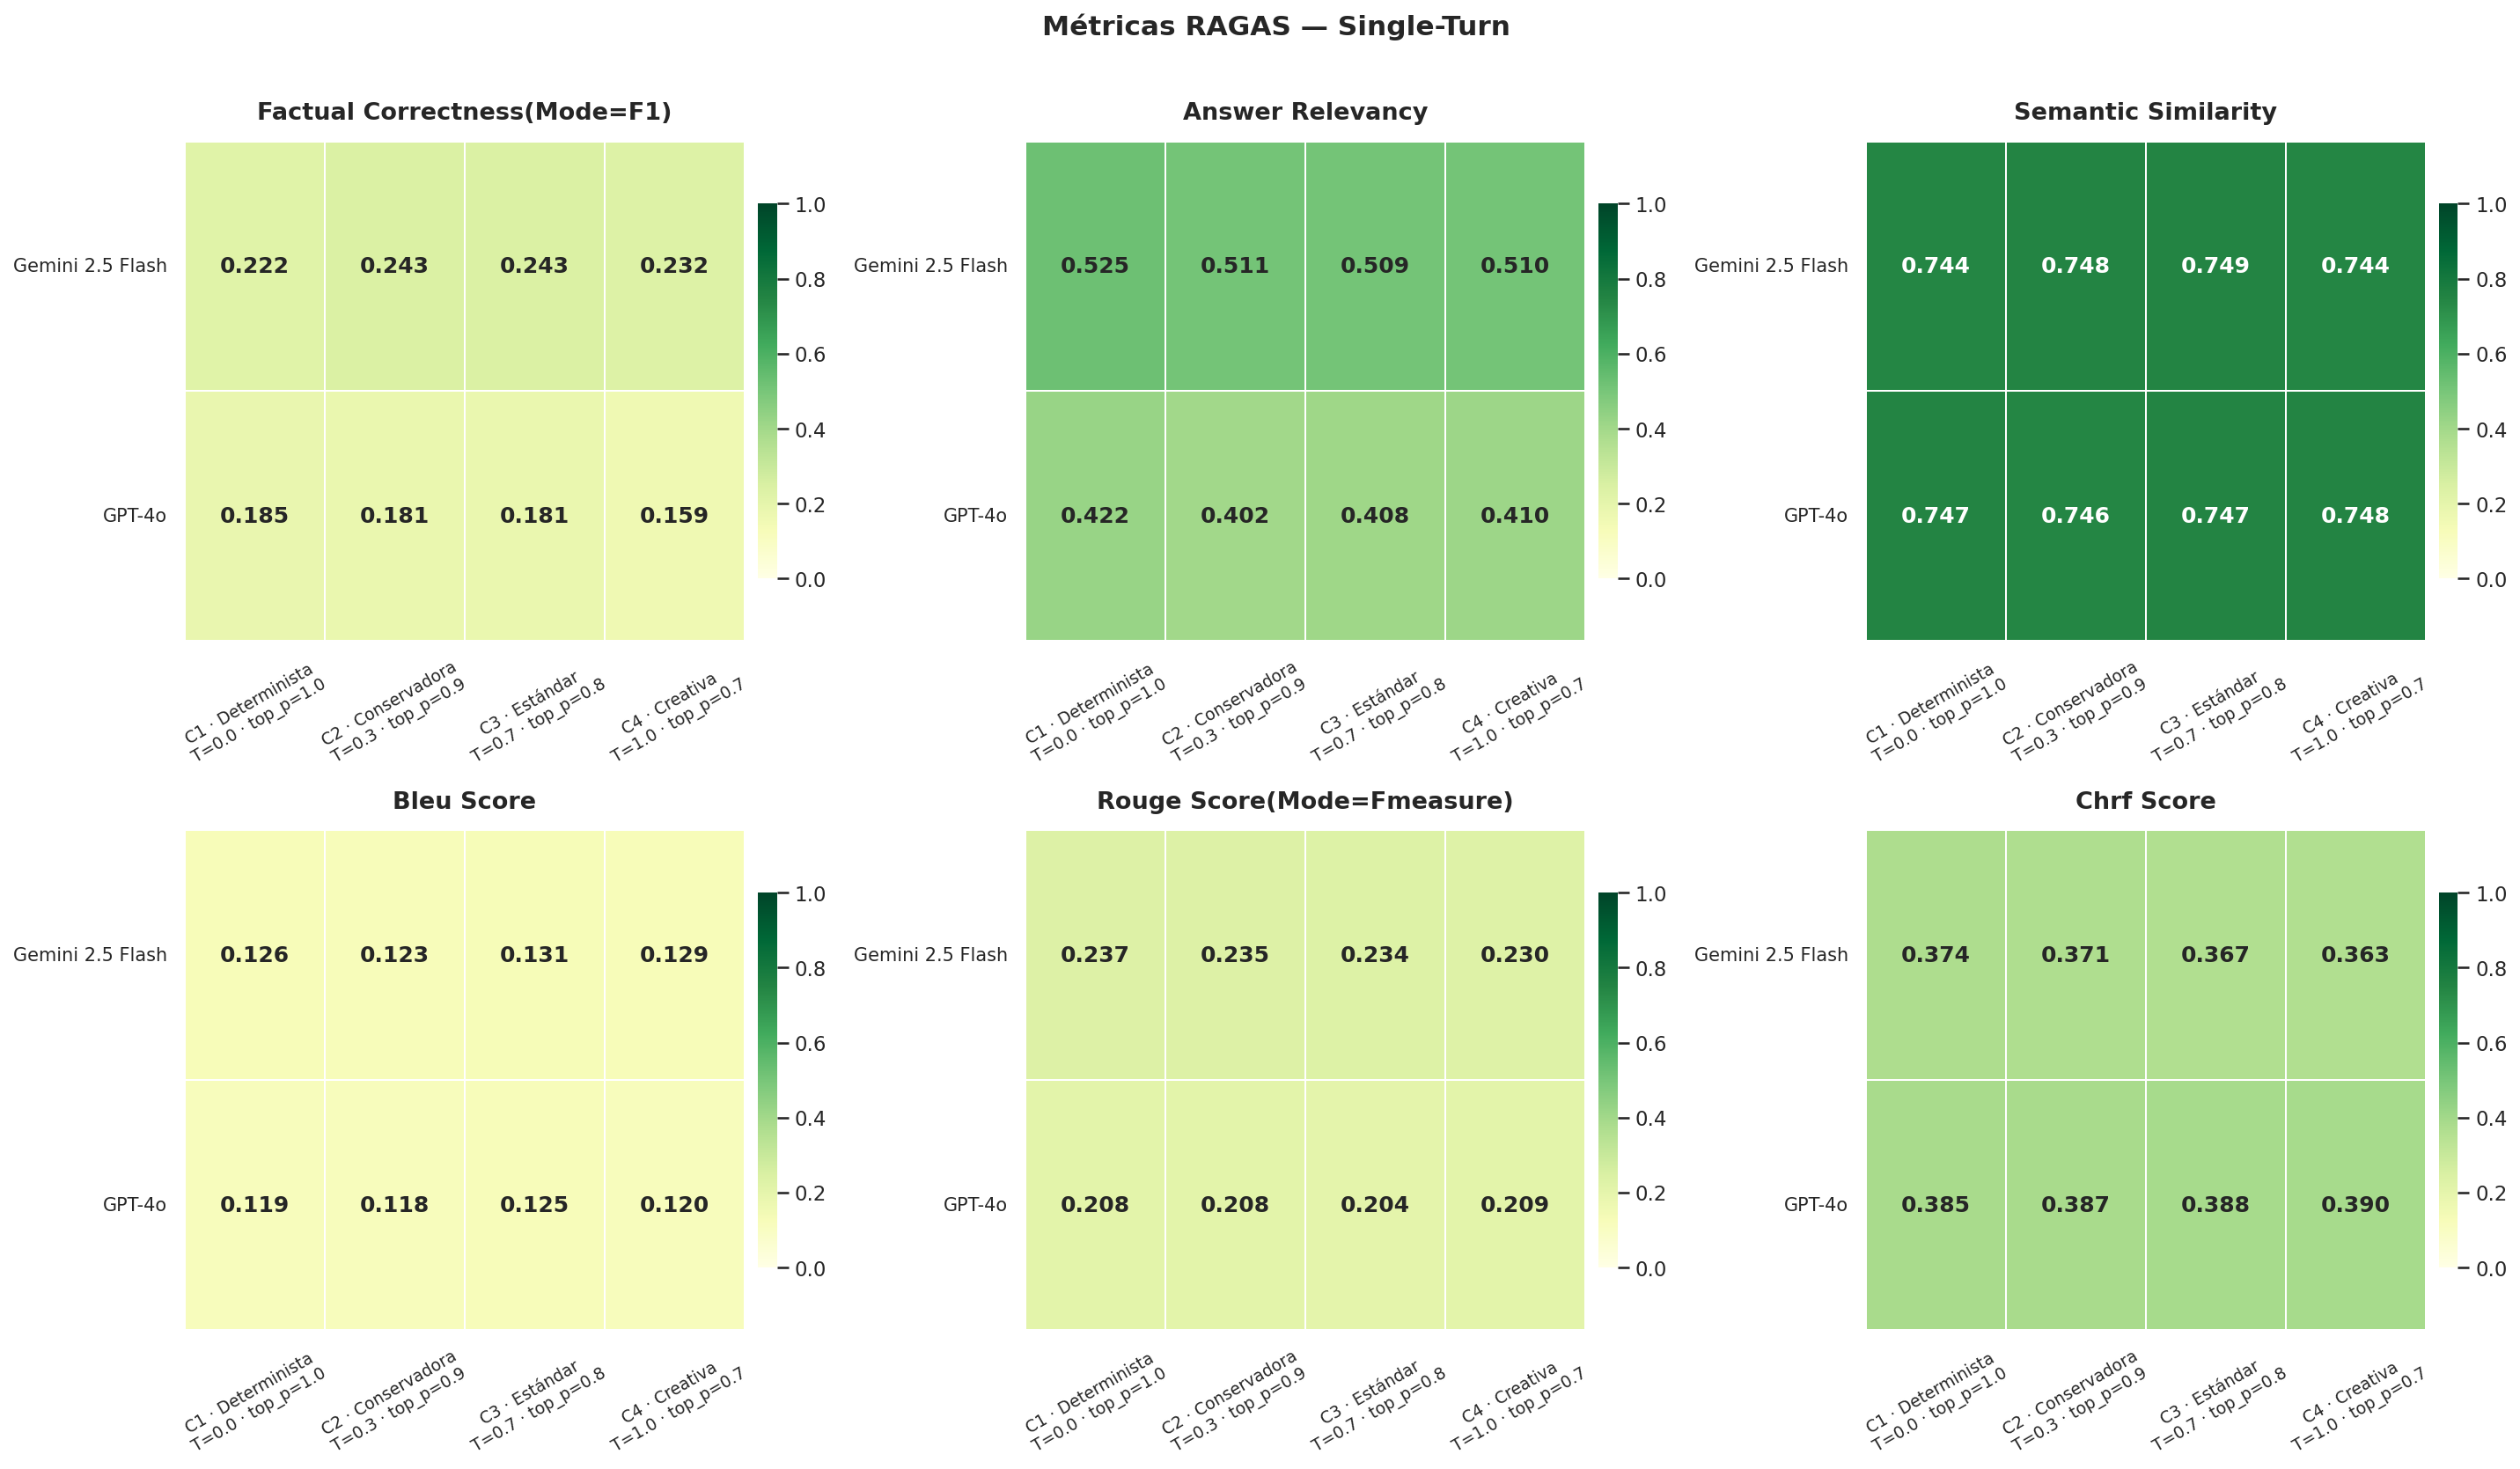

    fig01_heatmap_single_turn.png


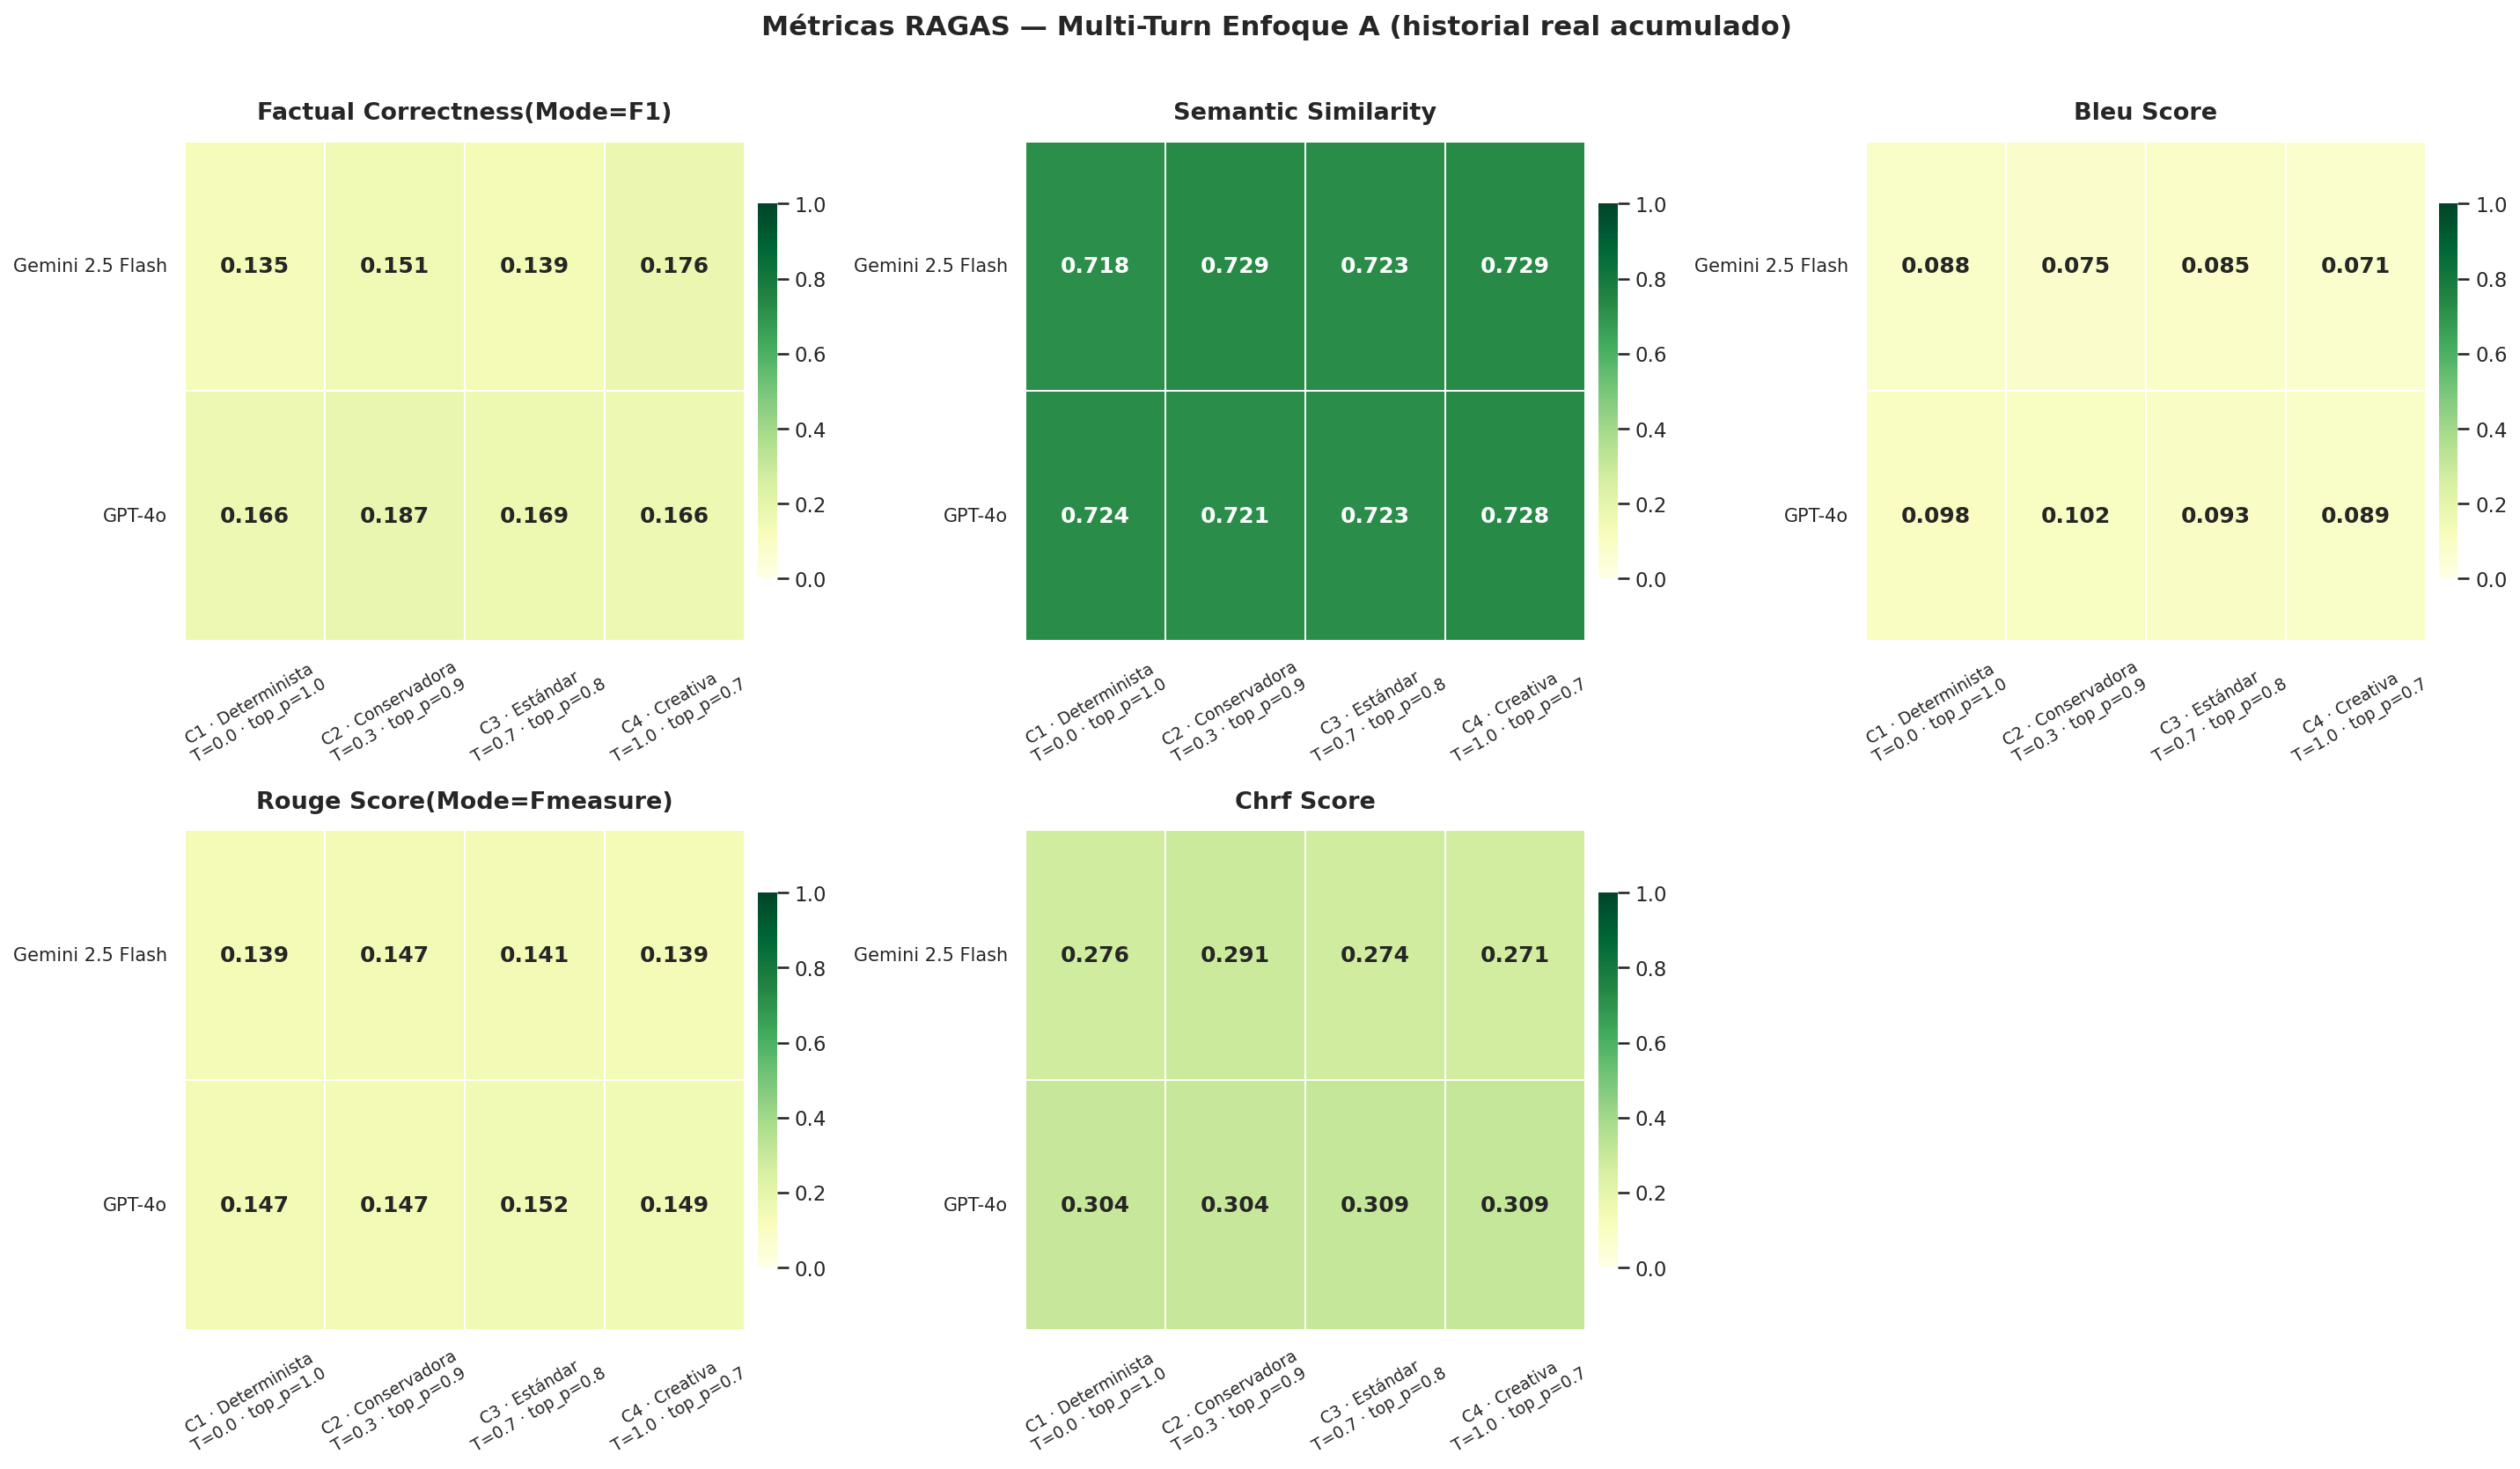

    fig02_heatmap_multi_turn_a.png


In [ ]:


# ──────────────────────────────────────────────────────────────
# CELDA 3.1 · Fig 01 y Fig 02 — Heatmaps RAGAS
# ──────────────────────────────────────────────────────────────
# %%

import math

def plot_heatmap(scores_df: pd.DataFrame, title: str,
                 filename: str, output_dir: Path,
                 exclude_metrics: list = None):
    available = get_available_metrics(scores_df, GENERATION_METRICS)
    if exclude_metrics:
        available = [m for m in available if m not in exclude_metrics]
    if not available:
        return

    agg = scores_df.groupby(["model", "config_id"])[available].mean().reset_index()
    n     = len(available)
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6.5 * ncols, 5.5 * nrows),
                             squeeze=False)
    axes_flat = axes.flatten()

    for ax, metric in zip(axes_flat, available):
        pivot = agg.pivot(index="model", columns="config_id", values=metric)
        pivot = pivot[[c for c in CONFIG_ORDER if c in pivot.columns]]
        pivot.index   = [MODEL_LABELS.get(m, m) for m in pivot.index]
        pivot.columns = [CONFIG_XLABELS.get(c, c) for c in pivot.columns]

        sns.heatmap(
            pivot, annot=True, fmt=".3f", cmap="YlGn",
            vmin=0, vmax=1, ax=ax, linewidths=0.8,
            annot_kws={"size": 12, "weight": "bold"},
            cbar_kws={"shrink": 0.75, "pad": 0.02},
        )
        ax.set_title(metric.replace("_", " ").title(),
                     fontsize=13, fontweight="bold", pad=12)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=9, rotation=30)
        ax.tick_params(axis="y", labelsize=10, rotation=0)

    # Ocultar ejes sobrantes si n no es múltiplo de ncols
    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    fig.tight_layout(h_pad=3.0, w_pad=2.5)
    save_fig(output_dir / filename)


# Fig 01: ST — AnswerRelevancy válida
plot_heatmap(df_st_scores,
             "Métricas RAGAS — Single-Turn",
             "fig01_heatmap_single_turn.png", PATH_EVAL)

# Fig 02: MT-A — AnswerRelevancy excluida (degradada por historial en user_input)
plot_heatmap(df_mt_a_scores,
             "Métricas RAGAS — Multi-Turn Enfoque A (historial real acumulado)",
             "fig02_heatmap_multi_turn_a.png", PATH_EVAL,
             exclude_metrics=["answer_relevancy"])

Explicación de las gráficas:

Interaction Plot — Single-Turn

Esta gráfica muestra cómo evoluciona la Factual Correctness media de cada modelo a medida que se incrementa la temperatura y se reduce el top_p (de C1 a C4), desglosando el efecto por tipo de pregunta. El interés analítico está en la forma de las líneas: si son paralelas, los parámetros de generación afectan a todas las categorías de manera homogénea; si se cruzan o divergen, existe un efecto diferencial que revela qué tipos de pregunta son más frágiles ante configuraciones más creativas. En particular, permite contrastar si las preguntas de tipo factual_trap — diseñadas para inducir alucinación — son más sensibles al incremento de temperatura que las factual_true, donde la respuesta correcta es más directa.

Interaction Plot — Multi-Turn Enfoque A

Esta gráfica replica el análisis anterior pero en el contexto conversacional, sustituyendo las categorías de pregunta por los patrones de conversación. Permite observar si el efecto desestabilizador de una mayor temperatura se amplifica o se amortigua según la estructura del diálogo: un patrón de recollection exige que el modelo mantenga coherencia con información mencionada varios turnos atrás, por lo que podría ser especialmente vulnerable a configuraciones con alta aleatoriedad; mientras que expansion o follow-up, al construirse sobre el turno inmediatamente anterior, podrían mostrar mayor robustez. Las líneas que divergen con el avance de las configuraciones evidencian que no todos los patrones conversacionales degradan la calidad factual al mismo ritmo.



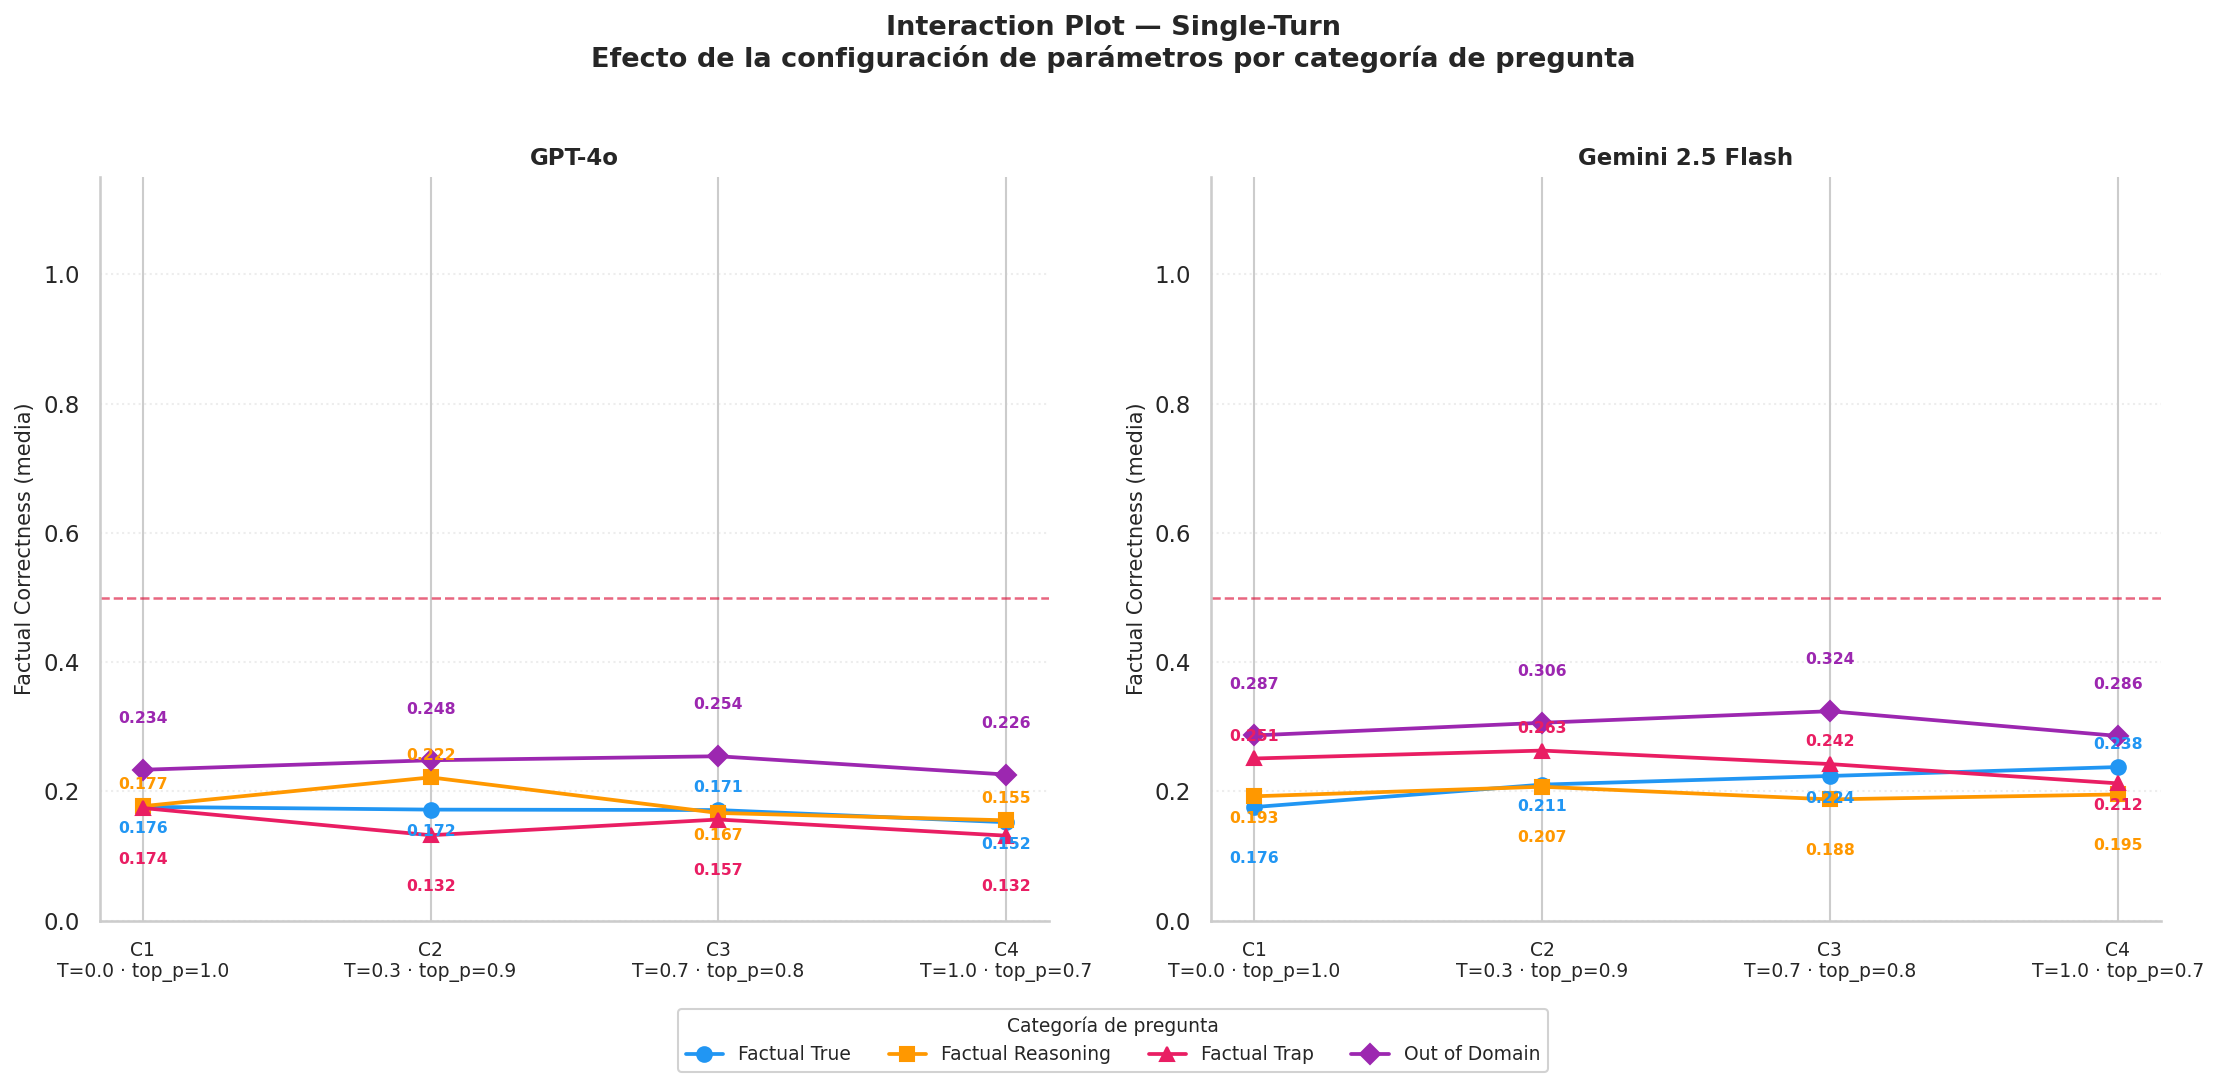

    fig_extra4_interaction_st.png


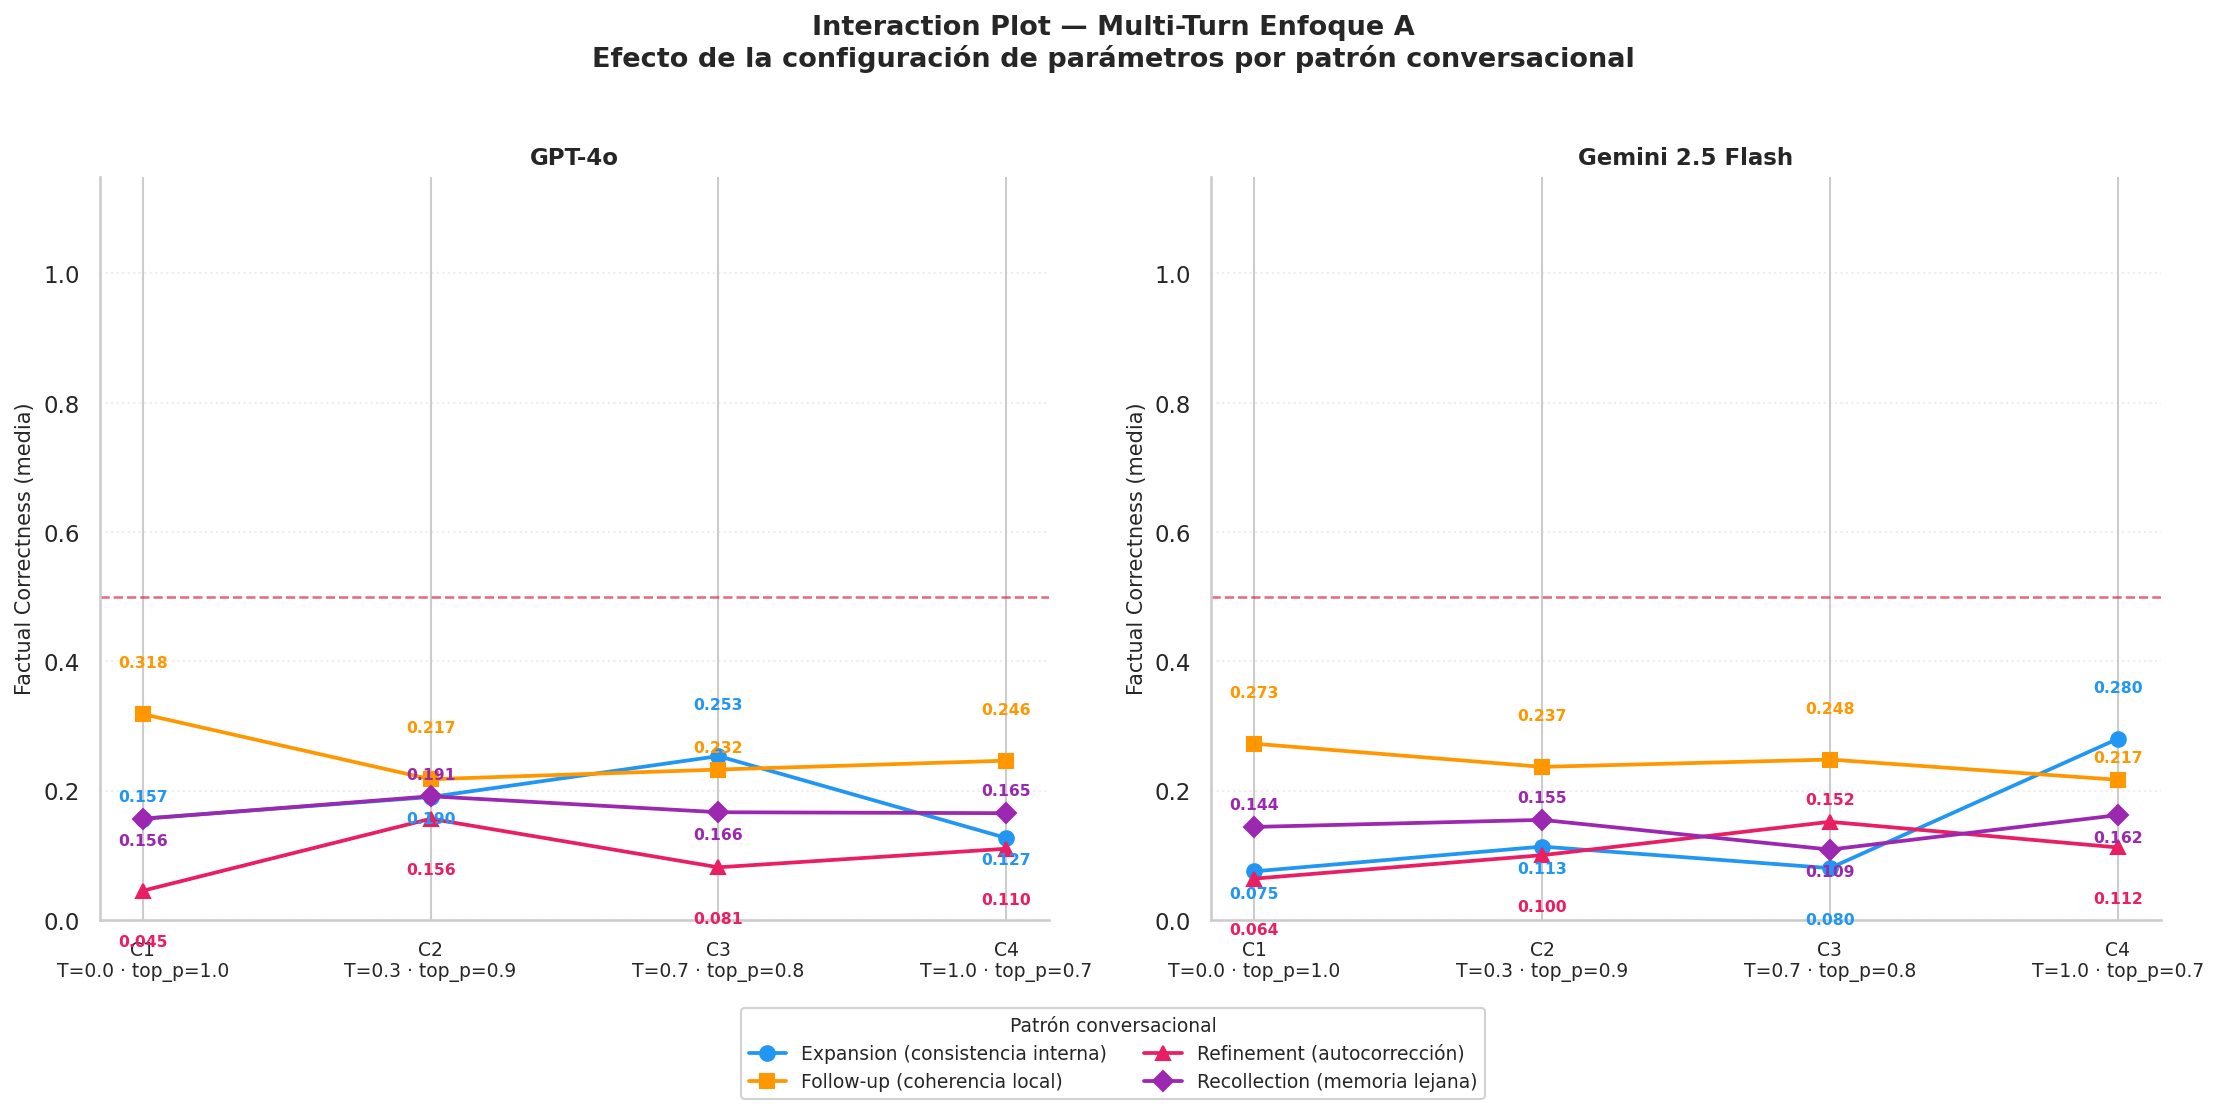

    fig_extra4_interaction_mt.png


In [ ]:
def plot_interaction_st_by_category(df_st: pd.DataFrame, output_dir: Path):
    metric = "factual_correctness(mode=f1)"
    if metric not in df_st.columns or "category" not in df_st.columns:
        print("Figura omitida: columnas necesarias no disponibles en ST.")
        return

    CAT_COLORS  = {"factual_true": "#2196F3", "factual_reasoning": "#FF9800",
                   "factual_trap": "#E91E63",  "out_of_domain":     "#9C27B0"}
    CAT_LABELS  = {"factual_true": "Factual True", "factual_reasoning": "Factual Reasoning",
                   "factual_trap": "Factual Trap", "out_of_domain":     "Out of Domain"}
    CAT_MARKERS = {"factual_true": "o", "factual_reasoning": "s",
                   "factual_trap": "^", "out_of_domain":     "D"}
    SHORT_XLABELS = {"C1": "C1\nT=0.0 · top_p=1.0", "C2": "C2\nT=0.3 · top_p=0.9",
                     "C3": "C3\nT=0.7 · top_p=0.8", "C4": "C4\nT=1.0 · top_p=0.7"}

    models     = [m for m in ["gpt4o", "gemini25flash"] if m in df_st["model"].unique()]
    categories = [c for c in CAT_COLORS if c in df_st["category"].unique()]
    configs    = [c for c in CONFIG_ORDER if c in df_st["config_id"].unique()]
    x_pos      = list(range(len(configs)))
    SPACING    = 14   # puntos entre anotaciones apiladas verticalmente

    fig, axes = plt.subplots(1, len(models), figsize=(7.5 * len(models), 6.5), squeeze=False)
    fig.subplots_adjust(bottom=0.20)
    legend_handles = []

    for col_idx, model in enumerate(models):
        ax       = axes[0][col_idx]
        df_model = df_st[df_st["model"] == model]
        agg      = df_model.groupby(["category", "config_id"])[metric].mean().reset_index()
        val_dict = {(r["category"], r["config_id"]): r[metric] for _, r in agg.iterrows()}

        for cat in categories:
            cat_data = (agg[agg["category"] == cat]
                        .set_index("config_id").reindex(configs).reset_index())
            ys   = cat_data[metric].values
            line, = ax.plot(x_pos, ys,
                            marker=CAT_MARKERS[cat], color=CAT_COLORS[cat],
                            linewidth=1.8, markersize=7, label=CAT_LABELS[cat])
            if col_idx == 0:
                legend_handles.append(line)

        # Anotaciones con posición vertical por rango en cada configuración
        for x_idx, config in enumerate(configs):
            config_vals = sorted(
                [(cat, val_dict[(cat, config)])
                 for cat in categories if (cat, config) in val_dict],
                key=lambda t: t[1]
            )
            n       = len(config_vals)
            offsets = [(i - (n - 1) / 2) * SPACING for i in range(n)]
            for (cat, val), offset in zip(config_vals, offsets):
                ax.annotate(f"{val:.3f}",
                            xy=(x_idx, val),
                            xytext=(0, offset), textcoords="offset points",
                            ha="center", va="bottom" if offset >= 0 else "top",
                            fontsize=7.5, color=CAT_COLORS[cat], fontweight="bold")

        ax.axhline(0.5, color="crimson", linestyle="--", linewidth=1.2, alpha=0.65)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([SHORT_XLABELS.get(c, c) for c in configs], fontsize=9)
        ax.set_ylabel("Factual Correctness (media)", fontsize=10)
        ax.set_ylim(0, 1.15)
        ax.set_title(MODEL_LABELS.get(model, model), fontsize=11, fontweight="bold")
        ax.grid(axis="y", linestyle=":", alpha=0.35)
        ax.spines[["top", "right"]].set_visible(False)

    fig.legend(handles=legend_handles,
               labels=[CAT_LABELS[c] for c in categories],
               loc="upper center", bbox_to_anchor=(0.5, 0.01),
               ncol=4, fontsize=9,
               title="Categoría de pregunta", title_fontsize=9,
               framealpha=0.88)
    fig.suptitle("Interaction Plot — Single-Turn\n"
                 "Efecto de la configuración de parámetros por categoría de pregunta",
                 fontsize=13, fontweight="bold", y=1.02)
    save_fig(output_dir / "fig_extra4_interaction_st.png")


def plot_interaction_mt_by_pattern(df_mt: pd.DataFrame, output_dir: Path):
    metric = "factual_correctness(mode=f1)"
    if metric not in df_mt.columns or "pattern" not in df_mt.columns:
        print("Figura omitida: columnas necesarias no disponibles en MT-A.")
        return

    PAT_COLORS  = {"expansion": "#2196F3", "follow-up": "#FF9800",
                   "refinement": "#E91E63", "recollection": "#9C27B0"}
    PAT_LABELS  = {"expansion":    "Expansion (consistencia interna)",
                   "follow-up":    "Follow-up (coherencia local)",
                   "refinement":   "Refinement (autocorrección)",
                   "recollection": "Recollection (memoria lejana)"}
    PAT_MARKERS = {"expansion": "o", "follow-up": "s",
                   "refinement": "^", "recollection": "D"}
    SHORT_XLABELS = {"C1": "C1\nT=0.0 · top_p=1.0", "C2": "C2\nT=0.3 · top_p=0.9",
                     "C3": "C3\nT=0.7 · top_p=0.8", "C4": "C4\nT=1.0 · top_p=0.7"}

    models   = [m for m in ["gpt4o", "gemini25flash"] if m in df_mt["model"].unique()]
    patterns = [p for p in PAT_COLORS if p in df_mt["pattern"].unique()]
    configs  = [c for c in CONFIG_ORDER if c in df_mt["config_id"].unique()]
    x_pos    = list(range(len(configs)))
    SPACING  = 14

    fig, axes = plt.subplots(1, len(models), figsize=(7.5 * len(models), 6.5), squeeze=False)
    fig.subplots_adjust(bottom=0.20)
    legend_handles = []

    for col_idx, model in enumerate(models):
        ax       = axes[0][col_idx]
        df_model = df_mt[df_mt["model"] == model]
        agg      = df_model.groupby(["pattern", "config_id"])[metric].mean().reset_index()
        val_dict = {(r["pattern"], r["config_id"]): r[metric] for _, r in agg.iterrows()}

        for pat in patterns:
            pat_data = (agg[agg["pattern"] == pat]
                        .set_index("config_id").reindex(configs).reset_index())
            ys    = pat_data[metric].values
            line, = ax.plot(x_pos, ys,
                            marker=PAT_MARKERS[pat], color=PAT_COLORS[pat],
                            linewidth=1.8, markersize=7, label=PAT_LABELS[pat])
            if col_idx == 0:
                legend_handles.append(line)

        for x_idx, config in enumerate(configs):
            config_vals = sorted(
                [(pat, val_dict[(pat, config)])
                 for pat in patterns if (pat, config) in val_dict],
                key=lambda t: t[1]
            )
            n       = len(config_vals)
            offsets = [(i - (n - 1) / 2) * SPACING for i in range(n)]
            for (pat, val), offset in zip(config_vals, offsets):
                ax.annotate(f"{val:.3f}",
                            xy=(x_idx, val),
                            xytext=(0, offset), textcoords="offset points",
                            ha="center", va="bottom" if offset >= 0 else "top",
                            fontsize=7.5, color=PAT_COLORS[pat], fontweight="bold")

        ax.axhline(0.5, color="crimson", linestyle="--", linewidth=1.2, alpha=0.65)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([SHORT_XLABELS.get(c, c) for c in configs], fontsize=9)
        ax.set_ylabel("Factual Correctness (media)", fontsize=10)
        ax.set_ylim(0, 1.15)
        ax.set_title(MODEL_LABELS.get(model, model), fontsize=11, fontweight="bold")
        ax.grid(axis="y", linestyle=":", alpha=0.35)
        ax.spines[["top", "right"]].set_visible(False)

    fig.legend(handles=legend_handles,
               labels=[PAT_LABELS[p] for p in patterns],
               loc="upper center", bbox_to_anchor=(0.5, 0.01),
               ncol=2, fontsize=9,
               title="Patrón conversacional", title_fontsize=9,
               framealpha=0.88)
    fig.suptitle("Interaction Plot — Multi-Turn Enfoque A\n"
                 "Efecto de la configuración de parámetros por patrón conversacional",
                 fontsize=13, fontweight="bold", y=1.02)
    save_fig(output_dir / "fig_extra4_interaction_mt.png")


plot_interaction_st_by_category(df_st_scores, PATH_EVAL)
plot_interaction_mt_by_pattern(df_mt_a_scores, PATH_EVAL)


Explicación de la gráfica:
--

Fig 03 — Degradación Conversacional ST vs MT-A
Qué muestra: Un gráfico de barras agrupadas donde cada grupo del eje X es un modelo (GPT-4o, Gemini 2.5 Flash). Dentro de cada grupo hay dos barras:

Barra sólida (opacidad alta): media global de factual_correctness en Single-Turn.

Barra rayada (hatch="///", más transparente): media global de factual_correctness en Multi-Turn Enfoque A


Sobre cada barra de MT-A aparece anotado el delta Δ = MT − ST en rojo si es negativo (degradación) o verde si es positivo (mejora inesperada).

Qué se pretende ver: Esta es la figura central del argumento del TFG. Cuantifica directamente cuánto cae la corrección factual cuando el modelo deja de responder preguntas aisladas y empieza a acumular historial conversacional. Un Δ negativo grande y en rojo es la evidencia de que el historial actúa como amplificador de alucinaciones: los errores cometidos en turnos anteriores se propagan y contaminan las respuestas siguientes.

Se usa exclusivamente factual_correctness (y no, por ejemplo, bleu_score) porque es la métrica que mejor captura si el modelo está inventando información, que es exactamente lo que el TFG quiere medir.


En esta gráfica se agrupa por modelo, por lo que cada barra es la media de factual_correctness colapsando las 4 configuraciones juntas para ese modelos. Se compara la media global de la métrica factual correctness para todas las configuraciones de parámetros de generación.

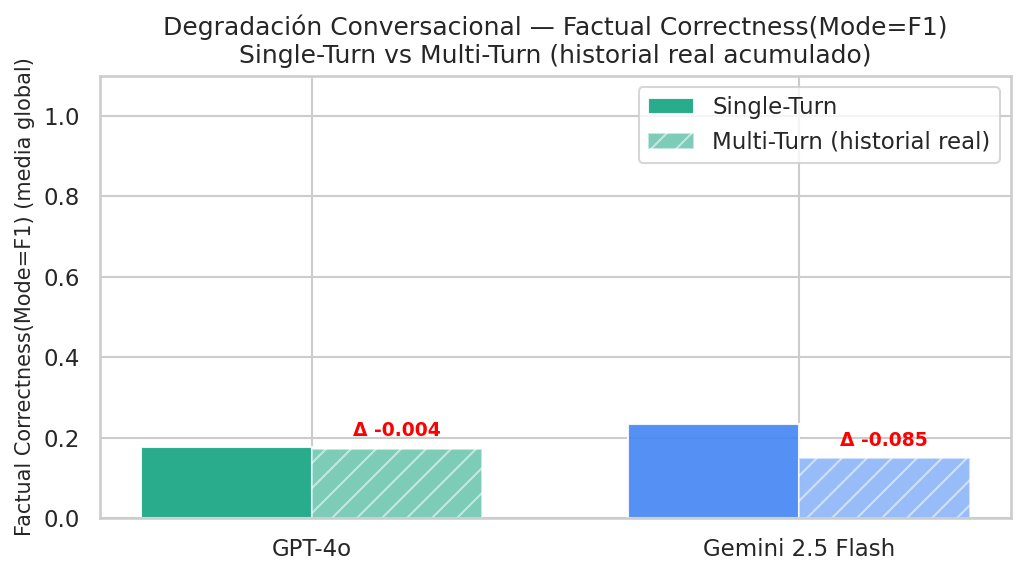

    fig03_degradacion_factual_correctness(mode=f1).png


In [ ]:
# ──────────────────────────────────────────────────────────────
# CELDA 3.2 · Fig 03 — Degradación conversacional ST vs MT-A
# ──────────────────────────────────────────────────────────────
# %%

def plot_degradation(df_st: pd.DataFrame, df_mt: pd.DataFrame,
                     metric: str, output_dir: Path):
    """
    Compara la misma métrica en ST vs MT-A por modelo.
    Visualiza cuánto se degrada la calidad al introducir historial real.
    """
    if metric not in df_st.columns or metric not in df_mt.columns:
        return

    models   = list(MODEL_LABELS.keys())
    st_means = [df_st[df_st["model"] == m][metric].mean() for m in models]
    mt_means = [df_mt[df_mt["model"] == m][metric].mean() for m in models]

    x     = np.arange(len(models))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))

    bars_st = ax.bar(x - width / 2, st_means, width,
                     color=[MODEL_COLORS.get(m, "#888") for m in models],
                     alpha=0.9, label="Single-Turn")
    bars_mt = ax.bar(x + width / 2, mt_means, width,
                     color=[MODEL_COLORS.get(m, "#888") for m in models],
                     alpha=0.55, hatch="//", label="Multi-Turn (historial real)")

    # Anotación de la diferencia
    for i, (st, mt) in enumerate(zip(st_means, mt_means)):
        delta = mt - st
        color = "red" if delta < 0 else "green"
        ax.annotate(f"Δ {delta:+.3f}", xy=(x[i] + width / 2, mt),
                    xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=9, color=color, weight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS.get(m, m) for m in models])
    ax.set_ylabel(f"{metric.replace('_', ' ').title()} (media global)")
    ax.set_title(f"Degradación Conversacional — {metric.replace('_', ' ').title()}"
                 f"\nSingle-Turn vs Multi-Turn (historial real acumulado)")
    ax.set_ylim(0, 1.1)
    ax.legend()
    save_fig(output_dir / f"fig03_degradacion_{metric}.png")


plot_degradation(df_st_scores, df_mt_a_scores,
                 "factual_correctness(mode=f1)", PATH_EVAL)


Fig Extra 3 — Delta de degradación ST→MT-A por patrón conversacional
Qué muestra: Barras del delta Δ = FC_MT-A − FC_ST por patrón conversacional, con una línea horizontal en y=0 como referencia. Barras por debajo de cero (en rojo) indican degradación al añadir historial; barras por encima (en verde) indicarían mejora. Hay dos barras por patrón, una por modelo.

Por qué es importante: Responde la pregunta más específica del diseño experimental: ¿qué tipo de conversación hace que el modelo alucinea más? recollection debería mostrar el Δ más negativo porque exige recordar información de turnos lejanos, mientras follow-up debería ser el menos dañino. Esta jerarquía de patrones es el argumento más fino del TFG.

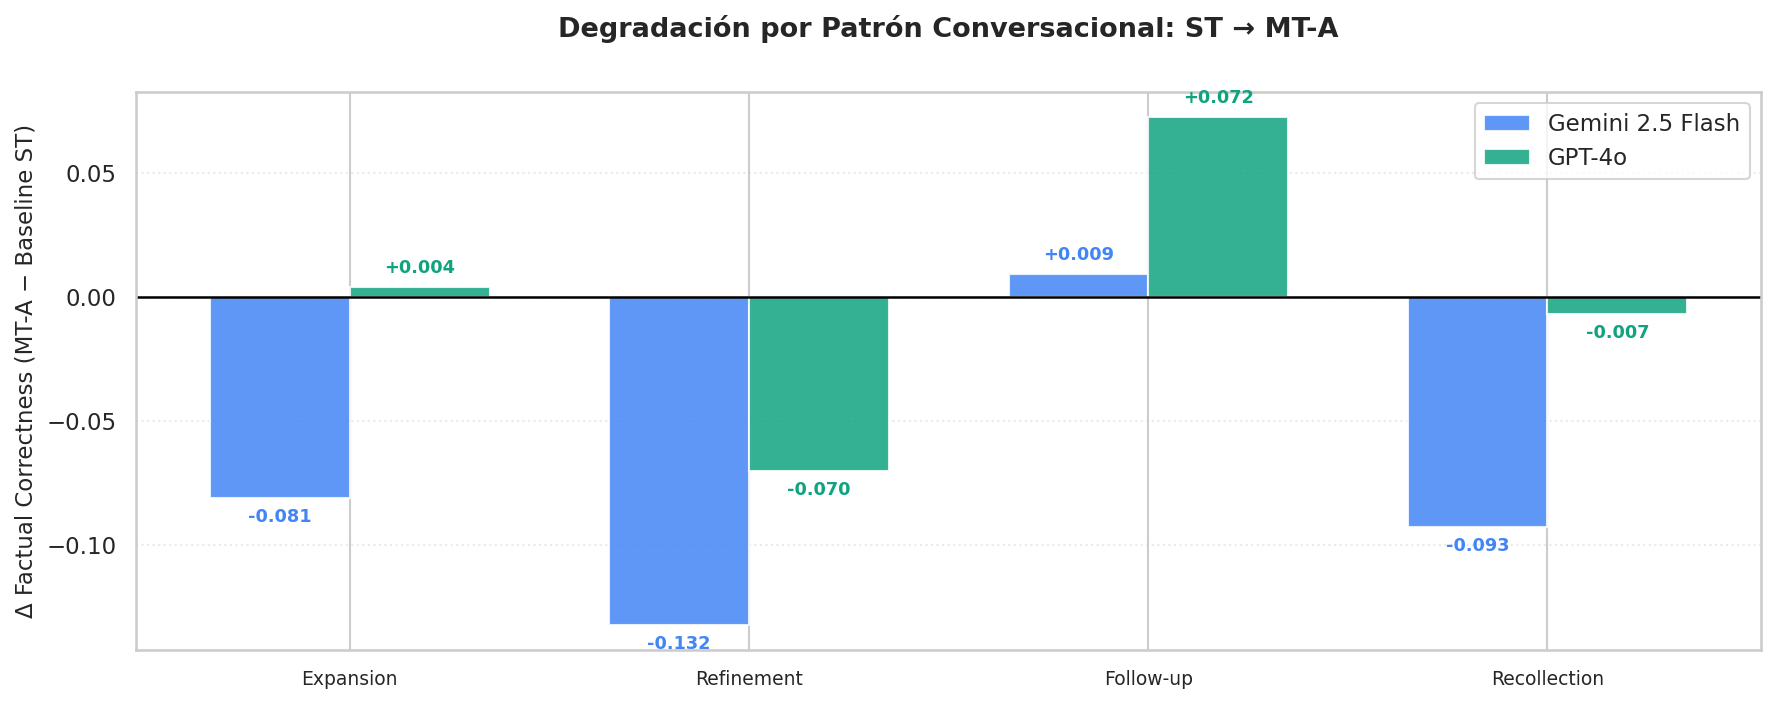

    fig_extra3_delta_por_patron.png


In [ ]:
def plot_degradation_by_pattern(df_st: pd.DataFrame, df_mt: pd.DataFrame,
                                 output_dir: Path):
    metric = "factual_correctness(mode=f1)"
    if metric not in df_st.columns or metric not in df_mt.columns:
        print("Figura omitida: columna FC no disponible.")
        return
    if "pattern" not in df_mt.columns:
        print("Figura omitida: columna 'pattern' no disponible.")
        return

    pattern_labels = {
        "expansion":    "Expansion\n",
        "refinement":   "Refinement\n",
        "follow-up":    "Follow-up\n",
        "recollection": "Recollection\n",
    }

    st_means = df_st.groupby("model")[metric].mean()
    mt_means = df_mt.groupby(["model", "pattern"])[metric].mean().reset_index()
    patterns = [p for p in pattern_labels if p in mt_means["pattern"].unique()]
    models   = list(st_means.index)

    x     = np.arange(len(patterns))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))

    for i, model in enumerate(models):
        deltas = []
        for p in patterns:
            sub    = mt_means[(mt_means["model"] == model) &
                              (mt_means["pattern"] == p)][metric]
            mt_val = sub.values[0] if len(sub) > 0 else np.nan
            st_val = st_means.get(model, np.nan)
            deltas.append(mt_val - st_val)

        offset = (i - len(models) / 2 + 0.5) * width
        color  = MODEL_COLORS.get(model, "#888")
        bars   = ax.bar(x + offset, deltas, width,
                        color=color,#[color if d < 0 else "#2ecc71" for d in deltas],
                        alpha=0.85, label=MODEL_LABELS.get(model, model),
                        edgecolor="white")

        for bar, delta in zip(bars, deltas):
            if not np.isnan(delta):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    delta + (0.004 if delta >= 0 else -0.004),
                    f"{delta:+.3f}",
                    ha="center",
                    va="bottom" if delta >= 0 else "top",
                    fontsize=8.5, fontweight="bold", color=color,
                )

    ax.set_xticks(x)
    ax.set_xticklabels([pattern_labels.get(p, p) for p in patterns], fontsize=9)
    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_ylabel("Δ Factual Correctness (MT-A − Baseline ST)", fontsize=11)
    ax.set_title("Degradación por Patrón Conversacional: ST → MT-A\n",
                 fontsize=13, fontweight="bold", pad=12)
    ax.legend()
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    fig.tight_layout()
    save_fig(output_dir / "fig_extra3_delta_por_patron.png")


plot_degradation_by_pattern(df_st_scores, df_mt_a_scores, PATH_EVAL)


Fig Extra 2 — Tasa de alucinación (% respuestas con FC < 0.5)
Qué muestra: Dos heatmaps lado a lado (ST y MT-A) con la misma estructura de modelos × configuraciones que las Fig 01/02, pero en lugar de mostrar el score medio, muestran el porcentaje de respuestas clasificadas como alucinación (FC < 0.5). La escala de color es YlOrRd (amarillo→rojo), donde el rojo indica más alucinación.

Por qué es importante: Transforma un resultado técnico (score medio 0.18) en un dato comprensible para cualquier lector del TFG: "GPT-4o en configuración creativa alucinó en el 74% de las respuestas". Es la misma información que los heatmaps de scores pero con un impacto narrativo incomparablemente mayo

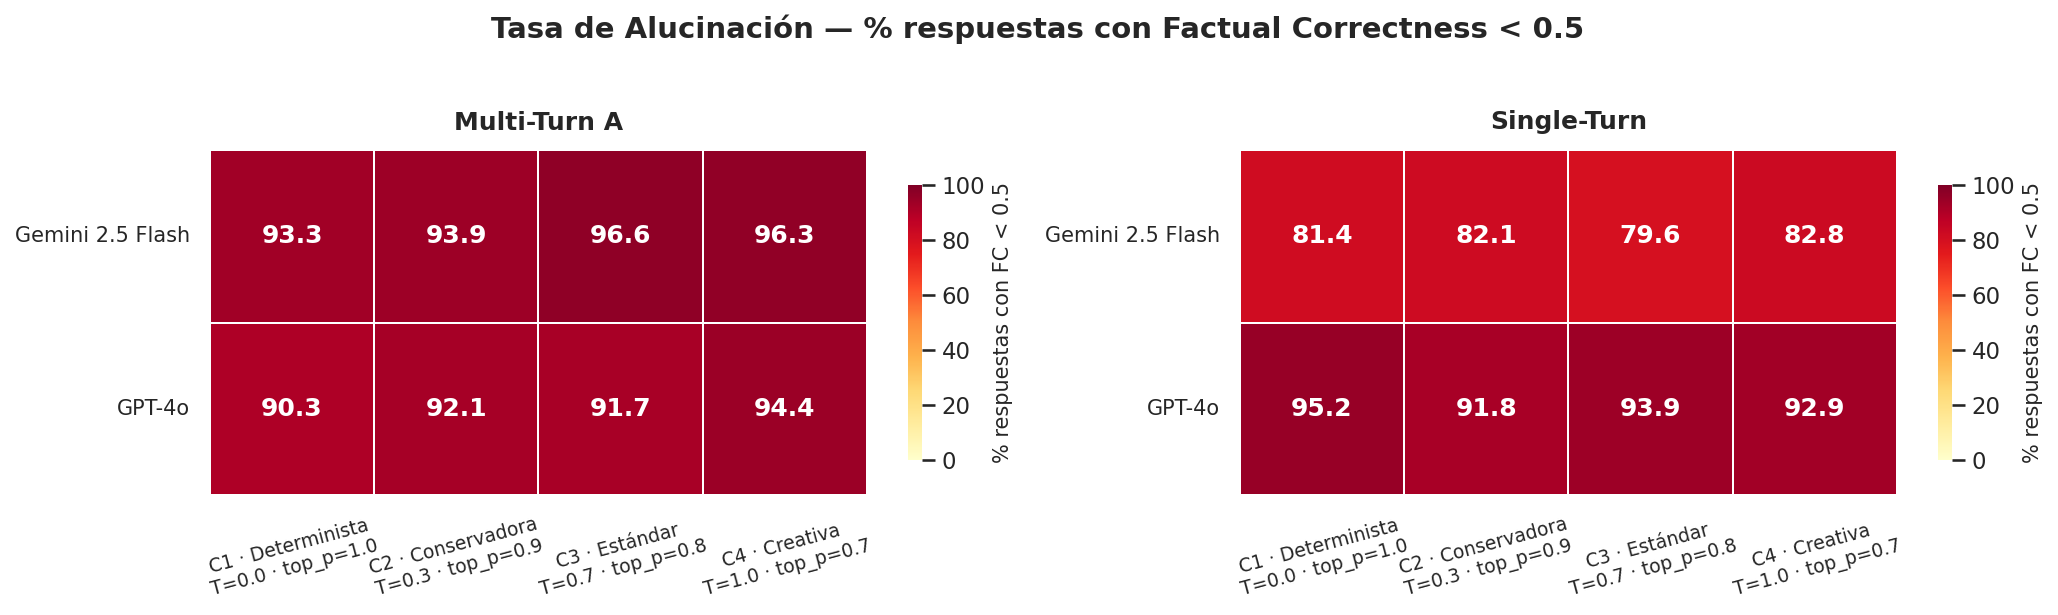

    fig_extra2_tasa_alucinacion.png


In [ ]:
def plot_hallucination_rate(df_st: pd.DataFrame, df_mt: pd.DataFrame,
                             output_dir: Path):
    metric = "factual_correctness(mode=f1)"
    umbral = 0.5

    results = []
    for eval_label, df in [("Single-Turn", df_st), ("Multi-Turn A", df_mt)]:
        if metric not in df.columns:
            continue
        valid = df[df[metric].notna()].copy()
        valid["halucina"] = (valid[metric] < umbral).astype(int)
        agg = valid.groupby(["model", "config_id"])["halucina"].mean().reset_index()
        agg["eval_type"] = eval_label
        results.append(agg)

    if not results:
        print("Figura omitida: sin datos válidos.")
        return

    df_rates = pd.concat(results)
    df_rates["tasa_%"] = df_rates["halucina"] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, (eval_type, sub_df) in zip(axes, df_rates.groupby("eval_type")):
        pivot = sub_df.pivot(index="model", columns="config_id", values="tasa_%")
        pivot = pivot[[c for c in CONFIG_ORDER if c in pivot.columns]]
        pivot.index   = [MODEL_LABELS.get(m, m) for m in pivot.index]
        pivot.columns = [CONFIG_XLABELS.get(c, c) for c in pivot.columns]

        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
                    vmin=0, vmax=100, ax=ax, linewidths=0.8,
                    annot_kws={"size": 12, "weight": "bold"},
                    cbar_kws={"label": "% respuestas con FC < 0.5",
                              "shrink": 0.8})
        ax.set_title(eval_type, fontsize=12, fontweight="bold", pad=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=9, rotation=15)
        ax.tick_params(axis="y", labelsize=10, rotation=0)

    fig.suptitle("Tasa de Alucinación — % respuestas con Factual Correctness < 0.5",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout(w_pad=3.0)
    save_fig(output_dir / "fig_extra2_tasa_alucinacion.png")


plot_hallucination_rate(df_st_scores, df_mt_a_scores, PATH_EVAL)


Explicación de las gráficas:

Fig 04 y Fig 05 — Evolución de métricas por temperatura
Qué muestra: Una fila de gráficas de líneas, una por cada métrica disponible. En cada gráfica:

Eje X: las 4 configuraciones en orden C1→C4 (de determinista a creativa), etiquetadas con temperatura y top_p
Eje Y: score medio (0–1) de esa métrica para ese punto de configuración
Una línea por modelo (GPT-4o en verde, Gemini en azul), con marcadores circulares en cada configuración
Línea horizontal gris discontinua en y=0.5 como referencia visual del umbral de alucinación
La diferencia entre Fig 04 y Fig 05:

Fig 04 usa df_st_scores con todas las métricas incluida answer_relevancy
Fig 05 usa df_mt_a_scores excluyendo answer_relevancy (por la misma razón que en los heatmaps: el historial concatenado en user_input corrompe esa métrica)
Qué se pretende ver: Si existe una tendencia monotónica de degradación al aumentar temperatura y reducir top_p. Los patrones posibles son:

-Línea descendente C1→C4: la mayor aleatoriedad aumenta las alucinaciones, confirmando que configuraciones más creativas son menos fiables para tareas factuales

-Línea plana: el modelo es robusto a la temperatura en ese rango, lo que sería un hallazgo relevante

-Cruce de líneas entre modelos: uno de los modelos es más sensible a la temperatura que el otro, lo que permitiría recomendar configuraciones distintas según el modelo

Esta figura complementa directamente a los heatmaps: mientras los heatmaps muestran el valor absoluto de cada celda (modelo × config), esta figura convierte el eje de configuraciones en un eje continuo de "creatividad creciente" y permite ver la pendiente de degradación de cada modelo, que es el dato clave para las conclusiones del TFG.

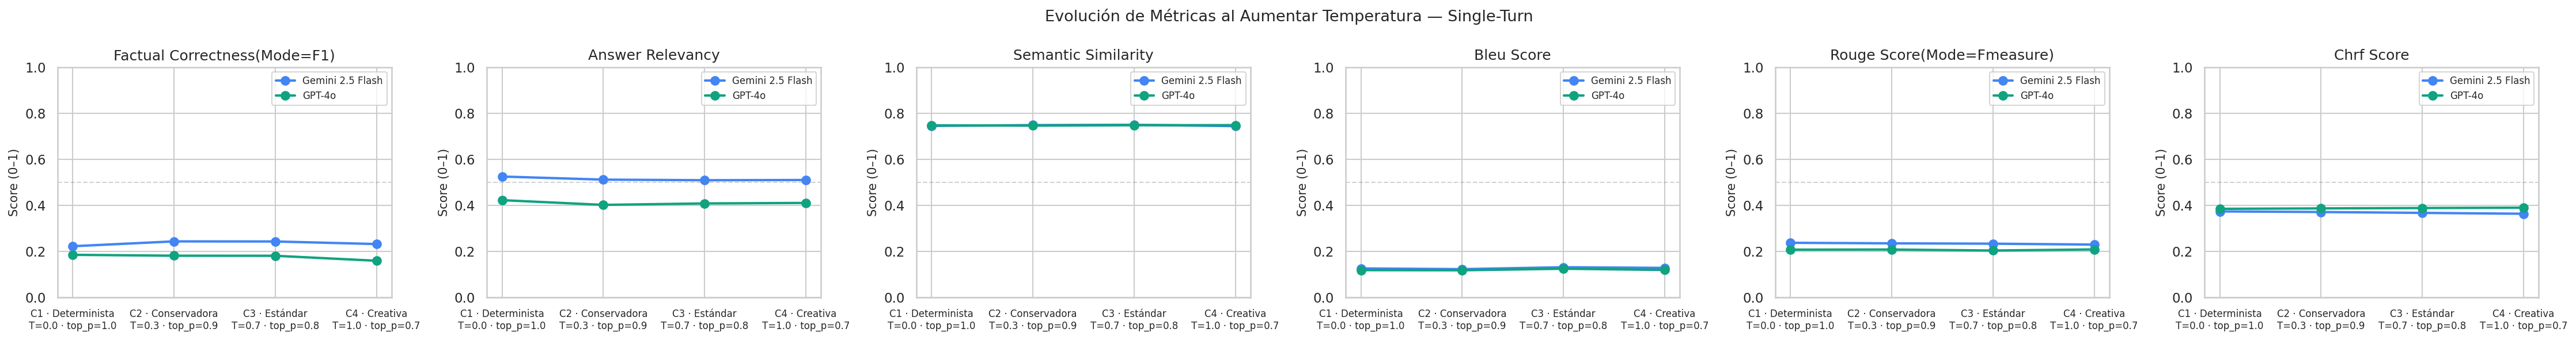

    fig04_temperatura_single_turn.png


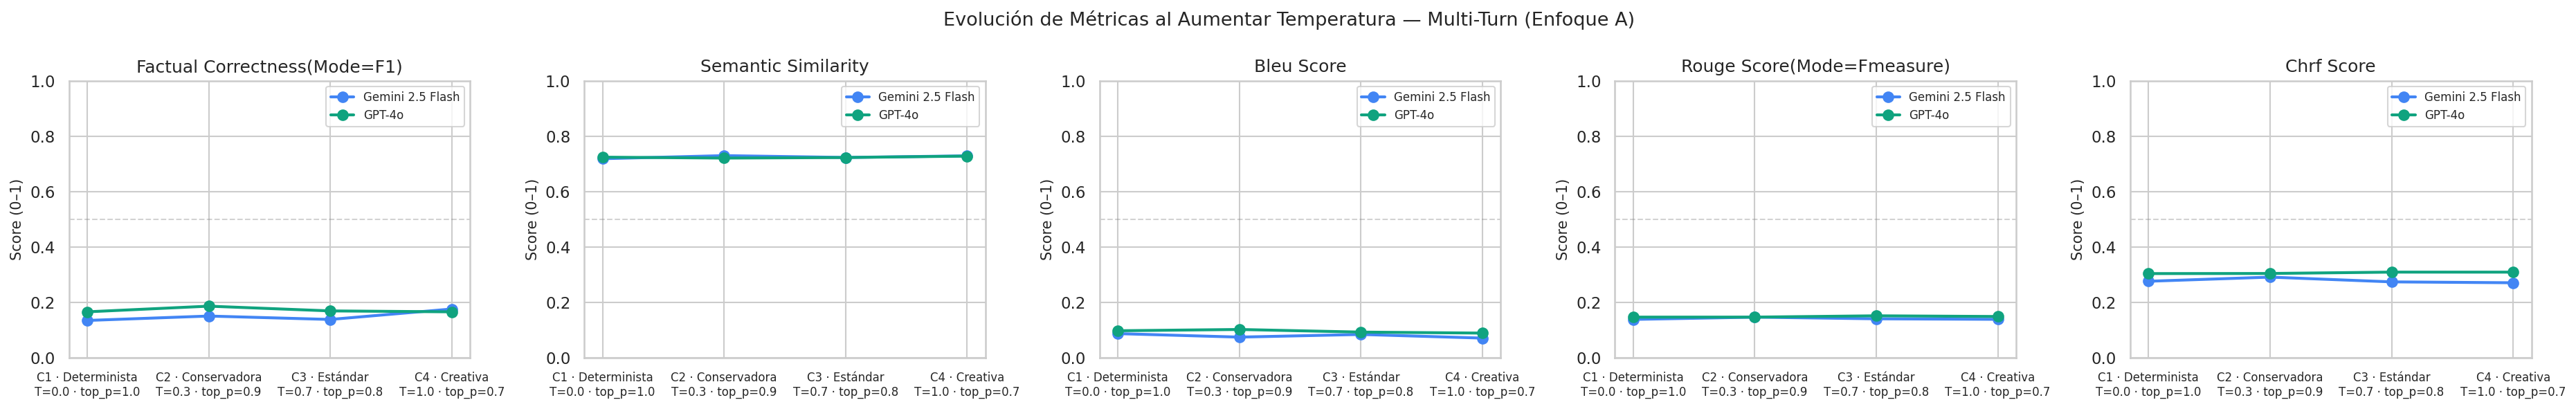

    fig05_temperatura_multi_turn_a.png


In [ ]:

# ──────────────────────────────────────────────────────────────
# CELDA 3.3 · Fig 04 y Fig 05 — Evolución por temperatura
# ──────────────────────────────────────────────────────────────
# %%

def plot_temperature_evolution(scores_df: pd.DataFrame, title: str,
                                filename: str, output_dir: Path,
                                exclude_metrics: list = None):
    available = get_available_metrics(scores_df, GENERATION_METRICS)
    if exclude_metrics:
        available = [m for m in available if m not in exclude_metrics]
    if not available:
        return
    agg = scores_df.groupby(["model", "config_id"])[available].mean().reset_index()
    n   = len(available)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=False)
    if n == 1: axes = [axes]
    for ax, metric in zip(axes, available):
        for model in agg["model"].unique():
            sub = agg[agg["model"] == model].set_index("config_id")
            sub = sub.reindex(CONFIG_ORDER).dropna(subset=[metric])
            ax.plot(range(len(sub)), sub[metric].values,
                    "o-", color=MODEL_COLORS.get(model, "#888"),
                    label=MODEL_LABELS.get(model, model),
                    linewidth=2, markersize=7)
        ax.set_xticks(range(len(CONFIG_ORDER)))
        ax.set_xticklabels([CONFIG_XLABELS.get(c, c) for c in CONFIG_ORDER], fontsize=8)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylabel("Score (0–1)")
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)
    fig.suptitle(title, fontsize=13)
    save_fig(output_dir / filename)


plot_temperature_evolution(
    df_st_scores,
    "Evolución de Métricas al Aumentar Temperatura — Single-Turn",
    "fig04_temperatura_single_turn.png", PATH_EVAL)

plot_temperature_evolution(
    df_mt_a_scores,
    "Evolución de Métricas al Aumentar Temperatura — Multi-Turn (Enfoque A)",
    "fig05_temperatura_multi_turn_a.png", PATH_EVAL,
    exclude_metrics=["answer_relevancy"])

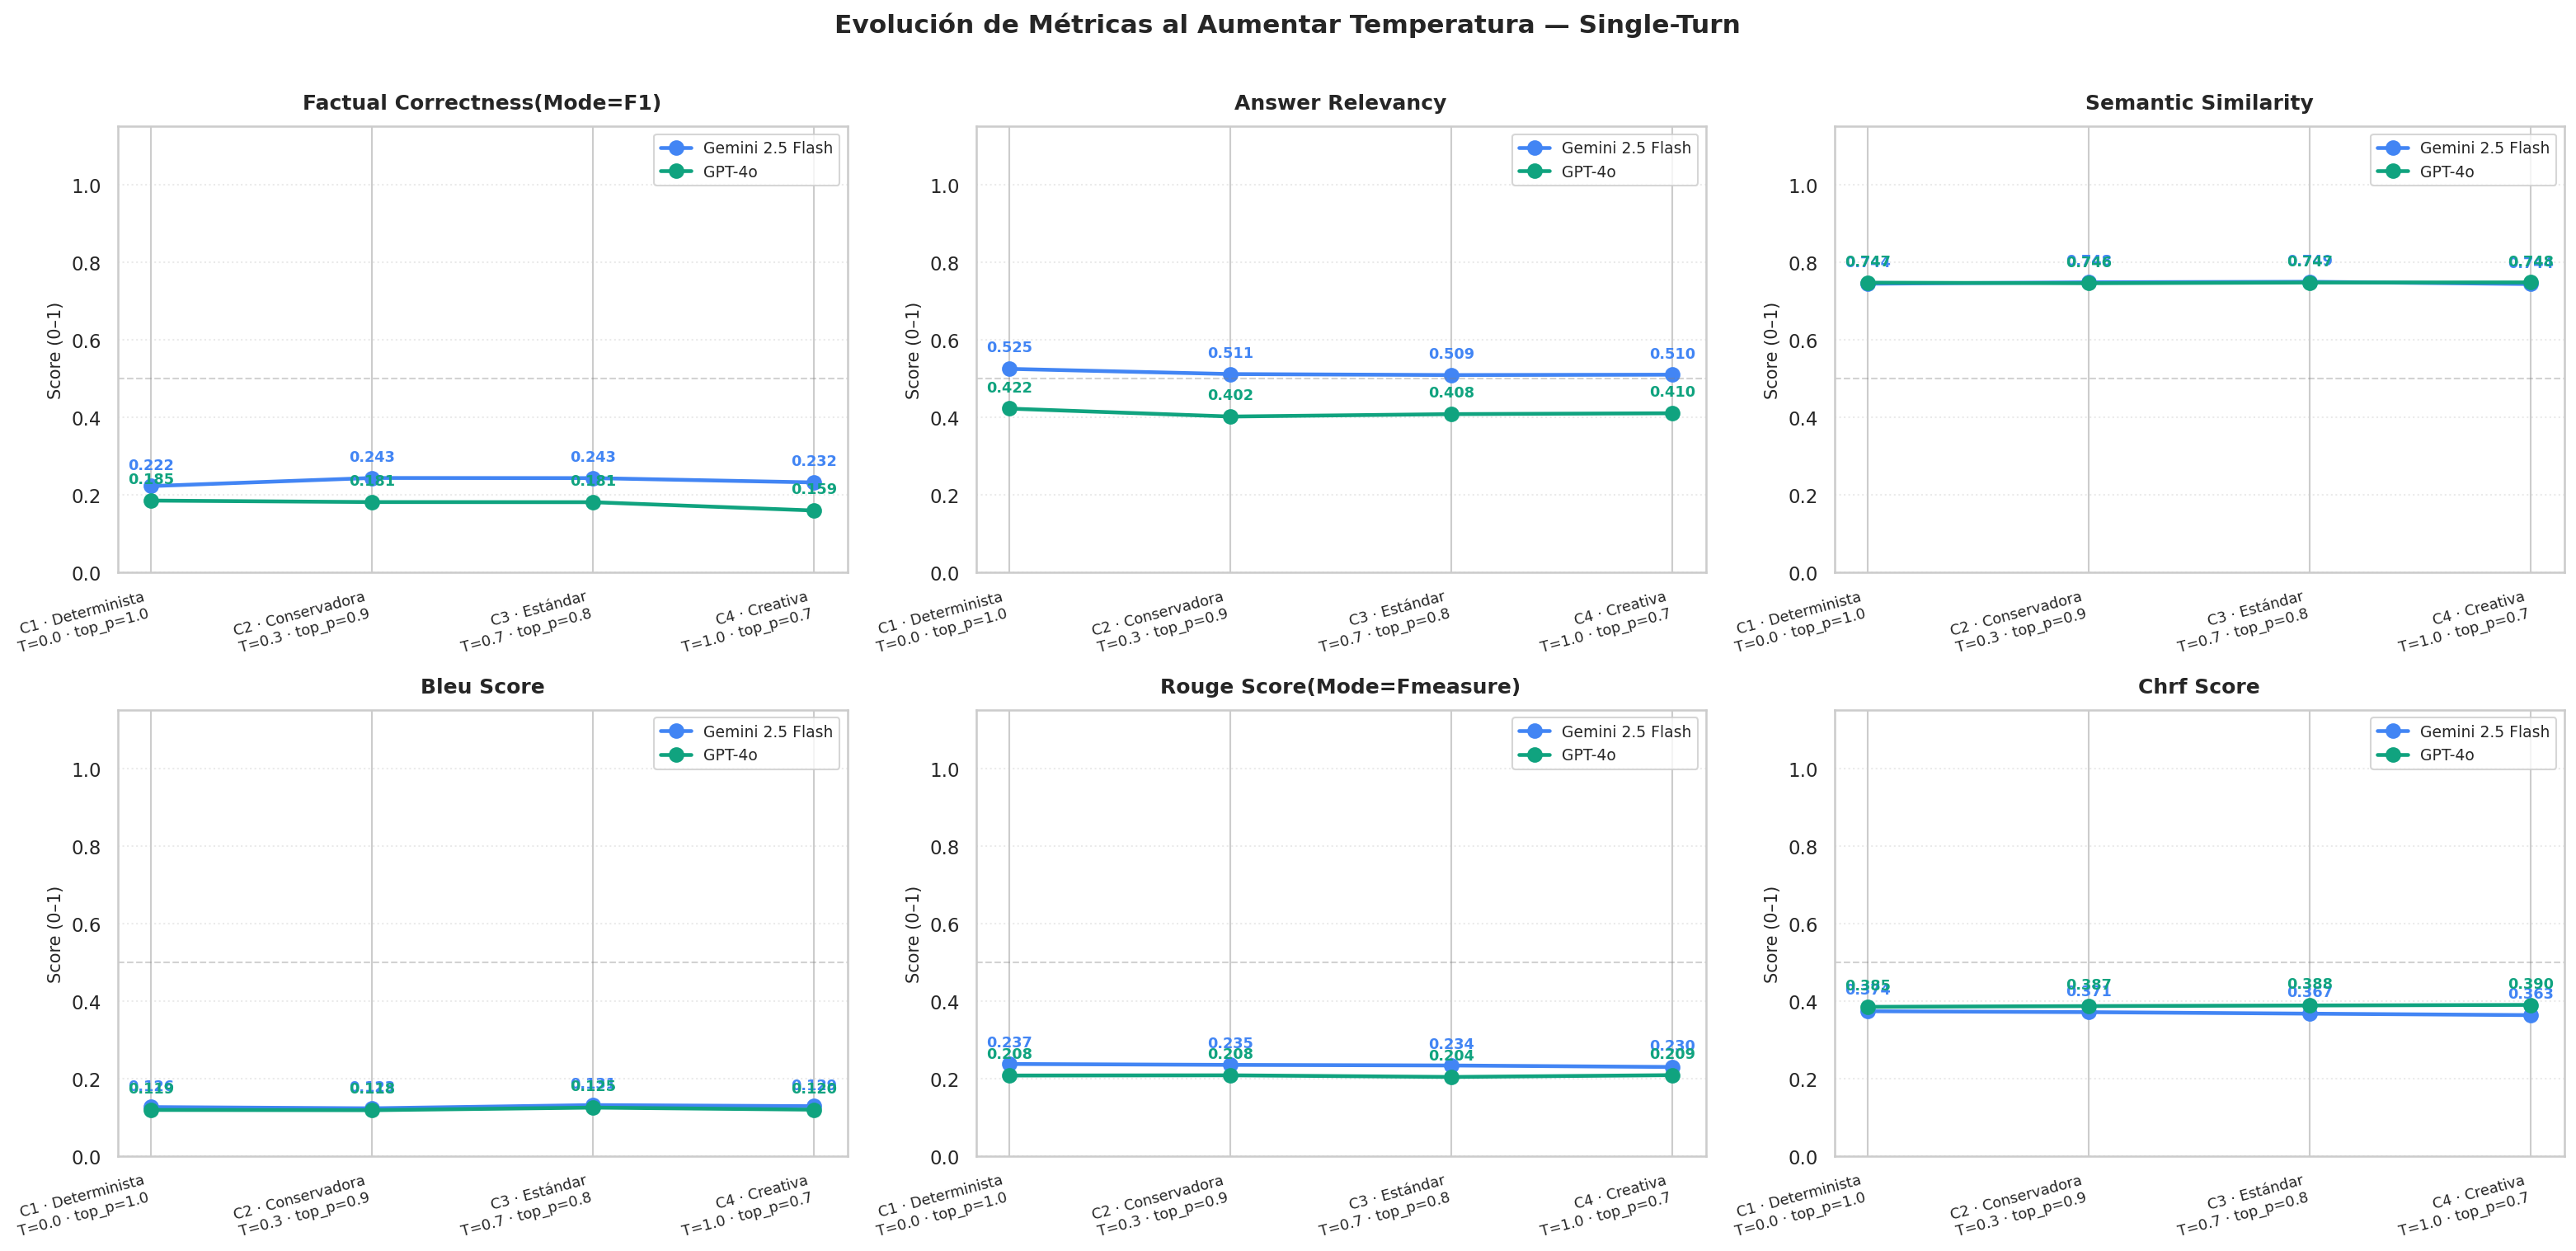

    fig04_temperatura_single_turn.png


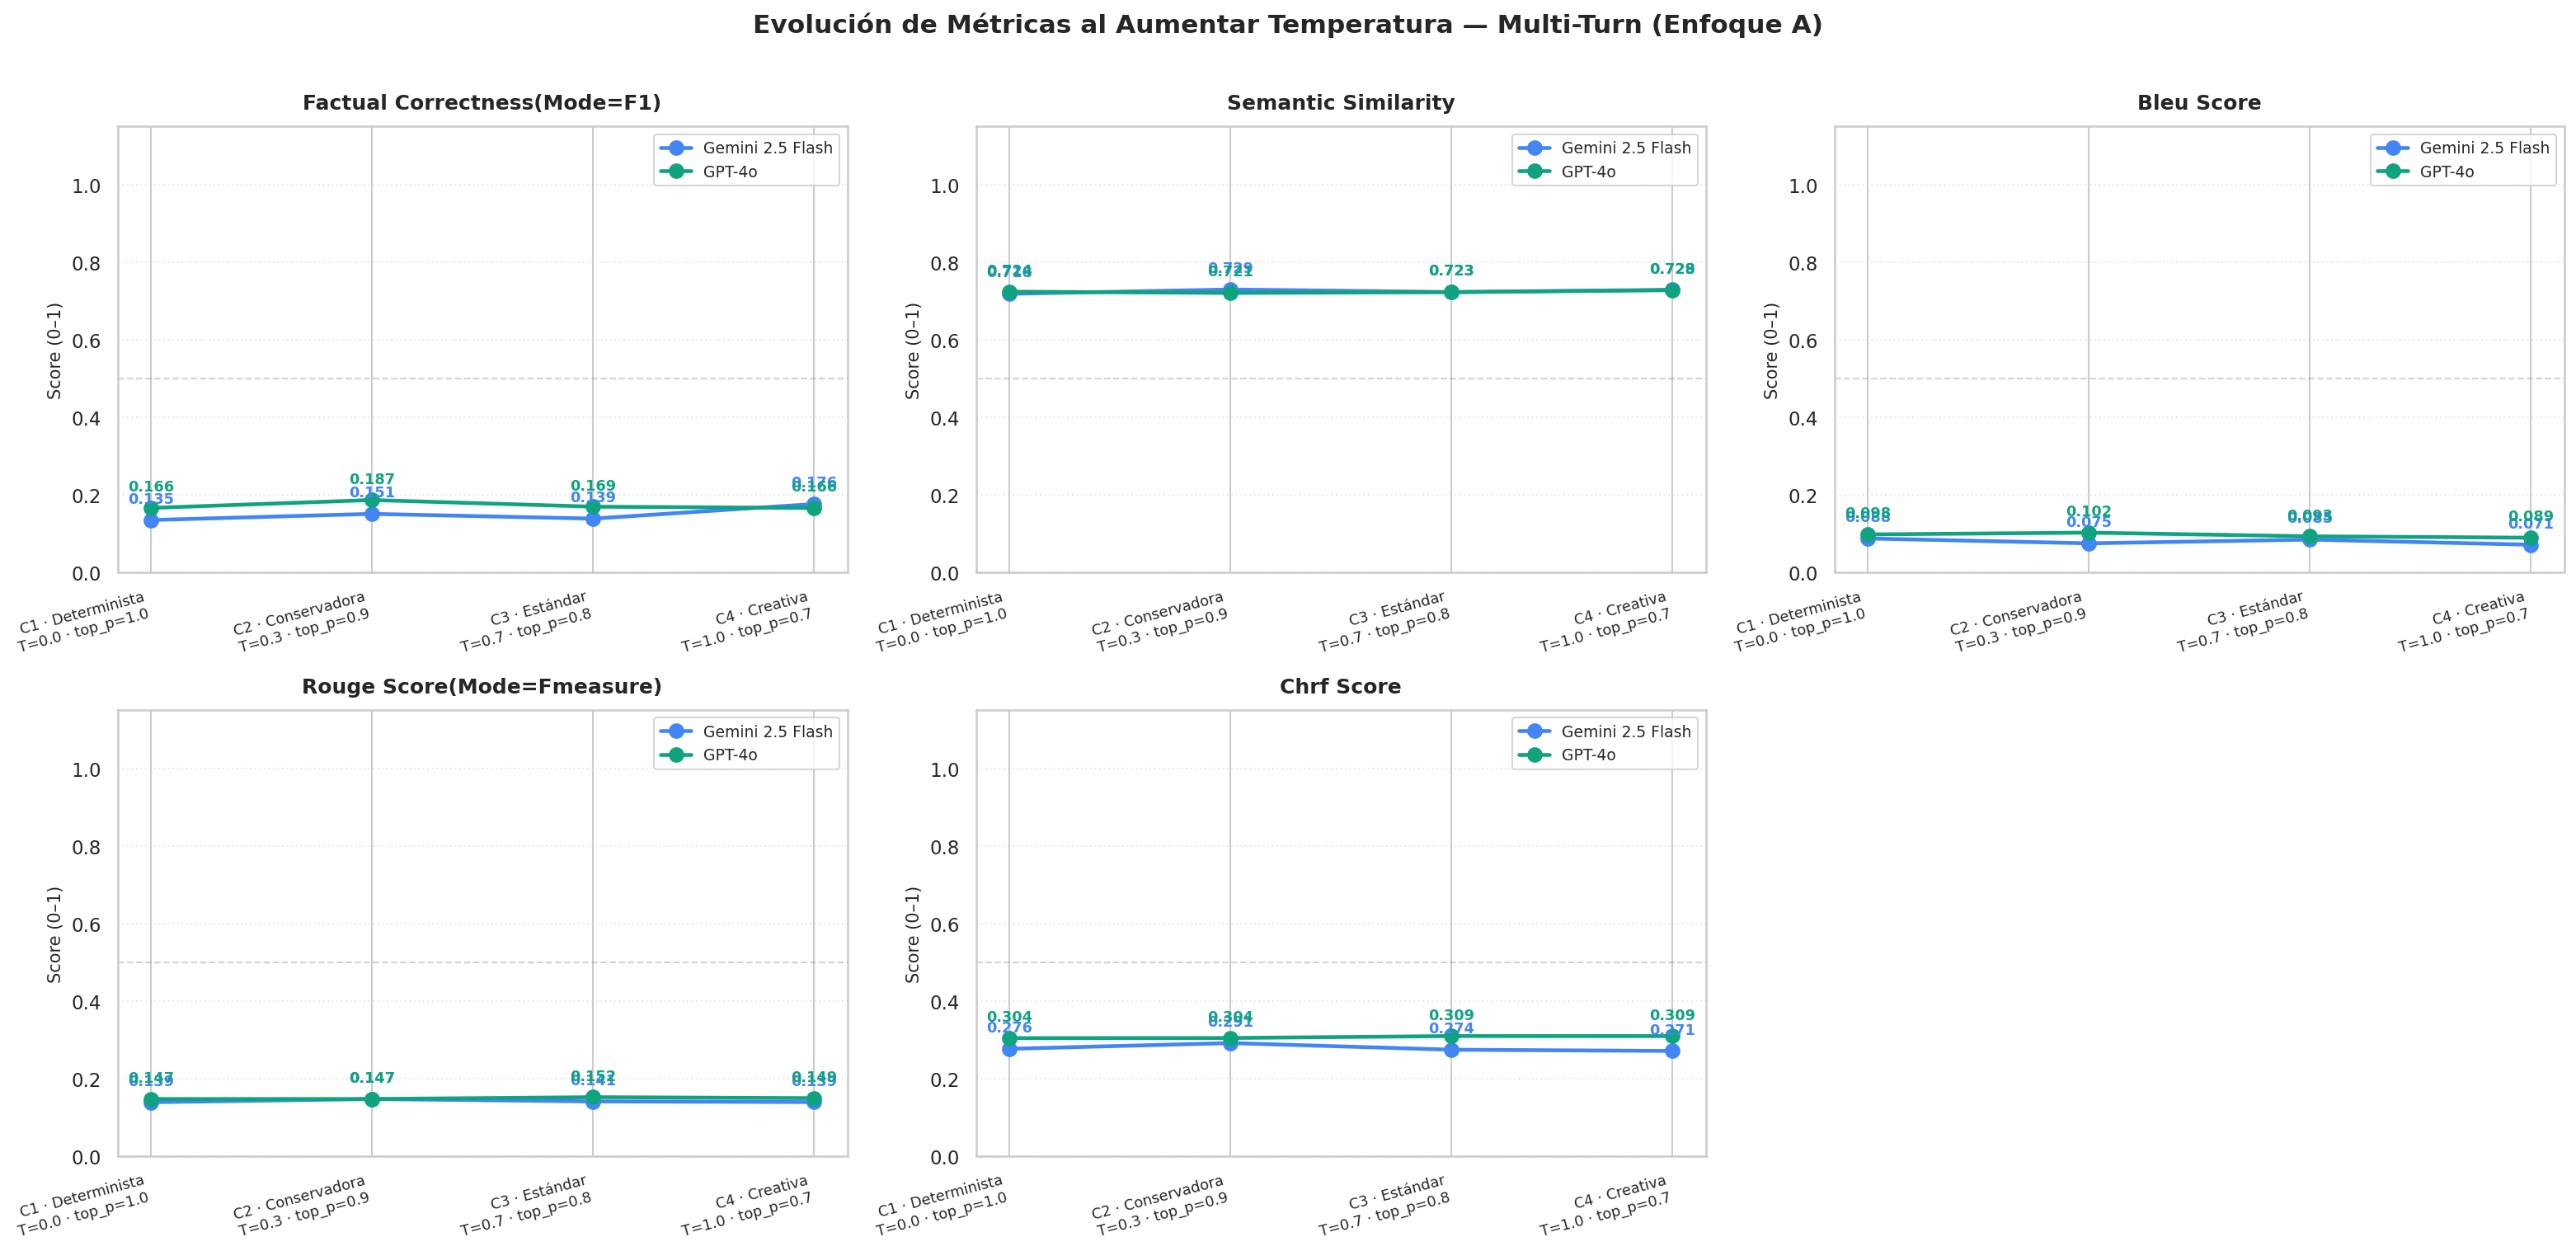

    fig05_temperatura_multi_turn_a.png


In [ ]:
def plot_temperature_evolution(scores_df: pd.DataFrame, title: str,
                                filename: str, output_dir: Path,
                                exclude_metrics: list = None):
    available = get_available_metrics(scores_df, GENERATION_METRICS)
    if exclude_metrics:
        available = [m for m in available if m not in exclude_metrics]
    if not available:
        print(f"Figura omitida '{title}': ninguna métrica disponible.")
        return

    agg   = scores_df.groupby(["model", "config_id"])[available].mean().reset_index()
    n     = len(available)
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(7 * ncols, 5 * nrows),
                             squeeze=False)
    axes_flat = axes.flatten()

    for ax, metric in zip(axes_flat, available):
        for model in agg["model"].unique():
            sub    = agg[agg["model"] == model].set_index("config_id")
            sub    = sub.reindex(CONFIG_ORDER).dropna(subset=[metric])
            xs     = range(len(sub))
            values = sub[metric].values
            color  = MODEL_COLORS.get(model, "#888")

            ax.plot(xs, values,
                    "o-", color=color,
                    label=MODEL_LABELS.get(model, model),
                    linewidth=2.2, markersize=8)

            # Valor exacto sobre cada punto
            for x, val in zip(xs, values):
                ax.annotate(
                    f"{val:.3f}",
                    xy=(x, val),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha="center", fontsize=8.5,
                    fontweight="bold", color=color,
                )

        ax.set_xticks(range(len(CONFIG_ORDER)))
        ax.set_xticklabels(
            [CONFIG_XLABELS.get(c, c) for c in CONFIG_ORDER],
            fontsize=8.5, rotation=15, ha="right"
        )
        ax.set_title(metric.replace("_", " ").title(),
                     fontsize=12, fontweight="bold", pad=10)
        ax.set_ylabel("Score (0–1)", fontsize=10)
        ax.set_ylim(0, 1.15)   # margen extra arriba para las anotaciones
        ax.legend(fontsize=9)
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)
        ax.grid(axis="y", linestyle=":", alpha=0.4)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    fig.tight_layout(h_pad=3.5, w_pad=2.5)
    save_fig(output_dir / filename)
plot_temperature_evolution(
    df_st_scores,
    "Evolución de Métricas al Aumentar Temperatura — Single-Turn",
    "fig04_temperatura_single_turn.png", PATH_EVAL)

plot_temperature_evolution(
    df_mt_a_scores,
    "Evolución de Métricas al Aumentar Temperatura — Multi-Turn (Enfoque A)",
    "fig05_temperatura_multi_turn_a.png", PATH_EVAL,
    exclude_metrics=["answer_relevancy"])

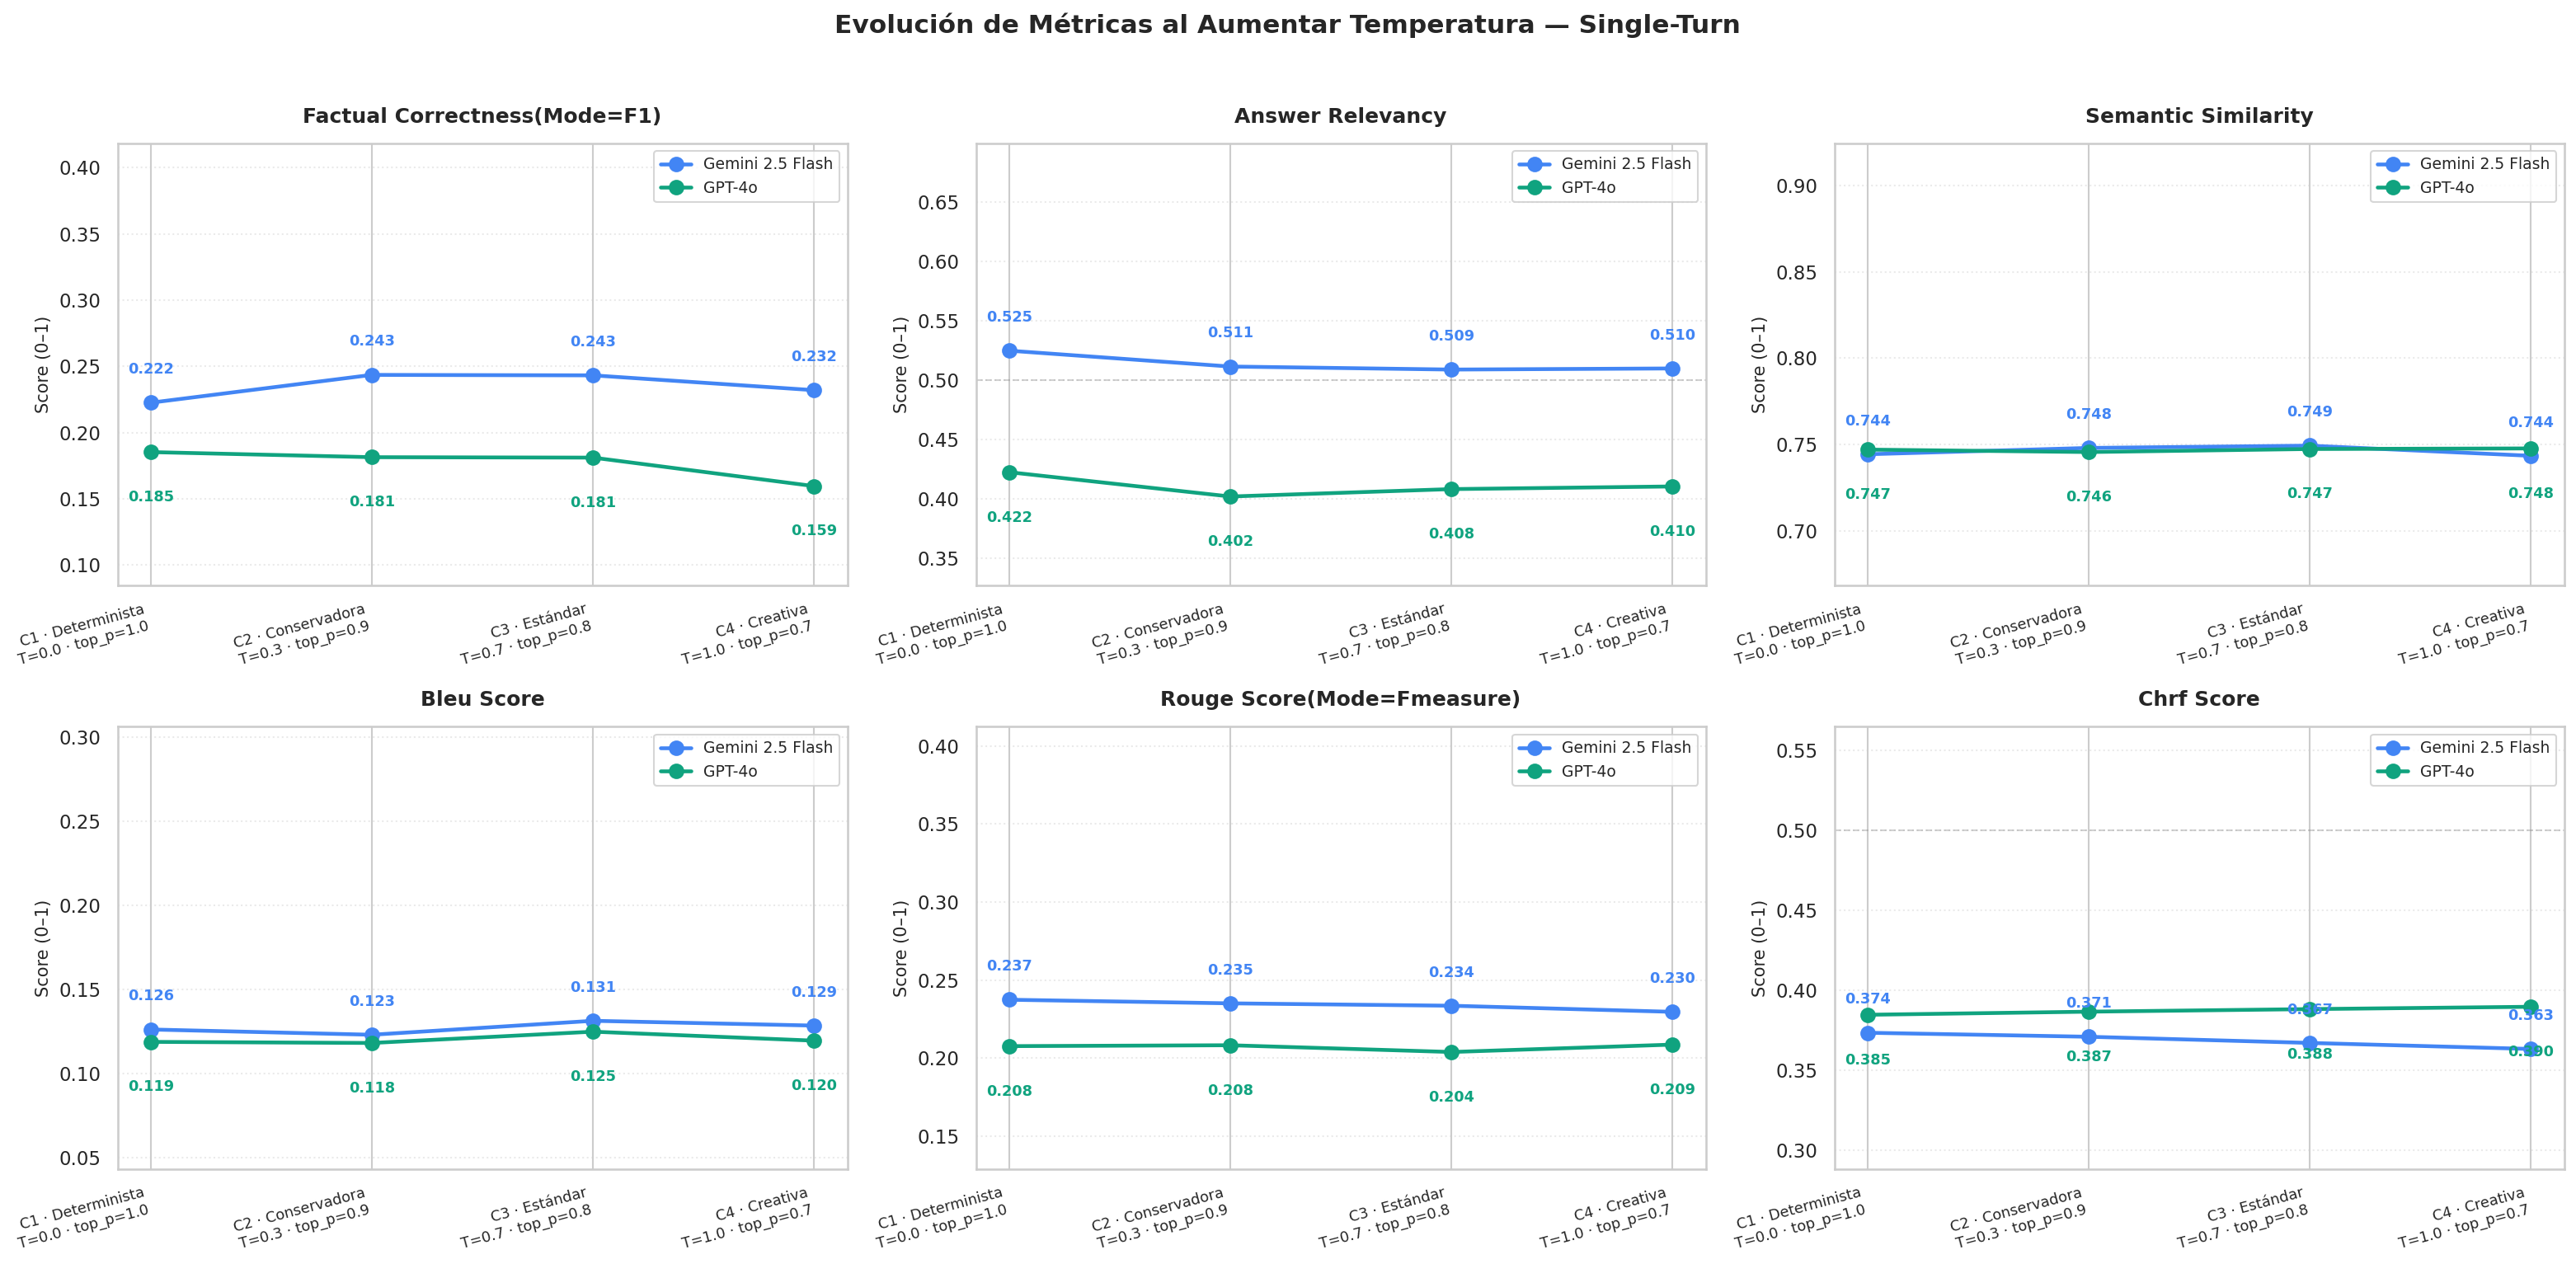

    fig04_temperatura_single_turn.png


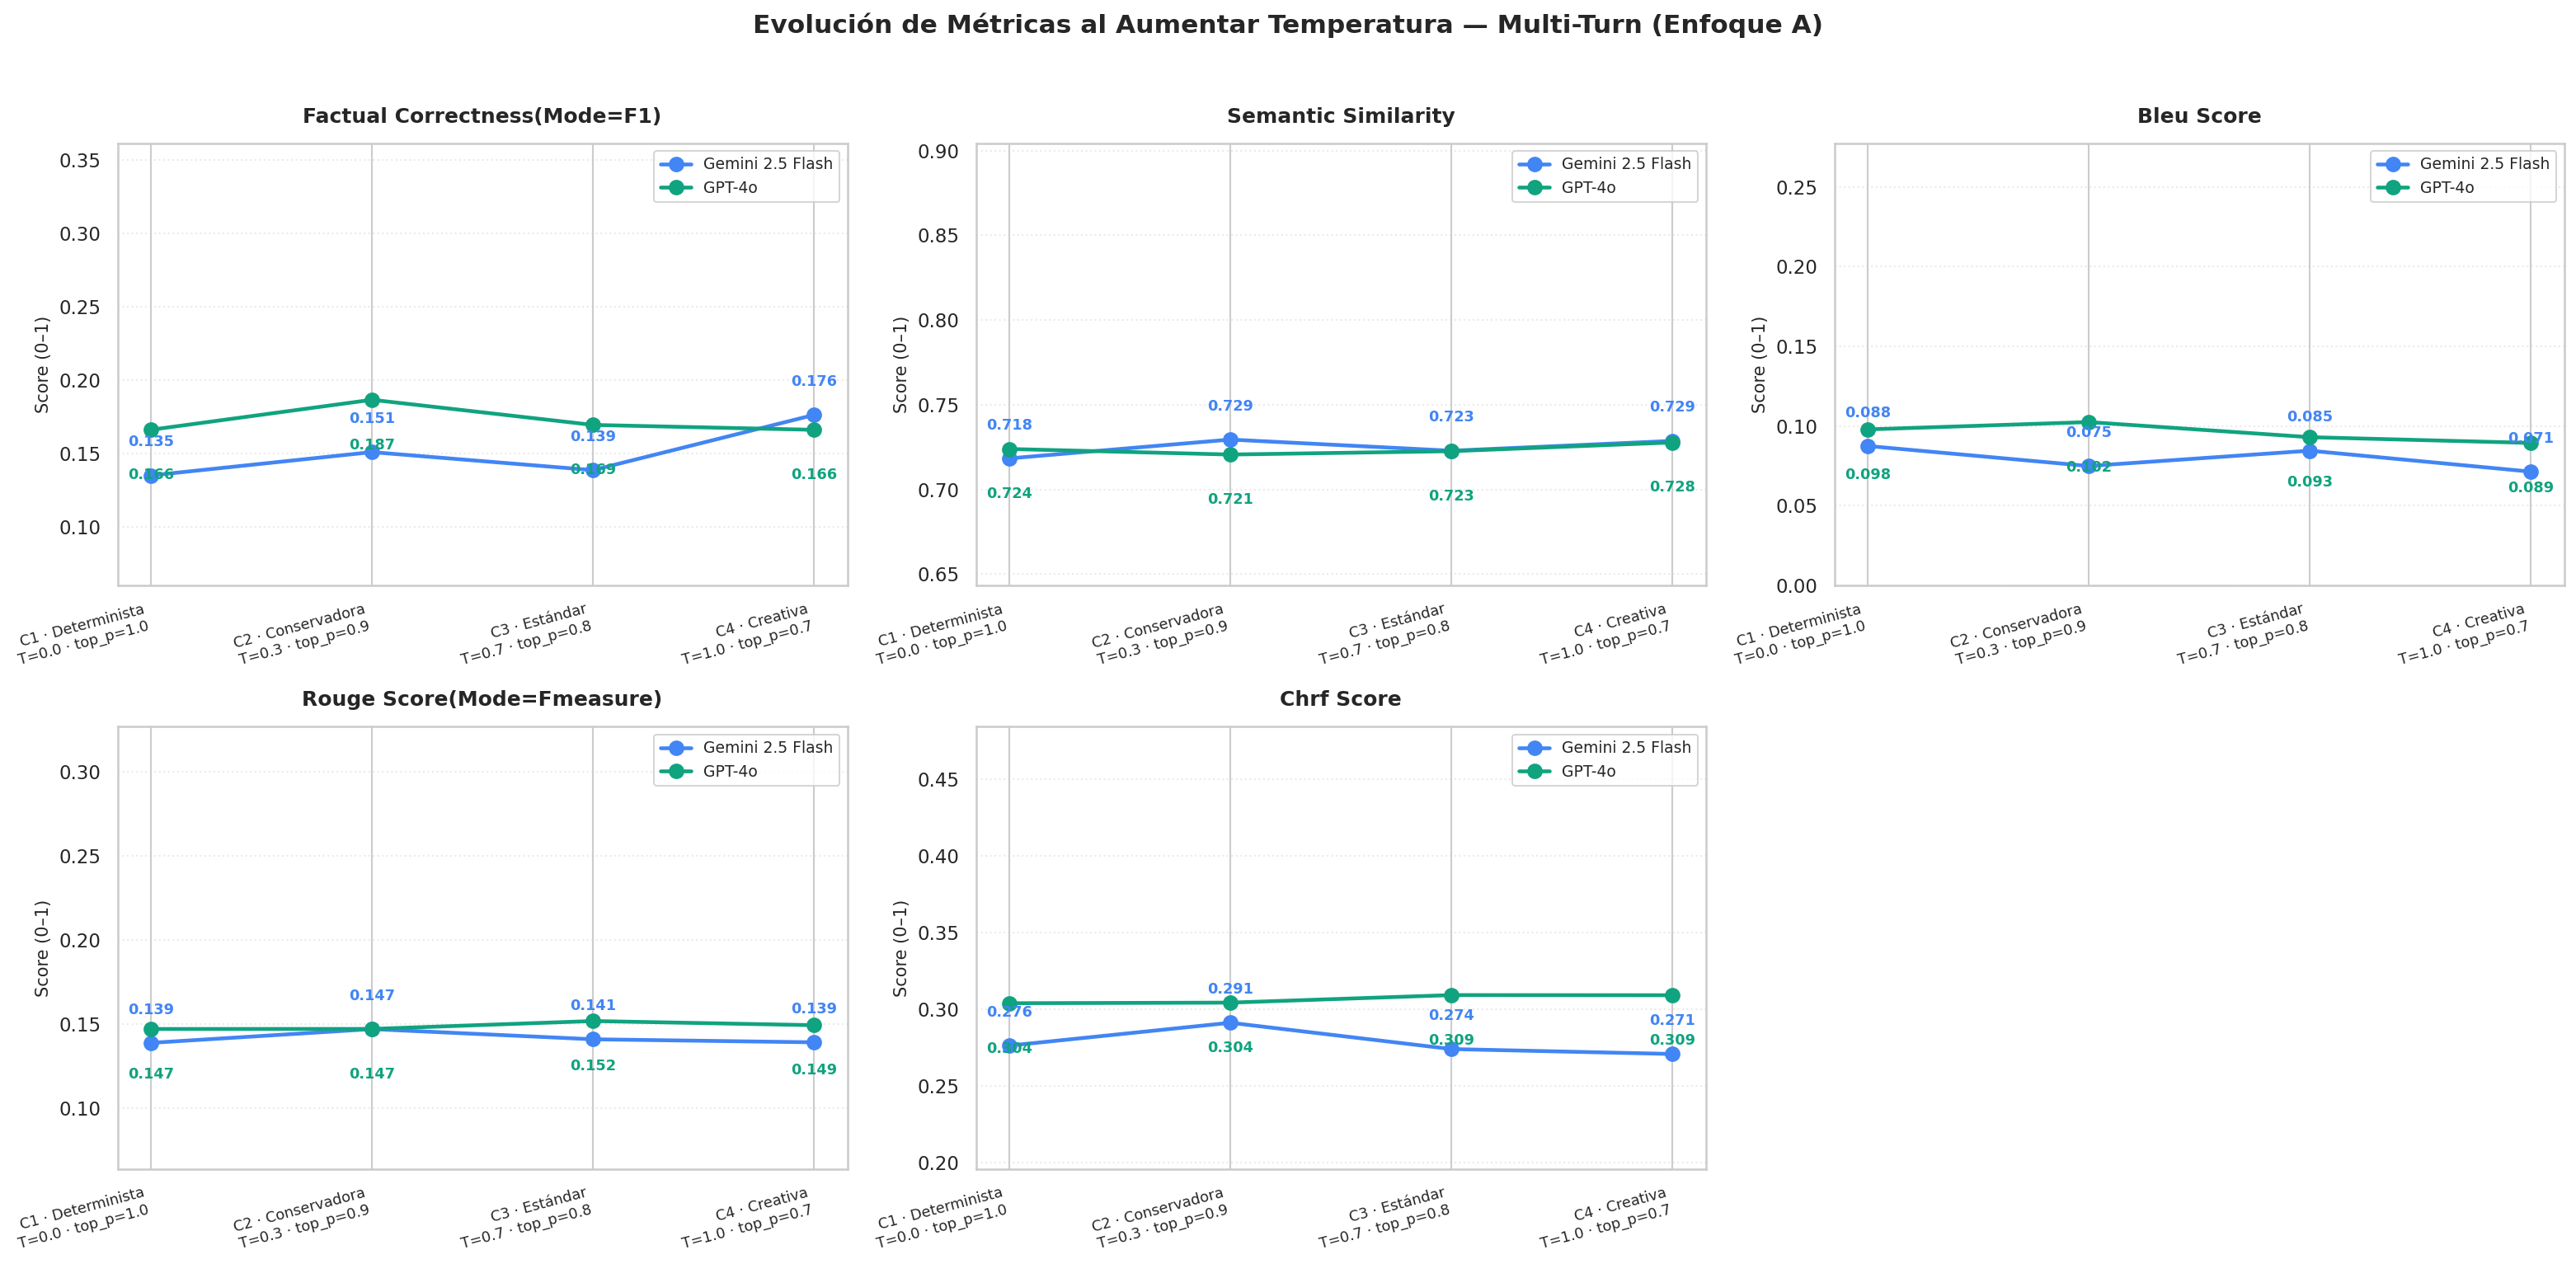

    fig05_temperatura_multi_turn_a.png


In [ ]:
def plot_temperature_evolution(scores_df: pd.DataFrame, title: str,
                                filename: str, output_dir: Path,
                                exclude_metrics: list = None):
    available = get_available_metrics(scores_df, GENERATION_METRICS)
    if exclude_metrics:
        available = [m for m in available if m not in exclude_metrics]
    if not available:
        print(f"Figura omitida '{title}': ninguna métrica disponible.")
        return

    agg   = scores_df.groupby(["model", "config_id"])[available].mean().reset_index()
    n     = len(available)
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(7 * ncols, 5 * nrows),
                             squeeze=False)
    axes_flat = axes.flatten()

    for ax, metric in zip(axes_flat, available):
        for i, model in enumerate(agg["model"].unique()):
            sub    = agg[agg["model"] == model].set_index("config_id")
            sub    = sub.reindex(CONFIG_ORDER).dropna(subset=[metric])
            xs     = range(len(sub))
            values = sub[metric].values
            color  = MODEL_COLORS.get(model, "#888")

            ax.plot(xs, values,
                    "o-", color=color,
                    label=MODEL_LABELS.get(model, model),
                    linewidth=2.2, markersize=8)

            # Modelos alternados: par → arriba, impar → abajo
            y_offset = 15 if i % 2 == 0 else -22
            va       = "bottom" if i % 2 == 0 else "top"

            for x, val in zip(xs, values):
                ax.annotate(
                    f"{val:.3f}",
                    xy=(x, val),
                    xytext=(0, y_offset),
                    textcoords="offset points",
                    ha="center", va=va,
                    fontsize=8.5, fontweight="bold", color=color,
                )

        ax.set_xticks(range(len(CONFIG_ORDER)))
        ax.set_xticklabels(
            [CONFIG_XLABELS.get(c, c) for c in CONFIG_ORDER],
            fontsize=8.5, rotation=15, ha="right"
        )

        # Zoom moderado: mínimo 0.15 de rango, sin salirse de [0, 1]
        all_vals = [
            v for model in agg["model"].unique()
            for v in agg[agg["model"] == model]
                       .set_index("config_id")
                       .reindex(CONFIG_ORDER)[metric]
                       .dropna().values
        ]
        if all_vals:
            lo   = min(all_vals)
            hi   = max(all_vals)
            span = max(hi - lo, 0.15)
            pad  = span * 0.5
            ymin = max(0.0, lo - pad)
            ymax = min(1.0, hi + pad) + 0.10
            ax.set_ylim(ymin, ymax)

        ax.set_title(metric.replace("_", " ").title(),
                     fontsize=12, fontweight="bold", pad=12)
        ax.set_ylabel("Score (0–1)", fontsize=10)
        ax.legend(fontsize=9)
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)
        ax.grid(axis="y", linestyle=":", alpha=0.4)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout(h_pad=4.0, w_pad=2.5, rect=[0, 0, 1, 0.97])
    save_fig(output_dir / filename)


plot_temperature_evolution(
    df_st_scores,
    "Evolución de Métricas al Aumentar Temperatura — Single-Turn",
    "fig04_temperatura_single_turn.png", PATH_EVAL)

plot_temperature_evolution(
    df_mt_a_scores,
    "Evolución de Métricas al Aumentar Temperatura — Multi-Turn (Enfoque A)",
    "fig05_temperatura_multi_turn_a.png", PATH_EVAL,
    exclude_metrics=["answer_relevancy"])


Explicación de la visualización:


Fig 06 — Radar: Perfil de Calidad Global Single-Turn
Qué muestra: Un gráfico de radar (también llamado gráfico de araña o spider chart) con una única figura circular donde:

Cada eje radial representa una métrica de generación (factual_correctness, answer_relevancy, semantic_similarity, bleu_score, rouge_score, chrf_score), distribuidas uniformemente alrededor del círculo
Cada polígono representa un modelo (GPT-4o en verde, Gemini en azul), siendo el valor en cada eje la media global de esa métrica colapsando las 4 configuraciones
El relleno semitransparente (alpha=0.15) permite ver la superposición entre ambos modelos
La escala radial va de 0 (centro) a 1 (borde exterior)
Qué se pretende ver: La "forma" del perfil de calidad de cada modelo de un solo vistazo. Permite detectar en qué dimensiones un modelo supera al otro y si alguno tiene un perfil equilibrado o desequilibrado:

Si un polígono es más grande en todas las dimensiones → ese modelo es globalmente mejor
Si los polígonos tienen formas distintas → cada modelo tiene fortalezas en métricas diferentes (por ejemplo, uno puede tener mejor factual_correctness pero peor bleu_score)
Un eje radial muy corto en ambos modelos → esa métrica es generalmente baja para todos, lo que en el contexto del TFG señala las dimensiones donde los LLMs sin contexto fallan sistemáticamente
Un matiz importante: Al colapsar las 4 configuraciones en una sola media por modelo, esta figura muestra el perfil de calidad medio independientemente de la temperatura. Es una imagen de "quién es cada modelo" globalmente, no de cómo varía con los parámetros.

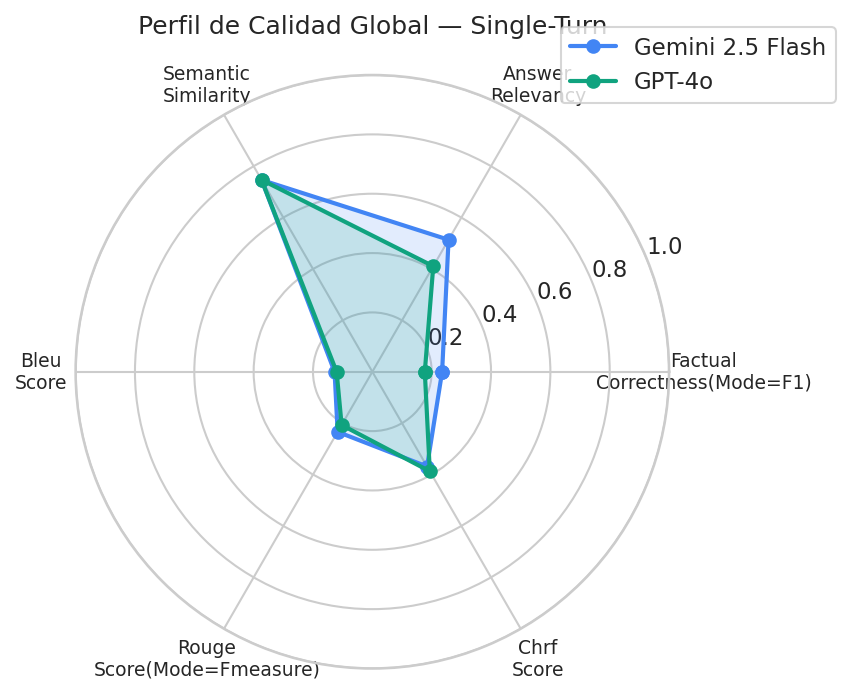

    fig06_radar_single_turn.png


In [ ]:

# ──────────────────────────────────────────────────────────────
# CELDA 3.4 · Fig 06 — Radar perfil de calidad (single-turn)
# ──────────────────────────────────────────────────────────────
# %%

def plot_radar(scores_df: pd.DataFrame, title: str,
               filename: str, output_dir: Path):
    available = get_available_metrics(scores_df, GENERATION_METRICS)
    if len(available) < 3:
        return
    agg    = scores_df.groupby("model")[available].mean()
    labels = [m.replace("_", "\n").title() for m in available]
    N      = len(available)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
    for model in agg.index:
        vals  = agg.loc[model, available].tolist() + [agg.loc[model, available[0]]]
        color = MODEL_COLORS.get(model, "#888")
        ax.plot(angles, vals, "o-", linewidth=2, color=color,
                label=MODEL_LABELS.get(model, model))
        ax.fill(angles, vals, alpha=0.15, color=color)
    ax.set_thetagrids([a * 180 / np.pi for a in angles[:-1]], labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(title, pad=20, fontsize=12)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    save_fig(output_dir / filename)


plot_radar(df_st_scores,
           "Perfil de Calidad Global — Single-Turn",
           "fig06_radar_single_turn.png", PATH_EVAL)

In [ ]:
print("Columnas:", df_st_scores.columns.tolist())
print("Categorías reales:", df_st_scores["category"].unique())


Columnas: ['user_input', 'response', 'reference', 'factual_correctness(mode=f1)', 'answer_relevancy', 'semantic_similarity', 'bleu_score', 'rouge_score(mode=fmeasure)', 'chrf_score', 'model', 'config_id', 'eval_type', 'category', 'doc_name', 'question_id', 'answer_relevancy_valid']
Categorías reales: ['factual_true' 'factual_reasoning' 'factual_trap' 'out_of_domain']


Explicación de la visualización:

Fig 07 — Factual Correctness por Categoría de Pregunta (Single-Turn)
Qué muestra: Un gráfico de barras agrupadas donde:

Eje X: las 4 categorías de pregunta (factual_true, factual_reasoning, factual_trap, out_of_domain)
Eje Y: media de factual_correctness (0–1) para ese modelo en esa categoría
Dos barras por categoría, una por modelo (GPT-4o en verde, Gemini en azul), colocadas una al lado de la otra
Escala fija 0–1 para mantener comparabilidad entre categorías
Qué se pretende ver: Si el modelo discrimina correctamente entre tipos de pregunta según su dificultad esperada. El patrón ideal que validaría el diseño del golden dataset sería:

Categoría	Comportamiento esperado
factual_true	Barras relativamente altas — preguntas directas que el modelo puede conocer
factual_reasoning	Barras medias-altas — requieren inferencia pero son respondibles
factual_trap	Barras bajas — diseñadas para provocar alucinación
out_of_domain	Barras bajas — el modelo no tiene esa información en sus pesos
Si factual_trap y out_of_domain tienen valores claramente por debajo de factual_true, eso confirma que el dataset es discriminativo y que los modelos sí alucinan más ante preguntas para las que no tienen respuesta correcta.

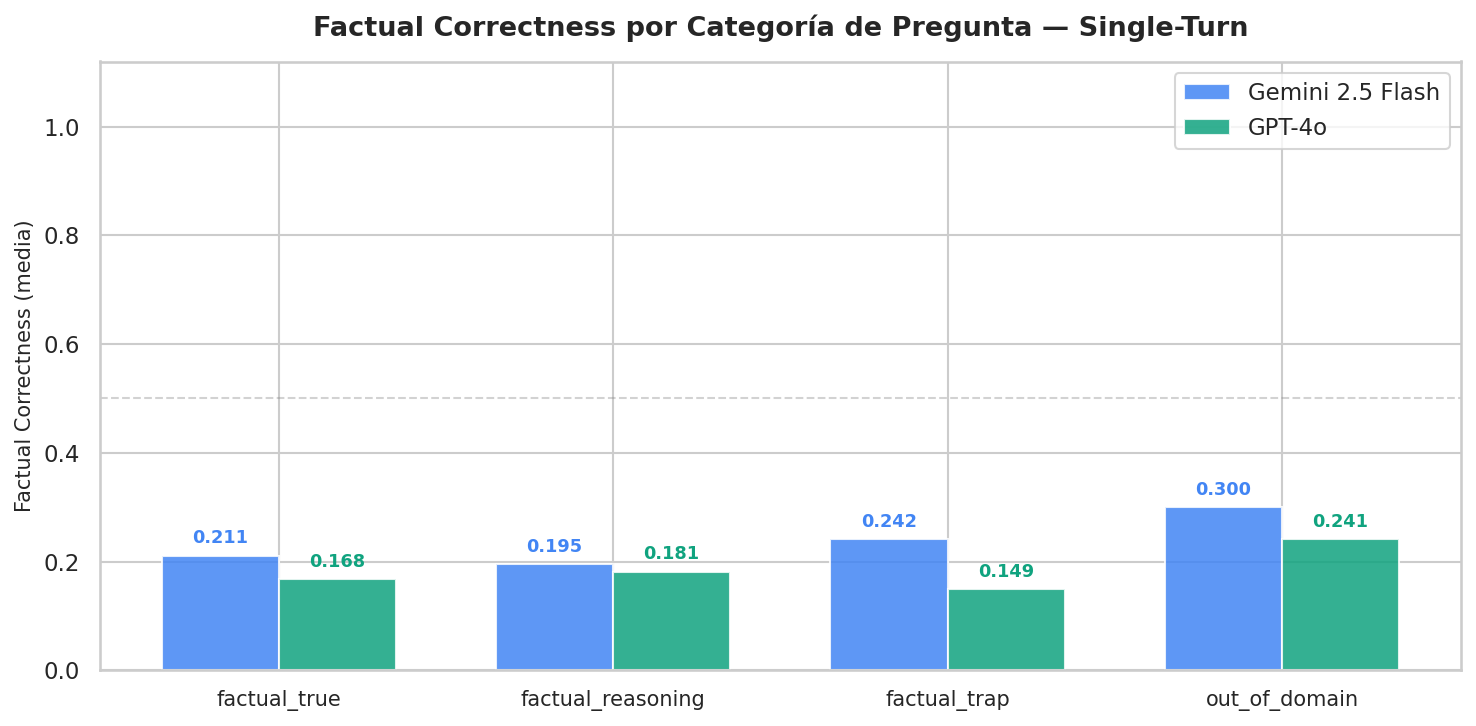

    fig07_por_categoria.png


In [ ]:

# ──────────────────────────────────────────────────────────────
# CELDA 3.5 · Fig 07 — Por categoría de pregunta (single-turn)
# ──────────────────────────────────────────────────────────────
# %%

def plot_by_category(scores_df: pd.DataFrame, output_dir: Path):
    metric = "factual_correctness(mode=f1)"
    if metric not in scores_df.columns or "category" not in scores_df.columns:
        print(f"Figura omitida: columna '{metric}' o 'category' no disponible.")
        return
    cats = ["factual_true", "factual_reasoning", "factual_trap", "out_of_domain"]
    cats = [c for c in cats if c in scores_df["category"].unique()]
    if not cats:
        return

    agg   = scores_df.groupby(["model", "category"])[metric].mean().reset_index()
    x     = np.arange(len(cats))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, model in enumerate(agg["model"].unique()):
        vals = []
        for c in cats:
            sub = agg[(agg["model"] == model) & (agg["category"] == c)][metric]
            vals.append(sub.values[0] if len(sub) > 0 else 0)

        offset = (i - len(agg["model"].unique()) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width,
                      color=MODEL_COLORS.get(model, "#888"),
                      label=MODEL_LABELS.get(model, model), alpha=0.85)

        # Valor exacto encima de cada barra
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{val:.3f}",
                ha="center", va="bottom",
                fontsize=8.5, fontweight="bold",
                color=MODEL_COLORS.get(model, "#888"),
            )

    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=10)
    ax.set_ylabel("Factual Correctness (media)")
    ax.set_title("Factual Correctness por Categoría de Pregunta — Single-Turn",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_ylim(0, 1.12)   # margen para que las etiquetas no queden cortadas
    ax.legend()
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)
    save_fig(output_dir / "fig07_por_categoria.png")


plot_by_category(df_st_scores, PATH_EVAL)


Explicación de la visualización:


Fig 08 — Factual Correctness por Patrón Conversacional (Multi-Turn Enfoque A)
Qué muestra: Un gráfico de barras agrupadas estructuralmente idéntico a Fig 07, pero sobre df_mt_a_scores y con el eje X organizado por patrones conversacionales en lugar de categorías de pregunta:

Patrón	Demanda cognitiva
expansion	Consistencia interna — el modelo amplía información dada anteriormente
refinement	Autocorrección — el usuario corrige o matiza una respuesta previa
follow-up	Coherencia local — preguntas encadenadas sobre el mismo tema
recollection	Memoria lejana — recuperar algo mencionado varios turnos atrás
Qué se pretende ver: Qué tipo de dinámica conversacional provoca más alucinaciones. La hipótesis del TFG es que los patrones con mayor demanda de memoria (recollection) y de corrección sobre respuestas previas (refinement) deberían mostrar los valores más bajos de factual_correctness, porque el modelo tiene que mantener coherencia con lo que dijo antes sin tener esa información en el contexto (al no usar RAG).

En cambio, follow-up debería ser el patrón más benévolo porque las preguntas son localmente coherentes y el historial reciente ayuda más que perjudica.

Diferencia clave respecto a Fig 07: Fig 07 pregunta "¿sobre qué tipo de pregunta falla el modelo?", mientras que Fig 08 pregunta "¿en qué tipo de conversación falla el modelo?". Son dos dimensiones ortogonales del análisis: una mide la dificultad del contenido, la otra mide la dificultad de la dinámica conversacional. Juntas construyen el argumento central del TFG de que los LLMs sin contexto degradan su calidad factual tanto por el tipo de pregunta como por la estructura de la conversación.

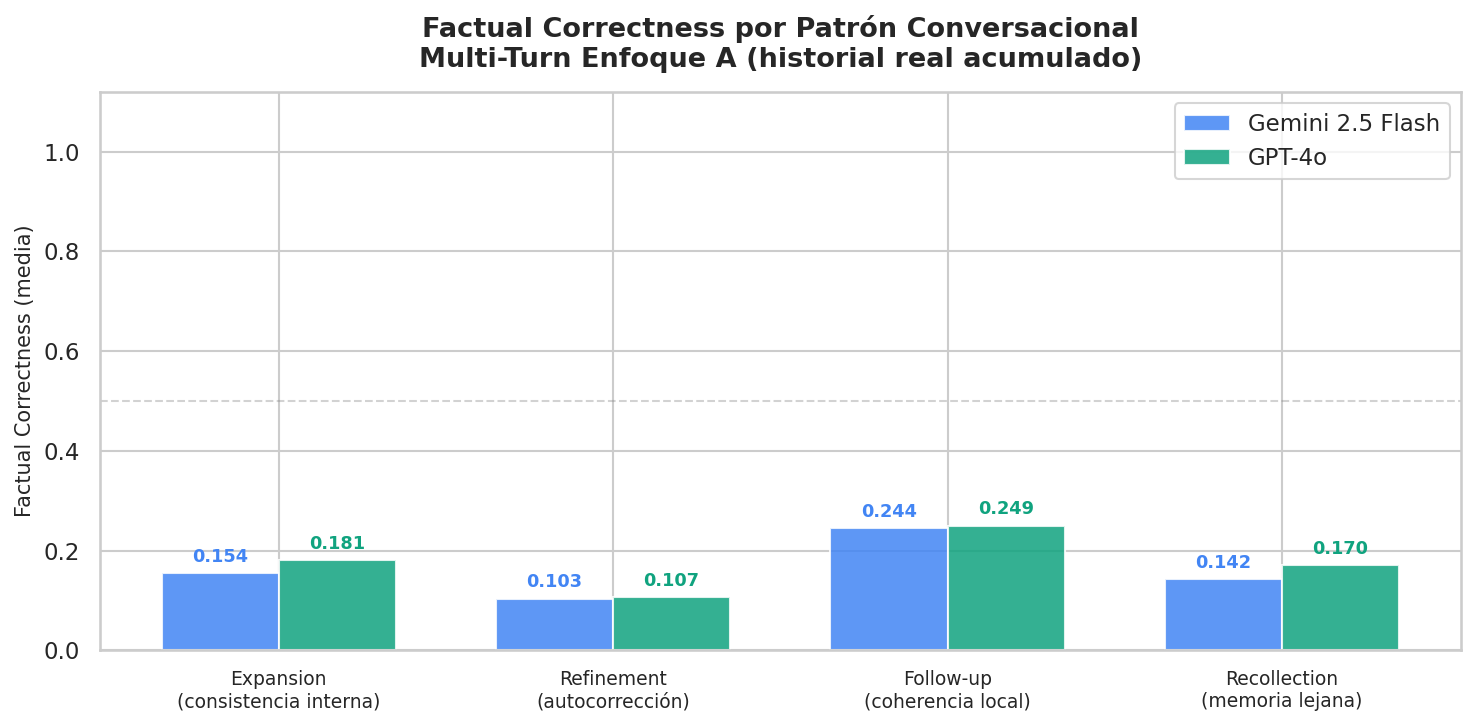

    fig08_por_patron.png


In [ ]:
# ──────────────────────────────────────────────────────────────
# CELDA 3.6 · Fig 08 — Por patrón conversacional (multi-turn A)
# ──────────────────────────────────────────────────────────────
# %%


def plot_by_pattern(scores_df: pd.DataFrame, output_dir: Path):
    metric = "factual_correctness(mode=f1)"
    if metric not in scores_df.columns or "pattern" not in scores_df.columns:
        print(f"Figura omitida: columna '{metric}' o 'pattern' no disponible.")
        return

    pattern_labels = {
        "expansion":    "Expansion\n(consistencia interna)",
        "refinement":   "Refinement\n(autocorrección)",
        "follow-up":    "Follow-up\n(coherencia local)",
        "recollection": "Recollection\n(memoria lejana)",
    }
    patterns = [p for p in pattern_labels if p in scores_df["pattern"].unique()]
    if not patterns:
        return

    agg   = scores_df.groupby(["model", "pattern"])[metric].mean().reset_index()
    x     = np.arange(len(patterns))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, model in enumerate(agg["model"].unique()):
        vals = []
        for p in patterns:
            sub = agg[(agg["model"] == model) & (agg["pattern"] == p)][metric]
            vals.append(sub.values[0] if len(sub) > 0 else 0)

        offset = (i - len(agg["model"].unique()) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width,
                      color=MODEL_COLORS.get(model, "#888"),
                      label=MODEL_LABELS.get(model, model), alpha=0.85)

        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{val:.3f}",
                ha="center", va="bottom",
                fontsize=8.5, fontweight="bold",
                color=MODEL_COLORS.get(model, "#888"),
            )

    ax.set_xticks(x)
    ax.set_xticklabels([pattern_labels.get(p, p) for p in patterns], fontsize=9)
    ax.set_ylabel("Factual Correctness (media)")
    ax.set_title("Factual Correctness por Patrón Conversacional\n"
                 "Multi-Turn Enfoque A (historial real acumulado)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_ylim(0, 1.12)
    ax.legend()
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.35, linewidth=1)
    save_fig(output_dir / "fig08_por_patron.png")


plot_by_pattern(df_mt_a_scores, PATH_EVAL)


Fig Extra 1 — Evolución de FC por turno conversacional
Qué muestra: Una línea por modelo donde el eje X es el número de turno (1, 2, 3...) y el eje Y es la media de factual_correctness en ese turno, con una banda semitransparente de ±1 desviación estándar.

Por qué es la más importante: Es la única figura que muestra el mecanismo temporal de las alucinaciones. Si la línea desciende de turno en turno, demuestra que los errores se propagan y acumulan: el modelo usa sus respuestas anteriores (incorrectas) como base para las siguientes. Eso convierte un argumento de correlación en uno de causalidad temporal, que es mucho más sólido para el TFG.


Limitamos a los 4 primeros turnos para garantizar comparabilidad entre patrones.
Expansion, follow-up y refinement tienen 4 turnos; recollection tiene 5, pero su turno 1 es de tipo instrucción (excluido de métricas), dejando también 4 evaluables. Incluir el turno 5 sesgaría la media al calcularse solo sobre conversaciones recollection.


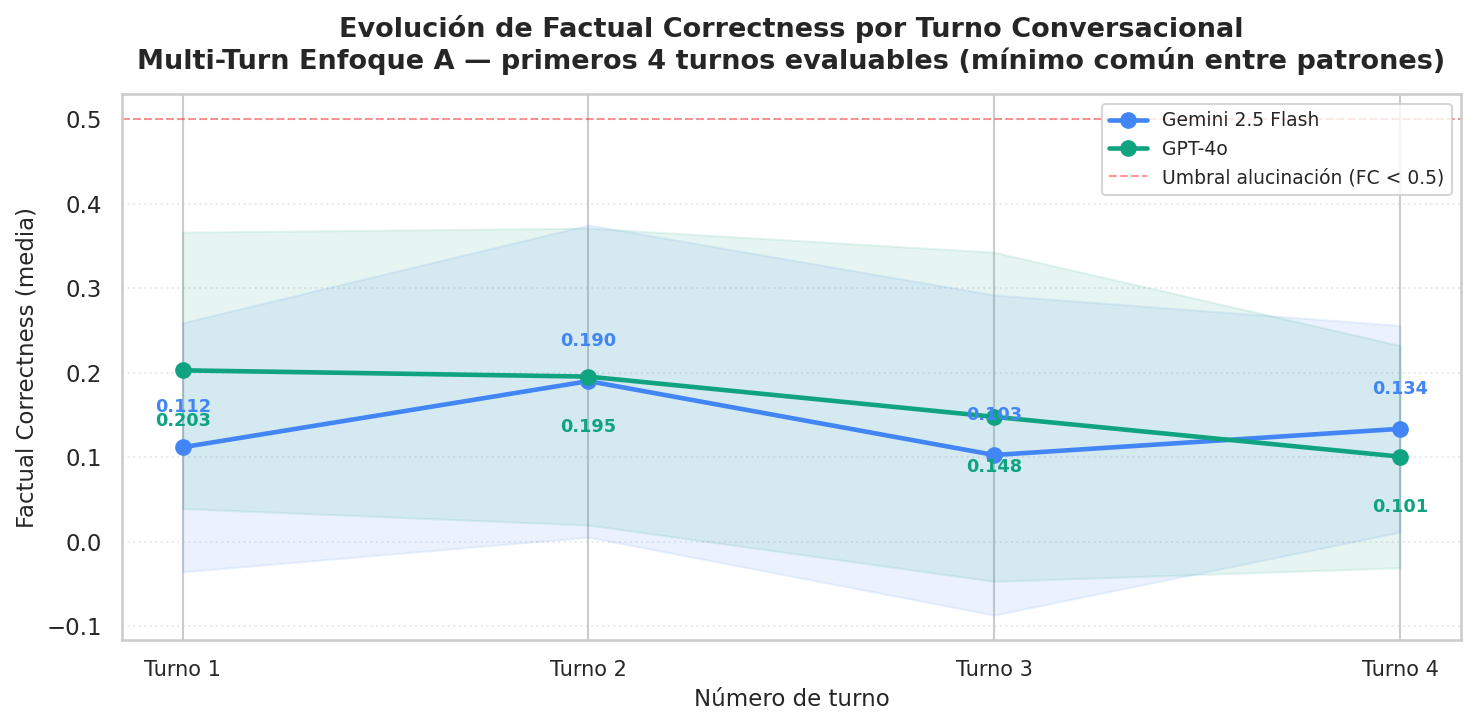

    fig_extra1_fc_por_turno.png


In [ ]:
def plot_fc_by_turn(df_mt: pd.DataFrame, output_dir: Path):
    metric = "factual_correctness(mode=f1)"
    if metric not in df_mt.columns or "turn_number" not in df_mt.columns:
        print("Figura omitida: columnas necesarias no disponibles.")
        return

    # Limitar al mínimo común de turnos evaluables entre patrones
    MAX_TURN = 4
    df_plot  = df_mt[df_mt["turn_number"] <= MAX_TURN].copy()

    agg = (df_plot.groupby(["model", "turn_number"])[metric]
                  .agg(["mean", "std"])
                  .reset_index())

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, model in enumerate(agg["model"].unique()):
        sub   = agg[agg["model"] == model].sort_values("turn_number")
        color = MODEL_COLORS.get(model, "#888")

        ax.plot(sub["turn_number"], sub["mean"], "o-",
                color=color, linewidth=2.2, markersize=7,
                label=MODEL_LABELS.get(model, model))

        ax.fill_between(sub["turn_number"],
                        sub["mean"] - sub["std"],
                        sub["mean"] + sub["std"],
                        color=color, alpha=0.1)

        y_offset = 15 if i % 2 == 0 else -20
        va       = "bottom" if i % 2 == 0 else "top"
        for _, row in sub.iterrows():
            ax.annotate(f"{row['mean']:.3f}",
                        xy=(row["turn_number"], row["mean"]),
                        xytext=(0, y_offset), textcoords="offset points",
                        ha="center", va=va,
                        fontsize=8.5, fontweight="bold", color=color)

    ax.set_xlabel("Número de turno", fontsize=11)
    ax.set_ylabel("Factual Correctness (media)", fontsize=11)
    ax.set_title("Evolución de Factual Correctness por Turno Conversacional\n"
                 "Multi-Turn Enfoque A — primeros 4 turnos evaluables (mínimo común entre patrones)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4,
               linewidth=1, label="Umbral alucinación (FC < 0.5)")
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Turno 1", "Turno 2", "Turno 3", "Turno 4"], fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    fig.tight_layout()
    save_fig(output_dir / "fig_extra1_fc_por_turno.png")


plot_fc_by_turn(df_mt_a_scores, PATH_EVAL)


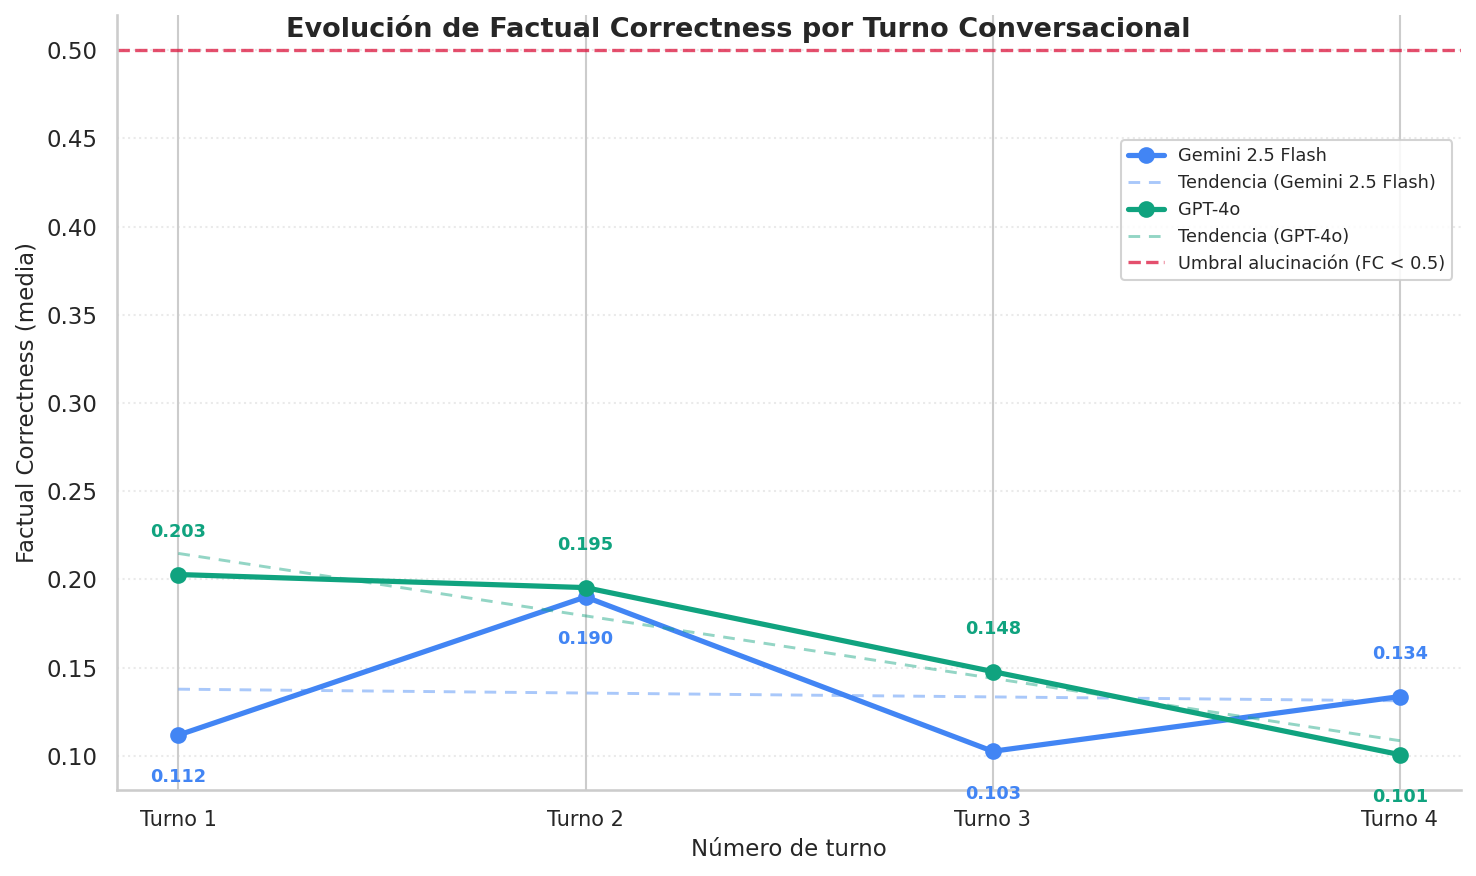

    fig_extra1_fc_por_turno.png


In [ ]:
def plot_fc_by_turn(df_mt: pd.DataFrame, output_dir: Path):
    import numpy as np

    metric = "factual_correctness(mode=f1)"
    if metric not in df_mt.columns or "turn_number" not in df_mt.columns:
        print("Figura omitida: columnas necesarias no disponibles.")
        return

    MAX_TURN = 4
    df_plot  = df_mt[df_mt["turn_number"] <= MAX_TURN].copy()

    agg = (df_plot.groupby(["model", "turn_number"])[metric]
                  .agg(["mean", "std"])
                  .reset_index())

    turn_means = (agg.groupby("turn_number")
                     .apply(lambda g: dict(zip(g["model"], g["mean"])))
                     .to_dict())

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.subplots_adjust(top=0.78)

    # Título y nota metodológica sobre el área del gráfico
    fig.text(0.5, 0.97,
             "Evolución de Factual Correctness por Turno Conversacional",
             ha="center", va="top", fontsize=13, fontweight="bold")

    x_fine = np.linspace(1, MAX_TURN, 200)

    for model in agg["model"].unique():
        sub   = agg[agg["model"] == model].sort_values("turn_number")
        color = MODEL_COLORS.get(model, "#888")
        xs, ys = sub["turn_number"].values, sub["mean"].values

        # Línea principal sólida y gruesa
        ax.plot(xs, ys, "o-",
                color=color, linewidth=2.5, markersize=7,
                label=MODEL_LABELS.get(model, model))

        # Banda ±std
        # ax.fill_between(xs,
        #                 sub["mean"] - sub["std"],
        #                 sub["mean"] + sub["std"],
        #                 color=color, alpha=0.1)

        # Tendencia: mismo color pero línea fina punteada y más clara
        coeffs = np.polyfit(xs, ys, 1)
        ax.plot(x_fine, np.poly1d(coeffs)(x_fine),
                linestyle=(0, (4, 3)),   # guion-espacio bien visible
                color=color, linewidth=1.4, alpha=0.45,
                label=f"Tendencia ({MODEL_LABELS.get(model, model)})")

        # Anotaciones: arriba si es el valor más alto en ese turno, abajo si no
        for _, row in sub.iterrows():
            t, val = row["turn_number"], row["mean"]
            others = [v for m, v in turn_means[t].items() if m != model]
            if others and val >= max(others):
                y_off, va = 16, "bottom"
            elif others:
                y_off, va = -16, "top"
            else:
                y_off, va = 16, "bottom"

            ax.annotate(f"{val:.3f}",
                        xy=(t, val),
                        xytext=(0, y_off), textcoords="offset points",
                        ha="center", va=va,
                        fontsize=8.5, fontweight="bold", color=color)

    # Umbral de alucinación: línea roja bien visible
    ax.axhline(0.5, color="crimson", linestyle="--",
               linewidth=1.6, alpha=0.75,
               label="Umbral alucinación (FC < 0.5)")

    ax.set_xlabel("Número de turno", fontsize=11)
    ax.set_ylabel("Factual Correctness (media)", fontsize=11)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Turno 1", "Turno 2", "Turno 3", "Turno 4"], fontsize=10)
    ax.legend(fontsize=8.5, loc="upper right",
          bbox_to_anchor=(1.0, 0.85),
          framealpha=0.85)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout(rect=[0, 0, 1, 0.79])
    save_fig(output_dir / "fig_extra1_fc_por_turno.png")


plot_fc_by_turn(df_mt_a_scores, PATH_EVAL)


Explciación de las visualizaciones:

Fig 09 — Métricas Holísticas por Patrón Conversacional (Multi-Turn Enfoque B)
Qué muestra: Dos subgráficas de barras agrupadas en paralelo, una por cada métrica holística, ambas organizadas por patrón conversacional:

Panel izquierdo — hallucination_free

Escala 0–1 (binaria: 0 o 1 por conversación)
Valor en cada barra: proporción de conversaciones completas donde el juez LLM no detectó alucinación
Importante: este valor NO indica si el modelo alucinó o no en términos factuales. Indica si el juez LLM consideró que la conversación sonaba factualmente convincente y sin contradicciones internas, sin comparar contra ninguna respuesta de referencia del golden dataset. Un modelo puede inventar información coherente y recibir un 1, o dar una respuesta correcta pero formulada de forma insegura y recibir un 0. Es una evaluación de apariencia de veracidad, no de veracidad real.
Panel derecho — conversational_consistency

Escala 0–5 (continua)
Puntuación media de coherencia interna a lo largo de la conversación completa según el juez LLM, también sin acceso a las respuestas de referencia. Mide si el modelo se contradice entre turnos, no si dice la verdad.
Qué se pretende ver: Cómo varía la calidad holística percibida según el tipo de patrón. La distinción respecto a Fig 08 es fundamental para interpretar los resultados correctamente:

Fig 08 (MT-A)	Fig 09 (MT-B)
Unidad de análisis	Turno individual	Conversación completa
Comparación	Contra referencia del golden dataset	Sin referencia, solo juicio del LLM
Qué mide	Fidelidad factual real	Apariencia de coherencia y veracidad
El hallazgo más relevante para el TFG sería detectar una disociación entre ambas figuras: un modelo con factual_correctness baja en Fig 08 (alucinaciones reales verificadas) pero hallucination_free alto en Fig 09 (el juez no las detecta). Eso demostraría que el modelo genera alucinaciones convincentes, lo cual es precisamente el escenario más peligroso en aplicaciones reales.




Aquí se pueden revisar las definiciones de estas métricas:
```
hallucination_critic = AspectCritic(
    name="hallucination_free",
    llm=judge_llm,
    definition=(
        "The assistant's responses throughout the entire conversation contain "
        "only factually correct and verifiable information, without fabricating "
        "data, figures, names, or claims that are not supported by the questions "
        "asked or the conversational context established in prior turns."
    ),
)

#ConSimpleCriteriaScore determinamos una puntuación dentro de una escala para
consistency_score = SimpleCriteriaScore(
    name="conversational_consistency",
    llm=judge_llm,
    definition=(
        "Evaluate the degree to which the assistant's responses are internally "
        "consistent throughout the conversation, penalizing contradictions between "
        "turns and the introduction of information that contradicts what was "
        "established in earlier turns. "
        "Scale: 1 (severe contradictions or accumulated hallucinations) to "
        "5 (complete factual consistency throughout the entire conversation)."
    ),
)
```


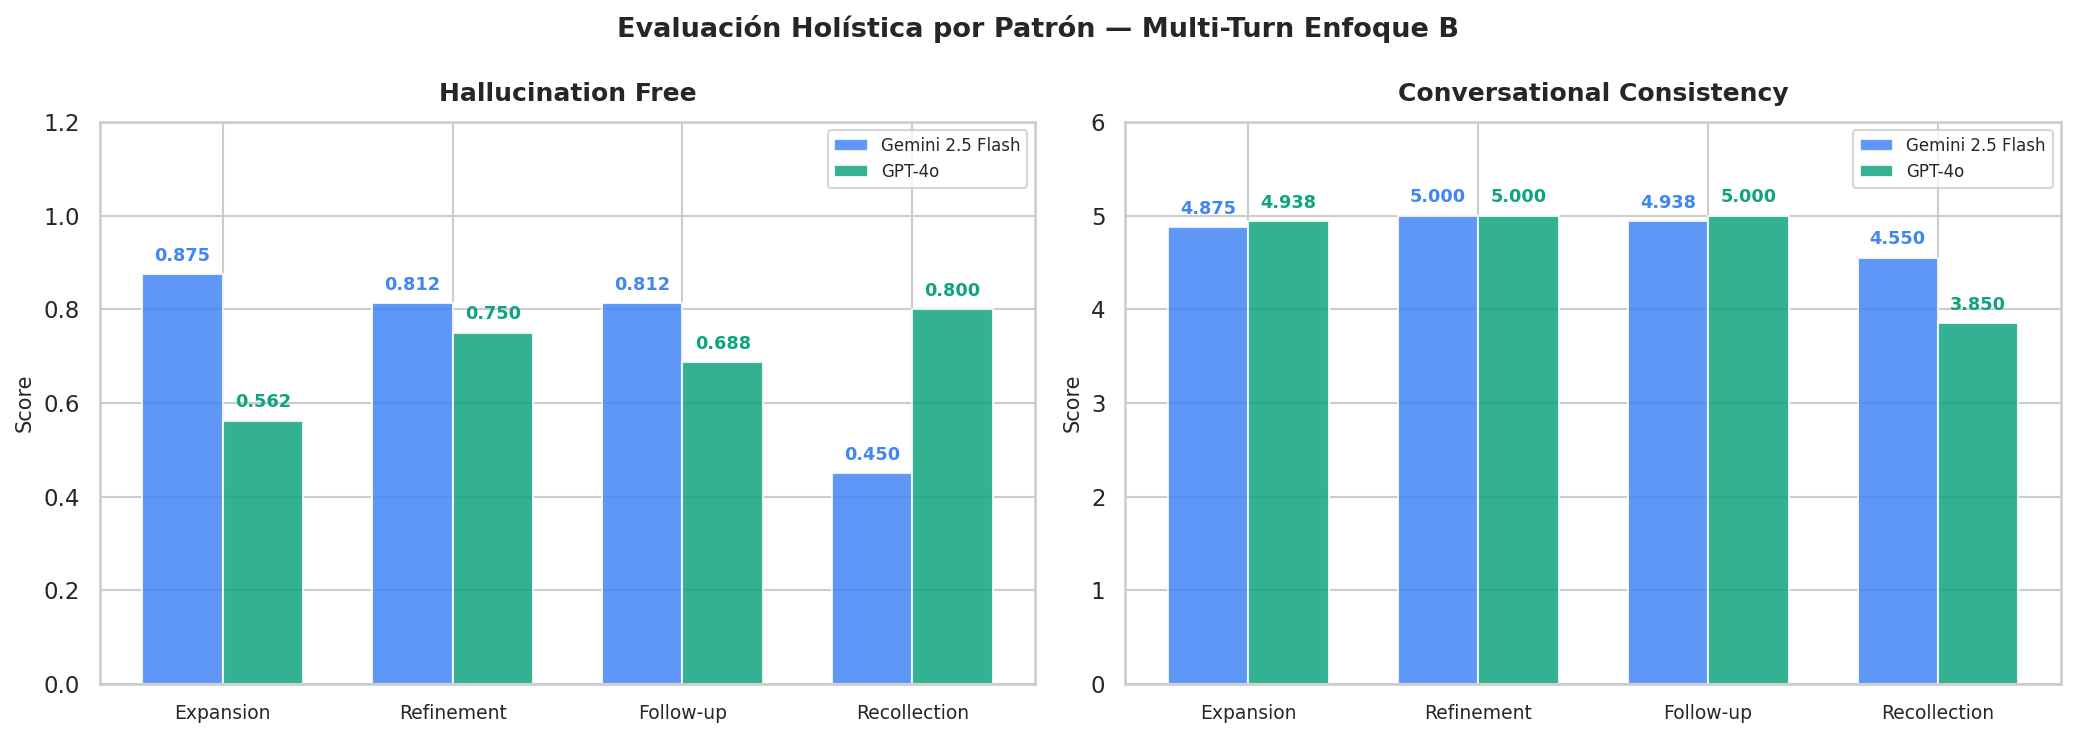

    fig09_holistica_por_patron.png


In [ ]:

# ──────────────────────────────────────────────────────────────
# CELDA 3.7 · Fig 09 — Métricas holísticas por patrón (multi-turn B)
# ──────────────────────────────────────────────────────────────
# %%

def plot_holistic_by_pattern(scores_df: pd.DataFrame, output_dir: Path):
    if scores_df.empty:
        return
    available = get_available_metrics(scores_df, HOLISTIC_METRICS)
    if not available or "pattern" not in scores_df.columns:
        print("Figura omitida: métricas holísticas o columna 'pattern' no disponibles.")
        return

    pattern_labels = {
        "expansion":    "Expansion",
        "refinement":   "Refinement",
        "follow-up":    "Follow-up",
        "recollection": "Recollection",
    }
    patterns = [p for p in pattern_labels if p in scores_df["pattern"].unique()]
    if not patterns:
        return

    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1: axes = [axes]

    for ax, metric in zip(axes, available):
        agg   = scores_df.groupby(["model", "pattern"])[metric].mean().reset_index()
        x     = np.arange(len(patterns))
        width = 0.35

        # Offset de anotación proporcional a la escala de cada métrica
        is_binary = "hallucination" in metric
        y_offset  = 0.02 if is_binary else 0.10

        for i, model in enumerate(agg["model"].unique()):
            vals = []
            for p in patterns:
                sub = agg[(agg["model"] == model) & (agg["pattern"] == p)][metric]
                vals.append(sub.values[0] if len(sub) > 0 else 0)

            offset = (i - len(agg["model"].unique()) / 2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width,
                          color=MODEL_COLORS.get(model, "#888"),
                          label=MODEL_LABELS.get(model, model), alpha=0.85)

            for bar, val in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + y_offset,
                    f"{val:.3f}",
                    ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold",
                    color=MODEL_COLORS.get(model, "#888"),
                )

        ax.set_xticks(x)
        ax.set_xticklabels([pattern_labels.get(p, p) for p in patterns], fontsize=9)
        ylim = 1.2 if is_binary else 6.0   # margen para etiquetas
        ax.set_ylim(0, ylim)
        ax.set_title(metric.replace("_", " ").title(),
                     fontsize=12, fontweight="bold", pad=10)
        ax.set_ylabel("Score")
        ax.legend(fontsize=8)

    fig.suptitle("Evaluación Holística por Patrón — Multi-Turn Enfoque B",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(w_pad=3.0)
    save_fig(output_dir / "fig09_holistica_por_patron.png")


plot_holistic_by_pattern(df_mt_b_scores, PATH_EVAL)


Fig 11 — Boxplot Factual Correctness: Single-Turn vs Multi-Turn Enfoque A
Qué muestra: Un gráfico de cajas (boxplot) con 4 cajas en total, organizadas en pares por modelo:

Caja	Contenido
GPT-4o ST (sólido)	Distribución completa de factual_correctness de GPT-4o en preguntas aisladas
GPT-4o MT-A (transparente)	Distribución completa de factual_correctness de GPT-4o turno a turno con historial
Gemini ST (sólido)	Igual para Gemini en single-turn
Gemini MT-A (transparente)	Igual para Gemini en multi-turn
Cada caja muestra la mediana (línea negra central), el rango intercuartílico IQR (altura de la caja, percentiles 25–75), los bigotes (valores no atípicos) y los outliers individuales como puntos. Hay una línea roja discontinua en y=0.5 como umbral de alucinación.

Qué se pretende ver: Es la figura que más información estadística concentra de todo el notebook. A diferencia de Fig 03 (que solo mostraba medias globales), el boxplot revela la distribución completa de los scores, lo que permite ver:

Mediana vs media: si la caja de MT-A está desplazada hacia abajo respecto a ST, confirma la degradación conversacional con robustez estadística, no solo como promedio
Anchura del IQR: una caja más ancha en MT-A indica mayor variabilidad → el historial hace el comportamiento del modelo más impredecible
Outliers: puntos muy bajos (cerca de 0) son las respuestas donde el modelo alucinó completamente; si hay más en MT-A que en ST, el historial no solo degrada la media sino que genera fallos totales
Asimetría: si la caja está sesgada hacia abajo (mediana cerca del percentil 25), la mayoría de respuestas son malas con pocas excepciones buenas
Por qué es la figura de cierre del análisis: Integra ST y MT-A, los dos modelos y la distribución real de los datos en una sola imagen. Es la evidencia estadísticamente más sólida para el argumento central del TFG: no solo la media cae al introducir historial conversacional, sino que toda la distribución se desplaza y ensancha hacia valores bajos de corrección factual.

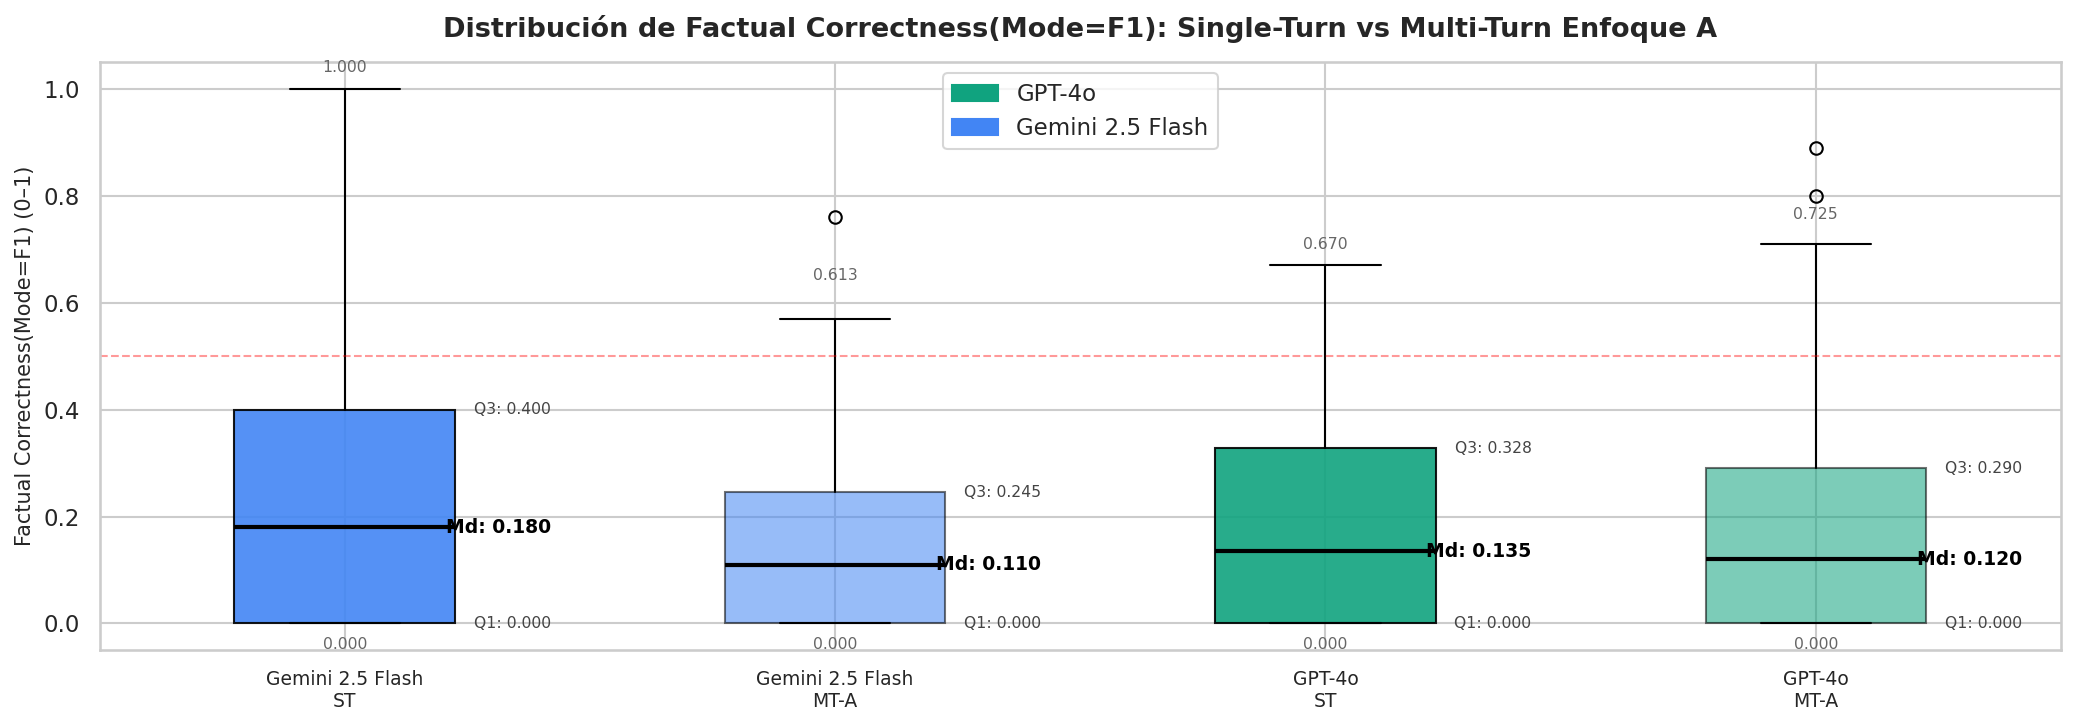

    fig11_boxplot_st_vs_mt_factual_correctness(mode=f1).png


In [ ]:
def plot_boxplot_st_vs_mt(df_st: pd.DataFrame, df_mt: pd.DataFrame,
                           metric: str, output_dir: Path):
    if metric not in df_st.columns or metric not in df_mt.columns:
        print(f"Figura omitida: columna '{metric}' no disponible.")
        return

    data, labels, colors = [], [], []
    for model in df_st["model"].unique():
        for tag, df_src in [("ST", df_st), ("MT-A", df_mt)]:
            sub = df_src[df_src["model"] == model][metric].dropna()
            if not sub.empty:
                data.append(sub.values)
                labels.append(f"{MODEL_LABELS.get(model, model)}\n{tag}")
                colors.append(MODEL_COLORS.get(model, "#888"))

    fig, ax = plt.subplots(figsize=(14, 5))
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={"color": "black", "linewidth": 2})

    for patch, color, label in zip(bp["boxes"], colors, labels):
        patch.set_facecolor(color)
        patch.set_alpha(0.9 if "ST" in label else 0.55)

    for i, arr in enumerate(data):
        q1  = np.percentile(arr, 25)
        med = np.percentile(arr, 50)
        q3  = np.percentile(arr, 75)
        iqr = q3 - q1
        wlo = max(arr.min(), q1 - 1.5 * iqr)
        whi = min(arr.max(), q3 + 1.5 * iqr)

        x_c   = i + 1
        x_off = x_c + 0.42   # siempre a la izquierda de la caja

        # Bigotes: centrados encima/debajo del cap
        ax.text(x_c, whi + 0.025, f"{whi:.3f}",
                ha="center", va="bottom", fontsize=7.5, color="#666")
        ax.text(x_c, wlo - 0.025, f"{wlo:.3f}",
                ha="center", va="top", fontsize=7.5, color="#666")

        # Q3, mediana, Q1: siempre a la izquierda de la caja
        ax.text(x_off, q3,  f"Q3: {q3:.3f}",
                ha="right", va="center", fontsize=7.5, color="#444")
        ax.text(x_off, med, f"Md: {med:.3f}",
                ha="right", va="center", fontsize=9, fontweight="bold", color="black")
        ax.text(x_off, q1,  f"Q1: {q1:.3f}",
                ha="right", va="center", fontsize=7.5, color="#444")

    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(f"{metric.replace('_', ' ').title()} (0–1)")
    ax.set_title(f"Distribución de {metric.replace('_', ' ').title()}: "
                 f"Single-Turn vs Multi-Turn Enfoque A",
                 fontsize=13, fontweight="bold", pad=12)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, linewidth=1)
    handles = [mpatches.Patch(color=c, label=MODEL_LABELS.get(m, m))
               for m, c in MODEL_COLORS.items()
               if m in df_st["model"].unique()]
    ax.legend(handles=handles)
    fig.tight_layout()
    save_fig(output_dir / f"fig11_boxplot_st_vs_mt_{metric}.png")


plot_boxplot_st_vs_mt(df_st_scores, df_mt_a_scores,
                      "factual_correctness(mode=f1)", PATH_EVAL)


## INTEGRACIÓN CON OPIK

In [ ]:

import opik
from opik import Opik
from opik.evaluation.models import ExperimentItem

opik.configure(api_key=OPIK_API_KEY, use_local=False)
opik_client  = Opik()
PROJECT_NAME = "TFG-Baseline-Alucinaciones"


def log_to_opik(scores_df: pd.DataFrame, raw_df: pd.DataFrame,
                prefix: str, metric_cols: list) -> None:
    """
    Registra resultados en Opik como experimentos comparables.
    Cada combinación (modelo, config) se registra como un experimento
    independiente para facilitar la comparación en el dashboard.

    NOTA: si la versión de Opik instalada no tiene ExperimentItem,
    consultar la documentación de la versión exacta.
    """
    if scores_df.empty:
        print(f"     {prefix}: vacío, nada que registrar")
        return

    for (model, config_id), group in scores_df.groupby(["model", "config_id"]):
        exp_name = f"{prefix}__{MODEL_LABELS.get(model, model)}__{config_id}"
        print(f"    {exp_name} ({len(group)} muestras)...")

        experiment = opik_client.create_experiment(
            name=exp_name, project_name=PROJECT_NAME
        )

        # Si scores_df no tiene user_input (raro, RAGAS lo incluye normalmente),
        # hacemos merge por el identificador correcto según el tipo de evaluación
        if "user_input" not in group.columns:
            id_col = "question_id" if "question_id" in group.columns else "conversation_id"
            merge_cols = [id_col, "model", "config_id", "user_input", "response", "reference"]
            merge_cols = [c for c in merge_cols if c in raw_df.columns]
            group = group.merge(
                raw_df[merge_cols].drop_duplicates(subset=[id_col, "model", "config_id"]),
                on=["model", "config_id", id_col],
                how="left",
            )

        items = []
        for _, row in group.iterrows():
            metric_scores = {
                m: float(row[m])
                for m in metric_cols
                if m in row and pd.notna(row.get(m))
            }
            items.append(ExperimentItem(
                input    = {"question": row.get("user_input", "")},
                output   = {"response": row.get("response", "")},
                expected = {"reference": row.get("reference", "")},
                scores   = metric_scores,
                metadata = {
                    "model":     model,
                    "config_id": config_id,
                    "eval_type": row.get("eval_type", ""),
                    "category":  row.get("category", ""),
                    "pattern":   row.get("pattern", ""),
                },
            ))
        experiment.insert(items)


print(" [BLOQUE 4] Registrando experimentos en Opik...")

log_to_opik(df_st_scores, df_st, "ST", GENERATION_METRICS)

# AnswerRelevancy excluida del registro MT-A por la misma razón que de las gráficas
mt_a_opik_metrics = [m for m in GENERATION_METRICS if m != "answer_relevancy"]
log_to_opik(df_mt_a_scores, df_mt, "MT-A", mt_a_opik_metrics)

log_to_opik(df_mt_b_scores, df_mt, "MT-B", HOLISTIC_METRICS)

print(f" [BLOQUE 4] Registros en Opik completados — proyecto: {PROJECT_NAME}\n")

## Exportar a Excel

In [ ]:

# ██████████████████████████████████████████████████████████████████████████████
# BLOQUE 5 · EXPORTACIÓN EXCEL
# ██████████████████████████████████████████████████████████████████████████████

# ──────────────────────────────────────────────────────────────
# CELDA 5.1 · Excel con todas las hojas
# ──────────────────────────────────────────────────────────────
# %%

excel_path = PATH_EVAL / "baseline_resultados_completos.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    df_all.to_excel(writer, sheet_name="Respuestas_Raw", index=False)

    if not df_st_scores.empty:
        df_st_scores.to_excel(writer, sheet_name="ST_Detalle", index=False)
        st_agg = (df_st_scores
                  .groupby(["model", "config_id", "category"])
                  [get_available_metrics(df_st_scores, GENERATION_METRICS)]
                  .mean().reset_index())
        st_agg.to_excel(writer, sheet_name="ST_Por_Categoria", index=False)

    if not df_mt_a_scores.empty:
        df_mt_a_scores.to_excel(writer, sheet_name="MT_A_Detalle", index=False)
        mt_a_m = get_available_metrics(df_mt_a_scores,
                     [m for m in GENERATION_METRICS if m != "answer_relevancy"])
        mt_a_agg = (df_mt_a_scores
                    .groupby(["model", "config_id", "pattern"])[mt_a_m]
                    .mean().reset_index())
        mt_a_agg.to_excel(writer, sheet_name="MT_A_Por_Patron", index=False)

    if not df_mt_b_scores.empty:
        df_mt_b_scores.to_excel(writer, sheet_name="MT_B_Holistico", index=False)
        mt_b_agg = (df_mt_b_scores
                    .groupby(["model", "config_id", "pattern"])
                    [get_available_metrics(df_mt_b_scores, HOLISTIC_METRICS)]
                    .mean().reset_index())
        mt_b_agg.to_excel(writer, sheet_name="MT_B_Por_Patron", index=False)

    # Resumen ejecutivo cross-bloque
    exec_rows = []
    for (model, config), g in df_all.groupby(["model", "config_id"]):
        row = {
            "Modelo":            MODEL_LABELS.get(model, model),
            "Configuración":     config,
            "N total":           len(g),
            "N single-turn":     (g["type"] == "single_turn").sum(),
            "N multi-turn":      (g["type"] == "multi_turn").sum(),
            "Latencia media (s)":round(g["latency_s"].mean(), 3),
        }
        for df_src, prefix in [(df_st_scores, "ST"),
                                (df_mt_a_scores, "MT-A")]:
            if not df_src.empty:
                sub = df_src[(df_src["model"] == model) &
                             (df_src["config_id"] == config)]
                for m in ["factual_correctness", "semantic_similarity"]:
                    if m in sub.columns:
                        row[f"{prefix}_{m}"] = round(sub[m].mean(), 4)
        exec_rows.append(row)

    pd.DataFrame(exec_rows).to_excel(writer,
        sheet_name="Resumen_Ejecutivo", index=False)

print(f" [BLOQUE 5] Excel guardado: {excel_path}")
print(f"\n Pipeline de evaluación completo.")
print(f"   Resultados en: {PATH_EVAL}/")
